# Monster–VIKING Z-band colour transformation

This notebook derives an empirical transformation from Monster DES-system
photometry to the VIRCAM Z band using VIKING DR4 stellar catalogues.
Proper-motion-aware catalogue matching is used to construct a clean calibration
sample, fit and validate the colour spline, and produce the final Monster YAML
transformation.

## 1. Configuration and catalogue audit

In [1]:
from pathlib import Path
from astropy.io import fits
from astropy.table import Table
import glob
import numpy as np
import warnings

from astropy.units import UnitsWarning

# Hide warnings caused by non-standard unit strings in VISTA FITS metadata,
# such as "ADU" and "day".
warnings.filterwarnings(
    "ignore",
    category=UnitsWarning,
)

# ------------------------------------------------------------------
# Update these paths only if necessary
# ------------------------------------------------------------------
viking_files = sorted(
    glob.glob("data/VIKING/z_band/viking/*.fits")
)

monster_files = sorted(
    glob.glob("data/VIKING/z_band/monster/*/*.fits")
)

if not viking_files:
    raise FileNotFoundError("No VIKING Z catalogues were found.")

if not monster_files:
    raise FileNotFoundError("No Monster shard files were found.")

viking_path = viking_files[0]
monster_path = monster_files[0]

print("VIKING example:", viking_path)
print("Monster example:", monster_path)


# ------------------------------------------------------------------
# Inspect VIKING FITS structure and headers
# ------------------------------------------------------------------
epoch_keys = [
    "DATE-OBS", "MJD-OBS", "MJDOBS", "MJDSTART", "MJDEND",
    "MJD-MIN", "MJD-MAX", "EPOCH", "EQUINOX",
    "TIMESYS", "RADESYS"
]

photometry_keys = [
    "MAGZPT", "MAGZERO", "PHOTZP", "PHOTSYS",
    "MAGSYS", "VEGAMAG", "ABMAG", "FLUXUNIT",
    "BUNIT", "FILTER"
]

with fits.open(viking_path, memmap=True) as hdul:
    print("\nVIKING HDUs")
    print("-----------")

    for index, hdu in enumerate(hdul):
        nrows = (
            len(hdu.data)
            if getattr(hdu, "data", None) is not None
            and hasattr(hdu.data, "__len__")
            else None
        )

        print(
            index,
            hdu.name,
            type(hdu).__name__,
            "rows =", nrows
        )

    table_index = next(
        index
        for index, hdu in enumerate(hdul)
        if getattr(hdu, "data", None) is not None
        and hasattr(hdu.data, "columns")
    )

    print("\nRelevant VIKING header keywords")
    print("--------------------------------")

    # Check both primary and table headers.
    for key in epoch_keys + photometry_keys:
        values = []

        for hdu_index in [0, table_index]:
            if key in hdul[hdu_index].header:
                values.append(
                    (hdu_index, hdul[hdu_index].header[key])
                )

        if values:
            print(f"{key:12s}: {values}")

    columns = hdul[table_index].columns

    print("\nPotentially relevant VIKING columns")
    print("------------------------------------")

    tokens = [
        "RA", "DEC", "MJD", "DATE", "EPOCH",
        "MAG", "FLUX", "ERR", "CLASS", "PSTAR",
        "PRIMARY", "ELL", "FLAG", "BITS"
    ]

    for column in columns:
        upper_name = column.name.upper()

        if any(token in upper_name for token in tokens):
            print(
                f"{column.name:30s} "
                f"format={str(column.format):10s} "
                f"unit={str(column.unit)}"
            )


# ------------------------------------------------------------------
# Inspect important VIKING values
# ------------------------------------------------------------------
viking = Table.read(viking_path)

candidate_columns = [
    "RA", "DEC", "RA2000", "DEC2000",
    "APERFLUX3", "APERFLUX3ERR",
    "APERMAG3", "APERMAG3ERR",
    "APERMAGNOAPERCORR3",
    "PRIMARY_SOURCE", "MERGEDCLASS",
    "PSTAR", "PPERRBITS"
]

print("\nExample VIKING values")
print("---------------------")

for name in candidate_columns:
    if name in viking.colnames:
        column = viking[name]
        print(
            f"\n{name}: "
            f"dtype={column.dtype}, "
            f"unit={getattr(column, 'unit', None)}"
        )
        print(np.asarray(column[:5]))


# ------------------------------------------------------------------
# Inspect Monster astrometric schema
# ------------------------------------------------------------------
monster = Table.read(monster_path)

monster_columns = [
    "id",
    "coord_ra", "coord_dec",
    "coord_raErr", "coord_decErr",
    "epoch",
    "pm_ra", "pm_dec",
    "pm_raErr", "pm_decErr",
    "parallax", "parallaxErr",
    "monster_DES_i_flux",
    "monster_DES_i_fluxErr",
    "monster_DES_z_flux",
    "monster_DES_z_fluxErr"
]

print("\nMonster columns")
print("---------------")

for name in monster_columns:
    if name in monster.colnames:
        column = monster[name]
        print(
            f"{name:28s} "
            f"dtype={column.dtype} "
            f"unit={getattr(column, 'unit', None)}"
        )

        values = np.asarray(column[:5])
        print("   first values:", values)

print("\nMonster row count:", len(monster))
print("VIKING row count:", len(viking))

VIKING example: data/VIKING/z_band/viking/ADP.2020-03-02T18:38:28.220.fits
Monster example: data/VIKING/z_band/monster/ADP.2020-03-02T18:38:28.220/monster_htm7_132224.fits

VIKING HDUs
-----------
0 PRIMARY PrimaryHDU rows = None
1 detection table BinTableHDU rows = 51479

Relevant VIKING header keywords
--------------------------------
MJD-OBS     : [(0, 57550.32613465)]
EQUINOX     : [(0, 2000.0)]
MAGZPT      : [(1, 23.63100051879883)]
PHOTSYS     : [(1, 'VEGA')]
FILTER      : [(0, 'Z')]

Potentially relevant VIKING columns
------------------------------------
MULTIFRAMEID                   format=K          unit=None
ISOFLUX                        format=E          unit=ADU
ISOMAG                         format=E          unit=mag
XERR                           format=E          unit=pix
YERR                           format=E          unit=pix
ELL                            format=E          unit=None
PHEIGHTERR                     format=E          unit=ADU
APERFLUX1              

## 2. Full VIKING Z-band tile and epoch inventory

Before performing any catalogue matching, I characterise every available
VIKING Z-band catalogue. The purpose of this inventory is to:

- confirm that all input catalogues belong to the Z band and use the same
  photometric system;
- record the number and sky coverage of the available VIKING tiles;
- inspect both the catalogue-level `MJD-OBS` and the per-source `MJD` values;
- determine whether one observing epoch can be assigned to each tile or
  whether sources must be divided into separate epoch groups;
- estimate the number of sources with valid aperture photometry and useful
  signal-to-noise ratios;
- verify that the corresponding Monster HTM7 shards are available for every
  VIKING tile.

The tile centres are calculated using three-dimensional unit vectors rather
than ordinary averages of right ascension. This correctly handles tiles that
cross in right ascension. At this stage, no astrometric or
photometric selection is applied: the aim is only to document the complete
input dataset.

In [2]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u

from IPython.display import display


# -------------------------------------------------------------------
# Input and output configuration
# -------------------------------------------------------------------

VIKING_DIR = Path("data/VIKING/z_band/viking")
MONSTER_ROOT = Path("data/VIKING/z_band/monster")

OUTPUT_DIR = Path("data/outputs/Monster_VIKING_Z")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INVENTORY_PATH = OUTPUT_DIR / "viking_z_tile_inventory.csv"

viking_files = sorted(VIKING_DIR.glob("*.fits"))

if not viking_files:
    raise FileNotFoundError(
        f"No VIKING FITS catalogues were found in {VIKING_DIR}"
    )

print(f"Found {len(viking_files)} VIKING catalogue files.")


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def find_table_hdu(hdul):
    """Return the index of the first binary-table HDU."""
    for index, hdu in enumerate(hdul):
        if (
            getattr(hdu, "data", None) is not None
            and hasattr(hdu.data, "columns")
        ):
            return index

    raise ValueError("No binary-table HDU was found.")


def header_value(primary_header, table_header, key, default=np.nan):
    """
    Read a keyword from the table header first and then from the
    primary header.
    """
    if key in table_header:
        return table_header[key]

    if key in primary_header:
        return primary_header[key]

    return default


def spherical_centre_and_radius(ra_deg, dec_deg):
    """
    Calculate the spherical centre of a catalogue and the maximum
    angular distance of its sources from that centre.

    This method is safe for catalogues crossing RA = 0 degrees.
    """
    ra_deg = np.asarray(ra_deg, dtype=float)
    dec_deg = np.asarray(dec_deg, dtype=float)

    good = (
        np.isfinite(ra_deg)
        & np.isfinite(dec_deg)
        & (dec_deg >= -90.0)
        & (dec_deg <= 90.0)
    )

    if not np.any(good):
        return np.nan, np.nan, np.nan

    coordinates = SkyCoord(
        ra=ra_deg[good] * u.deg,
        dec=dec_deg[good] * u.deg,
        frame="icrs",
    )

    xyz = coordinates.cartesian.xyz.value
    mean_vector = np.mean(xyz, axis=1)

    vector_norm = np.linalg.norm(mean_vector)

    if not np.isfinite(vector_norm) or vector_norm == 0:
        return np.nan, np.nan, np.nan

    mean_vector /= vector_norm

    centre_ra_rad = np.arctan2(mean_vector[1], mean_vector[0])
    centre_ra_rad %= 2.0 * np.pi

    centre_dec_rad = np.arcsin(
        np.clip(mean_vector[2], -1.0, 1.0)
    )

    centre = SkyCoord(
        ra=centre_ra_rad * u.rad,
        dec=centre_dec_rad * u.rad,
        frame="icrs",
    )

    radius_deg = np.max(centre.separation(coordinates).degree)

    return (
        float(centre.ra.degree),
        float(centre.dec.degree),
        float(radius_deg),
    )


def finite_summary(values):
    """Return basic summary statistics for finite numerical values."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return {
            "minimum": np.nan,
            "median": np.nan,
            "maximum": np.nan,
            "p16": np.nan,
            "p84": np.nan,
        }

    return {
        "minimum": float(np.min(values)),
        "median": float(np.median(values)),
        "maximum": float(np.max(values)),
        "p16": float(np.percentile(values, 16)),
        "p84": float(np.percentile(values, 84)),
    }


def class_count_string(class_values):
    """
    Store the raw VIKING CLASS distribution without yet assigning
    a physical interpretation to individual class codes.
    """
    class_values = np.asarray(class_values)
    class_values = class_values[np.isfinite(class_values)]

    if len(class_values) == 0:
        return ""

    counts = Counter(class_values.astype(int))

    return "; ".join(
        f"{class_id}:{counts[class_id]}"
        for class_id in sorted(counts)
    )


def summarize_viking_file(viking_path):
    """Build one inventory record for a VIKING catalogue."""
    with fits.open(viking_path, memmap=True) as hdul:
        table_index = find_table_hdu(hdul)

        primary_header = hdul[0].header
        table_header = hdul[table_index].header
        data = hdul[table_index].data

        column_names = set(data.names)
        n_rows = len(data)

        required_columns = {
            "RA",
            "DEC",
            "MJD",
            "APERFLUX3",
            "APERFLUX3ERR",
            "APERMAG3",
            "APERMAG3ERR",
        }

        missing_columns = sorted(required_columns - column_names)

        if missing_columns:
            raise KeyError(
                f"{viking_path.name} is missing required columns: "
                f"{missing_columns}"
            )

        # -----------------------------------------------------------
        # Coordinates and footprint
        # -----------------------------------------------------------
        ra = np.asarray(data["RA"], dtype=float)
        dec = np.asarray(data["DEC"], dtype=float)

        centre_ra, centre_dec, radius_deg = (
            spherical_centre_and_radius(ra, dec)
        )

        n_valid_coordinates = int(
            np.count_nonzero(
                np.isfinite(ra)
                & np.isfinite(dec)
                & (dec >= -90.0)
                & (dec <= 90.0)
            )
        )

        # -----------------------------------------------------------
        # Source-level observing epochs
        # -----------------------------------------------------------
        source_mjd = np.asarray(data["MJD"], dtype=float)
        finite_mjd = source_mjd[np.isfinite(source_mjd)]

        mjd_stats = finite_summary(finite_mjd)

        if len(finite_mjd) > 0:
            mjd_span_days = (
                mjd_stats["maximum"] - mjd_stats["minimum"]
            )

            median_epoch_jyear = float(
                Time(
                    mjd_stats["median"],
                    format="mjd",
                    scale="utc",
                ).jyear
            )

            # Count distinguishable epochs after rounding to the
            # nearest second. This avoids counting insignificant
            # floating-point differences as separate observations.
            mjd_in_seconds = np.rint(
                finite_mjd * 86400.0
            ).astype(np.int64)

            n_unique_epoch_seconds = int(
                np.unique(mjd_in_seconds).size
            )
        else:
            mjd_span_days = np.nan
            median_epoch_jyear = np.nan
            n_unique_epoch_seconds = 0

        header_mjd_obs = header_value(
            primary_header,
            table_header,
            "MJD-OBS",
        )

        try:
            header_mjd_obs = float(header_mjd_obs)
        except (TypeError, ValueError):
            header_mjd_obs = np.nan

        if (
            np.isfinite(header_mjd_obs)
            and np.isfinite(mjd_stats["median"])
        ):
            header_minus_source_median_days = (
                header_mjd_obs - mjd_stats["median"]
            )
        else:
            header_minus_source_median_days = np.nan

        # -----------------------------------------------------------
        # Aperture-3 photometry
        # -----------------------------------------------------------
        aperture_flux = np.asarray(
            data["APERFLUX3"],
            dtype=float,
        )

        aperture_flux_error = np.asarray(
            data["APERFLUX3ERR"],
            dtype=float,
        )

        aperture_mag = np.asarray(
            data["APERMAG3"],
            dtype=float,
        )

        aperture_mag_error = np.asarray(
            data["APERMAG3ERR"],
            dtype=float,
        )

        valid_flux = (
            np.isfinite(aperture_flux)
            & np.isfinite(aperture_flux_error)
            & (aperture_flux > 0.0)
            & (aperture_flux_error > 0.0)
        )

        signal_to_noise = np.full(n_rows, np.nan, dtype=float)
        signal_to_noise[valid_flux] = (
            aperture_flux[valid_flux]
            / aperture_flux_error[valid_flux]
        )

        valid_magnitude = (
            np.isfinite(aperture_mag)
            & np.isfinite(aperture_mag_error)
            & (aperture_mag_error > 0.0)
        )

        # -----------------------------------------------------------
        # Catalogue classification and quality metadata
        # -----------------------------------------------------------
        if "CLASS" in column_names:
            class_values = np.asarray(data["CLASS"], dtype=float)
            raw_class_counts = class_count_string(class_values)
        else:
            class_values = np.array([], dtype=float)
            raw_class_counts = ""

        if "PPERRBITS" in column_names:
            pperrbits = np.asarray(data["PPERRBITS"])
            finite_pperrbits = np.isfinite(pperrbits)

            if np.any(finite_pperrbits):
                fraction_pperrbits_zero = float(
                    np.mean(pperrbits[finite_pperrbits] == 0)
                )
            else:
                fraction_pperrbits_zero = np.nan
        else:
            fraction_pperrbits_zero = np.nan

        if "MULTIFRAMEID" in column_names:
            multiframe_id = np.asarray(data["MULTIFRAMEID"])
            n_multiframe_ids = int(np.unique(multiframe_id).size)
        else:
            n_multiframe_ids = 0

        # -----------------------------------------------------------
        # Corresponding Monster shard directory
        # -----------------------------------------------------------
        monster_directory = MONSTER_ROOT / viking_path.stem

        if monster_directory.exists():
            monster_shards = sorted(
                monster_directory.glob("*.fits")
            )
        else:
            monster_shards = []

        # -----------------------------------------------------------
        # Complete inventory record
        # -----------------------------------------------------------
        return {
            "viking_file": viking_path.name,
            "viking_path": str(viking_path),
            "n_rows": n_rows,
            "n_valid_coordinates": n_valid_coordinates,

            "filter": str(
                header_value(
                    primary_header,
                    table_header,
                    "FILTER",
                    default="",
                )
            ).strip(),

            "photsys": str(
                header_value(
                    primary_header,
                    table_header,
                    "PHOTSYS",
                    default="",
                )
            ).strip(),

            "magzpt": header_value(
                primary_header,
                table_header,
                "MAGZPT",
            ),

            "equinox": header_value(
                primary_header,
                table_header,
                "EQUINOX",
            ),

            "centre_ra_deg": centre_ra,
            "centre_dec_deg": centre_dec,
            "coverage_radius_deg": radius_deg,

            "header_mjd_obs": header_mjd_obs,
            "source_mjd_min": mjd_stats["minimum"],
            "source_mjd_median": mjd_stats["median"],
            "source_mjd_max": mjd_stats["maximum"],
            "source_mjd_p16": mjd_stats["p16"],
            "source_mjd_p84": mjd_stats["p84"],
            "source_mjd_span_days": mjd_span_days,
            "median_epoch_jyear": median_epoch_jyear,
            "n_valid_source_mjd": len(finite_mjd),
            "n_unique_epoch_seconds": n_unique_epoch_seconds,
            "header_minus_source_median_days":
                header_minus_source_median_days,

            "n_valid_aperflux3": int(
                np.count_nonzero(valid_flux)
            ),
            "n_valid_apermag3": int(
                np.count_nonzero(valid_magnitude)
            ),
            "n_snr_ge_20": int(
                np.count_nonzero(signal_to_noise >= 20.0)
            ),
            "n_snr_ge_30": int(
                np.count_nonzero(signal_to_noise >= 30.0)
            ),
            "n_snr_ge_50": int(
                np.count_nonzero(signal_to_noise >= 50.0)
            ),

            "class_counts": raw_class_counts,
            "fraction_pperrbits_zero":
                fraction_pperrbits_zero,
            "n_multiframe_ids": n_multiframe_ids,

            "monster_directory": str(monster_directory),
            "monster_directory_exists":
                monster_directory.exists(),
            "n_monster_shards": len(monster_shards),
        }


# -------------------------------------------------------------------
# Process all VIKING Z-band catalogues
# -------------------------------------------------------------------

inventory_records = []

for file_number, viking_path in enumerate(
    viking_files,
    start=1,
):
    print(
        f"[{file_number:03d}/{len(viking_files):03d}] "
        f"{viking_path.name}"
    )

    try:
        record = summarize_viking_file(viking_path)
        record["inventory_status"] = "OK"
        record["inventory_error"] = ""

    except Exception as error:
        record = {
            "viking_file": viking_path.name,
            "viking_path": str(viking_path),
            "inventory_status": "FAILED",
            "inventory_error": repr(error),
        }

        print(f"    ERROR: {error}")

    inventory_records.append(record)


inventory = pd.DataFrame(inventory_records)

inventory.to_csv(
    INVENTORY_PATH,
    index=False,
)

print(f"\nInventory written to:\n{INVENTORY_PATH}")

Found 88 VIKING catalogue files.
[001/088] ADP.2020-03-02T18:38:28.220.fits
[002/088] ADP.2020-03-02T18:38:28.307.fits
[003/088] ADP.2020-03-02T18:38:28.351.fits
[004/088] ADP.2020-03-02T18:38:28.614.fits
[005/088] ADP.2020-03-02T18:38:28.835.fits
[006/088] ADP.2020-03-02T18:38:28.996.fits
[007/088] ADP.2020-03-02T18:38:29.134.fits
[008/088] ADP.2020-03-02T18:38:29.174.fits
[009/088] ADP.2020-03-02T18:38:29.311.fits
[010/088] ADP.2020-03-02T18:38:29.451.fits
[011/088] ADP.2020-03-02T18:38:29.523.fits
[012/088] ADP.2020-03-02T18:38:29.747.fits
[013/088] ADP.2020-03-02T18:38:29.947.fits
[014/088] ADP.2020-03-02T18:38:30.001.fits
[015/088] ADP.2020-03-02T18:38:30.121.fits
[016/088] ADP.2020-03-02T18:38:30.207.fits
[017/088] ADP.2020-03-02T18:38:30.232.fits
[018/088] ADP.2020-03-02T18:38:30.233.fits
[019/088] ADP.2020-03-02T18:38:30.263.fits
[020/088] ADP.2020-03-02T18:38:30.395.fits
[021/088] ADP.2020-03-02T18:38:30.425.fits
[022/088] ADP.2020-03-02T18:38:30.513.fits
[023/088] ADP.2020-03

### 2.1 Inventory summary and consistency checks

This cell summarises the complete VIKING Z-band input sample and identifies
catalogues that require special handling.

In particular, I inspect the span of the per-source `MJD` values in each
catalogue. If the span is negligible, the median source MJD can be used as the
effective epoch for that tile. If a catalogue contains sources from
substantially different epochs, it must instead be divided into epoch groups
before matching to Monster.

The reported source counts are raw catalogue detections. They must not yet be
interpreted as the number of unique calibration stars because neighbouring
VIKING tiles may overlap.

In [3]:
successful = inventory[
    inventory["inventory_status"] == "OK"
].copy()

failed = inventory[
    inventory["inventory_status"] != "OK"
].copy()


print("=" * 72)
print("VIKING Z-BAND INVENTORY SUMMARY")
print("=" * 72)

print(f"Input catalogue files       : {len(inventory)}")
print(f"Successfully inspected      : {len(successful)}")
print(f"Failed files                : {len(failed)}")

if len(successful) > 0:
    print(
        f"Raw catalogue detections    : "
        f"{int(successful['n_rows'].sum()):,}"
    )

    print(
        f"Sources with S/N >= 20      : "
        f"{int(successful['n_snr_ge_20'].sum()):,}"
    )

    print(
        f"Sources with S/N >= 30      : "
        f"{int(successful['n_snr_ge_30'].sum()):,}"
    )

    print(
        f"Sources with S/N >= 50      : "
        f"{int(successful['n_snr_ge_50'].sum()):,}"
    )

    print(
        f"Total associated Monster "
        f"shard files                 : "
        f"{int(successful['n_monster_shards'].sum()):,}"
    )


print("\nFILTER values")
print("-------------")
if len(successful) > 0:
    print(successful["filter"].value_counts(dropna=False))


print("\nPHOTSYS values")
print("--------------")
if len(successful) > 0:
    print(successful["photsys"].value_counts(dropna=False))


print("\nEpoch range across all catalogues")
print("---------------------------------")
if len(successful) > 0:
    print(
        "Earliest source MJD :",
        successful["source_mjd_min"].min(),
    )

    print(
        "Latest source MJD   :",
        successful["source_mjd_max"].max(),
    )

    print(
        "Earliest median year:",
        successful["median_epoch_jyear"].min(),
    )

    print(
        "Latest median year  :",
        successful["median_epoch_jyear"].max(),
    )


# These thresholds are diagnostic only. I will choose the final
# epoch-handling rule after examining the output.
large_epoch_span = successful[
    successful["source_mjd_span_days"] > 0.1
].sort_values(
    "source_mjd_span_days",
    ascending=False,
)

header_epoch_disagreement = successful[
    successful[
        "header_minus_source_median_days"
    ].abs() > 0.1
].sort_values(
    "header_minus_source_median_days",
    key=lambda values: values.abs(),
    ascending=False,
)

missing_monster = successful[
    successful["n_monster_shards"] == 0
]


print("\nPotential special cases")
print("-----------------------")
print(
    "Files with source-MJD span > 0.1 day :",
    len(large_epoch_span),
)
print(
    "Files where |MJD-OBS - median MJD| "
    "> 0.1 day                          :",
    len(header_epoch_disagreement),
)
print(
    "Files without associated Monster shards:",
    len(missing_monster),
)


summary_columns = [
    "viking_file",
    "n_rows",
    "filter",
    "photsys",
    "header_mjd_obs",
    "source_mjd_median",
    "source_mjd_span_days",
    "n_unique_epoch_seconds",
    "median_epoch_jyear",
    "n_snr_ge_30",
    "n_monster_shards",
]


print("\nTen catalogues with the largest internal MJD spans")
print("--------------------------------------------------")

display(
    successful.sort_values(
        "source_mjd_span_days",
        ascending=False,
    )[summary_columns].head(10)
)


if len(failed) > 0:
    print("\nFailed catalogue files")
    print("----------------------")

    display(
        failed[
            [
                "viking_file",
                "inventory_error",
            ]
        ]
    )

VIKING Z-BAND INVENTORY SUMMARY
Input catalogue files       : 88
Successfully inspected      : 88
Failed files                : 0
Raw catalogue detections    : 7,230,164
Sources with S/N >= 20      : 1,975,489
Sources with S/N >= 30      : 1,378,585
Sources with S/N >= 50      : 882,654
Total associated Monster shard files                 : 2,245

FILTER values
-------------
filter
Z    88
Name: count, dtype: int64

PHOTSYS values
--------------
photsys
VEGA    88
Name: count, dtype: int64

Epoch range across all catalogues
---------------------------------
Earliest source MJD : 57492.06004125277
Latest source MJD   : 58164.04823844698
Earliest median year: 2016.2835695219435
Latest median year  : 2018.123305122774

Potential special cases
-----------------------
Files with source-MJD span > 0.1 day : 0
Files where |MJD-OBS - median MJD| > 0.1 day                          : 0
Files without associated Monster shards: 0

Ten catalogues with the largest internal MJD spans
----------------

,viking_file,n_rows,filter,photsys,header_mjd_obs,source_mjd_median,source_mjd_span_days,n_unique_epoch_seconds,median_epoch_jyear,n_snr_ge_30,n_monster_shards
35,ADP.2020-03-02T18:38:33.210.fits,114330,Z,VEGA,57492.058794,57492.073768,0.020521,1713,2016.283570,13523,40
48,ADP.2020-03-02T18:38:37.113.fits,89468,Z,VEGA,57512.255117,57512.265484,0.019986,1647,2016.338851,17004,30
52,ADP.2020-03-02T18:38:38.391.fits,75605,Z,VEGA,57780.358386,57780.371815,0.019358,1538,2017.072887,15116,30
56,ADP.2020-03-02T18:38:39.084.fits,87577,Z,VEGA,57781.352179,57781.362699,0.019088,1533,2017.075599,19786,27
51,ADP.2020-03-02T18:38:37.969.fits,68168,Z,VEGA,57782.346282,57782.354214,0.018852,1502,2017.078314,13439,27
4,ADP.2020-03-02T18:38:28.835.fits,78421,Z,VEGA,57961.202080,57961.209843,0.018749,1517,2017.567994,12875,34
50,ADP.2020-03-02T18:38:37.757.fits,65935,Z,VEGA,57494.081403,57494.091006,0.018711,1484,2016.289092,14071,26
73,ADP.2020-03-02T18:38:41.247.fits,111433,Z,VEGA,57949.237565,57949.245657,0.018238,1508,2017.535238,16546,26
37,ADP.2020-03-02T18:38:34.057.fits,63280,Z,VEGA,58155.335845,58155.350094,0.018233,1450,2018.099521,9141,36
85,ADP.2020-03-02T18:38:42.826.fits,101641,Z,VEGA,57963.252891,57963.266530,0.018041,1497,2017.573625,12622,39


### 2.2 Distribution of VIKING observing epochs

The following diagnostics show:

1. the distribution of the median observing epoch of the VIKING catalogues;
2. the time span covered by the source-level MJD values within each catalogue.

The first plot describes how VIKING scanned the survey area with time. The
second determines whether a single propagation epoch is adequate for each
catalogue. Tiles with large internal epoch spans will be inspected separately
before the matching algorithm is defined.

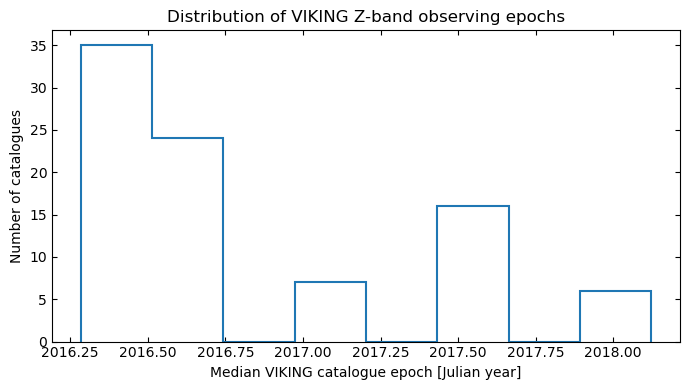

Saved: data/outputs/Monster_VIKING_Z/viking_z_median_epoch_distribution.pdf


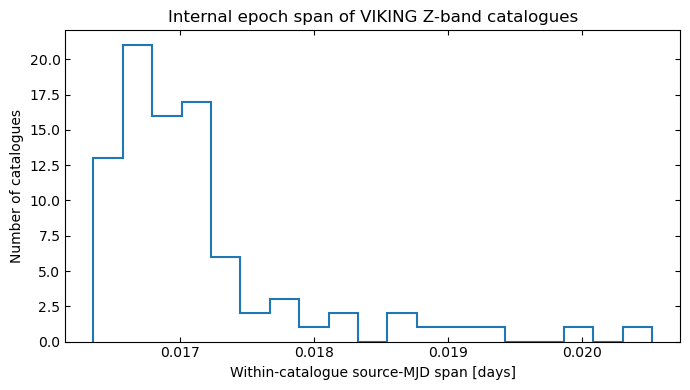

Saved: data/outputs/Monster_VIKING_Z/viking_z_internal_epoch_span.pdf


In [4]:
import matplotlib.pyplot as plt


epoch_years = np.asarray(
    successful["median_epoch_jyear"],
    dtype=float,
)

epoch_years = epoch_years[np.isfinite(epoch_years)]


fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    epoch_years,
    bins="auto",
    histtype="step",
    linewidth=1.5,
)

ax.set_xlabel("Median VIKING catalogue epoch [Julian year]")
ax.set_ylabel("Number of catalogues")
ax.set_title("Distribution of VIKING Z-band observing epochs")

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

fig.tight_layout()

epoch_histogram_path = (
    OUTPUT_DIR / "viking_z_median_epoch_distribution.pdf"
)

fig.savefig(
    epoch_histogram_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {epoch_histogram_path}")


epoch_spans = np.asarray(
    successful["source_mjd_span_days"],
    dtype=float,
)

epoch_spans = epoch_spans[
    np.isfinite(epoch_spans)
    & (epoch_spans >= 0.0)
]


fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    epoch_spans,
    bins="auto",
    histtype="step",
    linewidth=1.5,
)

ax.set_xlabel("Within-catalogue source-MJD span [days]")
ax.set_ylabel("Number of catalogues")
ax.set_title("Internal epoch span of VIKING Z-band catalogues")

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

fig.tight_layout()

epoch_span_path = (
    OUTPUT_DIR / "viking_z_internal_epoch_span.pdf"
)

fig.savefig(
    epoch_span_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {epoch_span_path}")

## 3. Prepare a representative VIKING tile for astrometric matching

The final Z-band colour transformation will use all 88 available VIKING
DR4 catalogues. Before processing the complete dataset, however, I develop
and validate the matching procedure using one representative tile with a
large number of high-S/N sources.

For this tile, we:

1. read the complete native VIKING catalogue;
2. calculate its effective observing epoch from the median source-level
   `MJD`;
3. load all overlapping Monster HTM7 shards;
4. combine the shards into a single table;
5. remove duplicated Monster sources that occur at shard boundaries;
6. verify the availability and units of the astrometric and photometric
   columns needed for matching and colour-term calibration.

The source-level MJD values within each VIKING catalogue span only about
20--30 minutes. This interval is negligible for proper-motion propagation,
even for unusually high-proper-motion stars. I therefore assign one
effective epoch—the median source MJD—to each VIKING tile.

At this stage, no catalogue matching or photometric selection is performed.
The purpose is to construct clean and well-documented input tables for the
next astrometric step.

In [5]:
from pathlib import Path
import warnings

import numpy as np

from astropy.table import Table, vstack
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning


# -------------------------------------------------------------------
# Development-tile configuration
# -------------------------------------------------------------------

VIKING_DIR = Path("data/VIKING/z_band/viking")
MONSTER_ROOT = Path("data/VIKING/z_band/monster")

# This tile contains a large number of high-S/N VIKING detections and
# a manageable number of overlapping Monster shards.
DEVELOPMENT_TILE_NAME = "ADP.2020-03-02T18:38:39.084.fits"

viking_path = VIKING_DIR / DEVELOPMENT_TILE_NAME
monster_directory = MONSTER_ROOT / viking_path.stem

if not viking_path.exists():
    raise FileNotFoundError(
        f"VIKING development tile was not found:\n{viking_path}"
    )

if not monster_directory.exists():
    raise FileNotFoundError(
        "The corresponding Monster directory was not found:\n"
        f"{monster_directory}"
    )

monster_shard_paths = sorted(monster_directory.glob("*.fits"))

if not monster_shard_paths:
    raise FileNotFoundError(
        f"No Monster shard files were found in:\n{monster_directory}"
    )


# -------------------------------------------------------------------
# Read the VIKING catalogue
# -------------------------------------------------------------------

# The VIKING FITS files use some non-standard unit strings such as
# "ADU". These warnings do not affect the numerical catalogue values.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", AstropyWarning)
    viking = Table.read(viking_path)


required_viking_columns = [
    "RA",
    "DEC",
    "MJD",
    "APERFLUX3",
    "APERFLUX3ERR",
    "APERMAG3",
    "APERMAG3ERR",
    "CLASS",
    "CLASSSTAT",
    "PPERRBITS",
]

missing_viking_columns = [
    name
    for name in required_viking_columns
    if name not in viking.colnames
]

if missing_viking_columns:
    raise KeyError(
        "The VIKING catalogue is missing required columns: "
        f"{missing_viking_columns}"
    )


# -------------------------------------------------------------------
# Determine the effective VIKING observing epoch
# -------------------------------------------------------------------

source_mjd = np.asarray(viking["MJD"], dtype=float)
finite_source_mjd = source_mjd[np.isfinite(source_mjd)]

if len(finite_source_mjd) == 0:
    raise ValueError(
        "The development tile contains no finite source-level MJD values."
    )

tile_mjd = float(np.median(finite_source_mjd))
tile_epoch_jyear = float(
    Time(tile_mjd, format="mjd", scale="utc").jyear
)

tile_mjd_min = float(np.min(finite_source_mjd))
tile_mjd_max = float(np.max(finite_source_mjd))
tile_mjd_span_days = tile_mjd_max - tile_mjd_min
tile_mjd_span_minutes = tile_mjd_span_days * 24.0 * 60.0


# -------------------------------------------------------------------
# Read and combine the overlapping Monster shards
# -------------------------------------------------------------------

monster_columns_requested = [
    "id",
    "coord_ra",
    "coord_dec",
    "coord_raErr",
    "coord_decErr",
    "epoch",
    "pm_ra",
    "pm_dec",
    "pm_raErr",
    "pm_decErr",
    "parallax",
    "parallaxErr",
    "monster_DES_i_flux",
    "monster_DES_i_fluxErr",
    "monster_DES_z_flux",
    "monster_DES_z_fluxErr",
]

required_monster_columns = [
    "id",
    "coord_ra",
    "coord_dec",
    "epoch",
    "pm_ra",
    "pm_dec",
    "monster_DES_i_flux",
    "monster_DES_i_fluxErr",
    "monster_DES_z_flux",
    "monster_DES_z_fluxErr",
]

monster_shard_tables = []

for shard_number, shard_path in enumerate(
    monster_shard_paths,
    start=1,
):
    monster_shard = Table.read(shard_path)

    missing_required = [
        name
        for name in required_monster_columns
        if name not in monster_shard.colnames
    ]

    if missing_required:
        raise KeyError(
            f"{shard_path.name} is missing required Monster columns: "
            f"{missing_required}"
        )

    columns_to_keep = [
        name
        for name in monster_columns_requested
        if name in monster_shard.colnames
    ]

    monster_shard_tables.append(
        monster_shard[columns_to_keep]
    )

    print(
        f"[{shard_number:02d}/{len(monster_shard_paths):02d}] "
        f"{shard_path.name}: {len(monster_shard):,} rows"
    )


monster_with_duplicates = vstack(
    monster_shard_tables,
    join_type="outer",
    metadata_conflicts="silent",
)


# -------------------------------------------------------------------
# Remove duplicate Monster objects at HTM-shard boundaries
# -------------------------------------------------------------------

monster_ids = np.asarray(
    monster_with_duplicates["id"],
    dtype=np.int64,
)

unique_ids, first_indices, multiplicities = np.unique(
    monster_ids,
    return_index=True,
    return_counts=True,
)

# Preserve the original row ordering while retaining the first copy
# of each unique Monster source.
first_indices = np.sort(first_indices)

monster = monster_with_duplicates[first_indices]

n_monster_before = len(monster_with_duplicates)
n_monster_after = len(monster)
n_duplicate_rows_removed = n_monster_before - n_monster_after
n_ids_repeated = int(np.count_nonzero(multiplicities > 1))

if len(np.unique(np.asarray(monster["id"]))) != len(monster):
    raise RuntimeError(
        "Duplicate Monster IDs remain after deduplication."
    )


# -------------------------------------------------------------------
# Summarise the astrometric and photometric content
# -------------------------------------------------------------------

def count_finite(table, column_name):
    """Count finite values in a numerical table column."""
    if column_name not in table.colnames:
        return 0

    values = np.asarray(table[column_name], dtype=float)
    return int(np.count_nonzero(np.isfinite(values)))


def count_positive_finite(table, column_name):
    """Count positive, finite values in a numerical table column."""
    if column_name not in table.colnames:
        return 0

    values = np.asarray(table[column_name], dtype=float)

    return int(
        np.count_nonzero(
            np.isfinite(values)
            & (values > 0.0)
        )
    )


median_dec = float(
    np.nanmedian(np.asarray(viking["DEC"], dtype=float))
)

viking_region = (
    "southern"
    if median_dec < -20.0
    else "northern/equatorial"
)


print("\n" + "=" * 72)
print("DEVELOPMENT-TILE INPUT SUMMARY")
print("=" * 72)

print(f"VIKING file              : {viking_path.name}")
print(f"VIKING region            : {viking_region}")
print(f"VIKING catalogue rows    : {len(viking):,}")
print(f"Median tile MJD          : {tile_mjd:.8f}")
print(f"Median tile Julian year  : {tile_epoch_jyear:.8f}")
print(
    f"Internal MJD span        : "
    f"{tile_mjd_span_days:.6f} days "
    f"({tile_mjd_span_minutes:.2f} minutes)"
)

print()
print(f"Monster shard files      : {len(monster_shard_paths)}")
print(f"Monster rows before merge: {n_monster_before:,}")
print(f"Unique Monster sources   : {n_monster_after:,}")
print(f"Repeated Monster IDs     : {n_ids_repeated:,}")
print(f"Duplicate rows removed   : {n_duplicate_rows_removed:,}")

print("\nMonster astrometric coverage")
print("----------------------------")
print(
    f"Finite coordinates       : "
    f"{count_finite(monster, 'coord_ra'):,} / {len(monster):,}"
)
print(
    f"Finite reference epochs  : "
    f"{count_finite(monster, 'epoch'):,} / {len(monster):,}"
)
print(
    f"Finite RA proper motions : "
    f"{count_finite(monster, 'pm_ra'):,} / {len(monster):,}"
)
print(
    f"Finite Dec proper motions: "
    f"{count_finite(monster, 'pm_dec'):,} / {len(monster):,}"
)

print("\nMonster photometric coverage")
print("----------------------------")
print(
    f"Positive DES i fluxes    : "
    f"{count_positive_finite(monster, 'monster_DES_i_flux'):,}"
)
print(
    f"Positive DES z fluxes    : "
    f"{count_positive_finite(monster, 'monster_DES_z_flux'):,}"
)

print("\nRecorded column units")
print("---------------------")

for column_name in [
    "coord_ra",
    "coord_dec",
    "epoch",
    "pm_ra",
    "pm_dec",
    "monster_DES_i_flux",
    "monster_DES_z_flux",
]:
    unit = getattr(monster[column_name], "unit", None)
    print(f"{column_name:24s}: {unit}")


# -------------------------------------------------------------------
# Variables retained for the next notebook cells
# -------------------------------------------------------------------

development_tile = {
    "name": viking_path.name,
    "path": viking_path,
    "region": viking_region,
    "effective_mjd": tile_mjd,
    "effective_jyear": tile_epoch_jyear,
    "monster_directory": monster_directory,
    "n_monster_shards": len(monster_shard_paths),
}

print("\nPrepared variables for the next step:")
print("  viking          : native VIKING development-tile table")
print("  monster         : combined and deduplicated Monster table")
print("  development_tile: tile metadata and effective epoch")

[01/27] monster_htm7_165893.fits: 1,630 rows
[02/27] monster_htm7_165896.fits: 1,701 rows
[03/27] monster_htm7_165897.fits: 1,730 rows
[04/27] monster_htm7_165898.fits: 1,698 rows
[05/27] monster_htm7_165899.fits: 1,630 rows
[06/27] monster_htm7_165900.fits: 1,693 rows
[07/27] monster_htm7_165901.fits: 1,687 rows
[08/27] monster_htm7_165903.fits: 1,603 rows
[09/27] monster_htm7_165924.fits: 1,653 rows
[10/27] monster_htm7_165925.fits: 1,707 rows
[11/27] monster_htm7_165927.fits: 1,739 rows
[12/27] monster_htm7_165940.fits: 1,695 rows
[13/27] monster_htm7_165941.fits: 1,598 rows
[14/27] monster_htm7_165942.fits: 1,706 rows
[15/27] monster_htm7_165943.fits: 1,689 rows
[16/27] monster_htm7_165946.fits: 1,608 rows
[17/27] monster_htm7_165948.fits: 1,675 rows
[18/27] monster_htm7_165950.fits: 1,626 rows
[19/27] monster_htm7_165951.fits: 1,580 rows
[20/27] monster_htm7_177156.fits: 2,522 rows
[21/27] monster_htm7_177157.fits: 2,591 rows
[22/27] monster_htm7_177158.fits: 2,550 rows
[23/27] mo

## 4. Propagate Monster positions to the VIKING observing epoch

Monster positions are tied to Gaia and are stored at an individual reference
epoch for each source. The VIKING coordinates correspond to the observing
epoch of the VIKING tile. Directly matching these coordinates without
accounting for proper motion can therefore produce incorrect associations,
particularly for high-proper-motion stars.

For every Monster source with valid coordinates, epoch, and two-component
proper motion, I propagate its position from its individual Monster reference
epoch to the median observing epoch of the selected VIKING tile.

The LSST reference-catalogue convention is

$$
\mu_{\alpha^\ast}
\equiv
\frac{d\alpha}{dt}\cos\delta ,
$$

where `pm_ra` stores \(\mu_{\alpha^\ast}\). The propagated coordinates are
therefore calculated as

$$
\alpha(t)
=
\alpha_0
+
\frac{\mu_{\alpha^\ast}\,\Delta t}
     {\cos\delta_0},
$$

and

$$
\delta(t)
=
\delta_0
+
\mu_\delta\,\Delta t.
$$

Here,

$$
\Delta t
=
\frac{t_{\mathrm{VIKING}}-t_0}{365.25}
$$

is the interval in Julian years between the Monster reference epoch t_0
and the effective VIKING observing epoch.

The Monster `epoch` field is expressed as TAI MJD. The VIKING source MJD is
treated as UTC and converted to TAI before calculating the time interval.
The UTC--TAI difference has a negligible astrometric effect for this
application, but the conversion keeps the two time systems consistent.

This implementation uses proper-motion-only propagation. Annual parallax is
not applied because the VIKING catalogue coordinates are catalogue-level
astrometric positions rather than apparent topocentric coordinates. The
Monster parallax values are retained so that the final match residuals can
later be checked for any dependence on parallax.

Monster sources without valid proper motions are excluded from the
high-purity calibration matching sample. They remain present in the original
Monster table and are not deleted.

This cell records the original Monster row indices, propagated coordinates,
proper-motion amplitudes, propagation intervals, and angular shifts. These
quantities are used in the following matching diagnostics.

In [6]:
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u

import numpy as np


# -------------------------------------------------------------------
# Helper for safely converting ordinary or masked columns
# -------------------------------------------------------------------

def column_as_float(column):
    """Return an Astropy table column as a float array with masks as NaN."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(column, dtype=float),
            np.nan,
        ),
        dtype=float,
    )


def print_percentiles(label, values, unit=""):
    """Print robust summary percentiles for finite numerical values."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        print(f"{label:31s}: no finite values")
        return

    p0, p16, p50, p84, p95, p99, p100 = np.percentile(
        values,
        [0, 16, 50, 84, 95, 99, 100],
    )

    print(
        f"{label:31s}: "
        f"min={p0:.6g}, "
        f"p16={p16:.6g}, "
        f"median={p50:.6g}, "
        f"p84={p84:.6g}, "
        f"p95={p95:.6g}, "
        f"p99={p99:.6g}, "
        f"max={p100:.6g} {unit}"
    )


# -------------------------------------------------------------------
# Convert the VIKING tile epoch from UTC MJD to TAI MJD
# -------------------------------------------------------------------

tile_mjd_utc = float(development_tile["effective_mjd"])

tile_time_utc = Time(
    tile_mjd_utc,
    format="mjd",
    scale="utc",
)

tile_time_tai = tile_time_utc.tai
tile_mjd_tai = float(tile_time_tai.mjd)

utc_to_tai_seconds = (
    tile_mjd_tai - tile_mjd_utc
) * 86400.0


# -------------------------------------------------------------------
# Read the Monster astrometric quantities
#
# The LSST reference-catalog schema defines:
#
#   epoch  : TAI MJD
#   pm_ra  : mu_alpha* in rad/year
#   pm_dec : mu_delta in rad/year
#
# I follow this schema even though the FITS unit metadata for the
# proper-motion value columns is displayed simply as "rad".
# -------------------------------------------------------------------

monster_ra_native_rad = column_as_float(
    monster["coord_ra"]
)

monster_dec_native_rad = column_as_float(
    monster["coord_dec"]
)

monster_epoch_tai_mjd = column_as_float(
    monster["epoch"]
)

monster_pmra_rad_per_year = column_as_float(
    monster["pm_ra"]
)

monster_pmdec_rad_per_year = column_as_float(
    monster["pm_dec"]
)


# -------------------------------------------------------------------
# Select sources with complete astrometric information
# -------------------------------------------------------------------

cos_dec = np.cos(monster_dec_native_rad)

valid_monster_astrometry = (
    np.isfinite(monster_ra_native_rad)
    & np.isfinite(monster_dec_native_rad)
    & np.isfinite(monster_epoch_tai_mjd)
    & np.isfinite(monster_pmra_rad_per_year)
    & np.isfinite(monster_pmdec_rad_per_year)
    & (monster_dec_native_rad >= -0.5 * np.pi)
    & (monster_dec_native_rad <= 0.5 * np.pi)
    & (np.abs(cos_dec) > 1.0e-10)
)

monster_original_indices = np.flatnonzero(
    valid_monster_astrometry
)

ra0 = monster_ra_native_rad[valid_monster_astrometry]
dec0 = monster_dec_native_rad[valid_monster_astrometry]
epoch0 = monster_epoch_tai_mjd[valid_monster_astrometry]
pmra = monster_pmra_rad_per_year[valid_monster_astrometry]
pmdec = monster_pmdec_rad_per_year[valid_monster_astrometry]


# -------------------------------------------------------------------
# Propagate each source from its individual reference epoch
# -------------------------------------------------------------------

delta_time_year = (
    tile_mjd_tai - epoch0
) / 365.25

ra_at_viking_rad = (
    ra0
    + pmra * delta_time_year / np.cos(dec0)
)

dec_at_viking_rad = (
    dec0
    + pmdec * delta_time_year
)

# Wrap right ascension onto the interval [0, 2*pi).
ra_at_viking_rad = np.mod(
    ra_at_viking_rad,
    2.0 * np.pi,
)

valid_propagated_position = (
    np.isfinite(ra_at_viking_rad)
    & np.isfinite(dec_at_viking_rad)
    & (dec_at_viking_rad >= -0.5 * np.pi)
    & (dec_at_viking_rad <= 0.5 * np.pi)
)

if not np.all(valid_propagated_position):
    n_invalid_propagated = int(
        np.count_nonzero(~valid_propagated_position)
    )

    print(
        f"Removing {n_invalid_propagated} sources with invalid "
        "propagated coordinates."
    )

    monster_original_indices = monster_original_indices[
        valid_propagated_position
    ]

    ra0 = ra0[valid_propagated_position]
    dec0 = dec0[valid_propagated_position]
    epoch0 = epoch0[valid_propagated_position]
    pmra = pmra[valid_propagated_position]
    pmdec = pmdec[valid_propagated_position]
    delta_time_year = delta_time_year[
        valid_propagated_position
    ]

    ra_at_viking_rad = ra_at_viking_rad[
        valid_propagated_position
    ]

    dec_at_viking_rad = dec_at_viking_rad[
        valid_propagated_position
    ]


# -------------------------------------------------------------------
# Construct coordinate objects at the native and propagated epochs
# -------------------------------------------------------------------

monster_coordinates_native = SkyCoord(
    ra=ra0 * u.rad,
    dec=dec0 * u.rad,
    frame="icrs",
)

monster_coordinates_viking_epoch = SkyCoord(
    ra=ra_at_viking_rad * u.rad,
    dec=dec_at_viking_rad * u.rad,
    frame="icrs",
)


# -------------------------------------------------------------------
# Calculate proper-motion amplitudes and propagation shifts
# -------------------------------------------------------------------

radian_to_milliarcsec = u.rad.to(u.mas)

proper_motion_total_mas_per_year = (
    np.hypot(pmra, pmdec)
    * radian_to_milliarcsec
)

propagation_shift_arcsec = (
    monster_coordinates_native.separation(
        monster_coordinates_viking_epoch
    ).arcsec
)

expected_linear_shift_arcsec = (
    proper_motion_total_mas_per_year
    * np.abs(delta_time_year)
    / 1000.0
)

shift_ratio = np.full(
    len(propagation_shift_arcsec),
    np.nan,
    dtype=float,
)

nonzero_expected_shift = (
    np.isfinite(expected_linear_shift_arcsec)
    & (expected_linear_shift_arcsec > 1.0e-12)
)

shift_ratio[nonzero_expected_shift] = (
    propagation_shift_arcsec[nonzero_expected_shift]
    / expected_linear_shift_arcsec[nonzero_expected_shift]
)


# -------------------------------------------------------------------
# Create a Monster table aligned with the propagated coordinates
# -------------------------------------------------------------------

monster_propagated = monster[
    monster_original_indices
].copy()

monster_propagated["monster_original_index"] = (
    monster_original_indices
)

monster_propagated["delta_time_year"] = (
    delta_time_year
)

monster_propagated["pm_total_mas_per_year"] = (
    proper_motion_total_mas_per_year
)

monster_propagated["coord_ra_viking_epoch"] = (
    ra_at_viking_rad
)

monster_propagated[
    "coord_ra_viking_epoch"
].unit = u.rad

monster_propagated["coord_dec_viking_epoch"] = (
    dec_at_viking_rad
)

monster_propagated[
    "coord_dec_viking_epoch"
].unit = u.rad

monster_propagated["propagation_shift_arcsec"] = (
    propagation_shift_arcsec
)

monster_propagated[
    "propagation_shift_arcsec"
].unit = u.arcsec


# Retain parallax in milliarcseconds for later matching diagnostics.
if "parallax" in monster_propagated.colnames:
    parallax_rad = column_as_float(
        monster_propagated["parallax"]
    )

    monster_propagated["parallax_mas"] = (
        parallax_rad * radian_to_milliarcsec
    )

    monster_propagated["parallax_mas"].unit = u.mas


# -------------------------------------------------------------------
# Prepare valid VIKING coordinates for the matching stage
# -------------------------------------------------------------------

viking_ra_deg = column_as_float(viking["RA"])
viking_dec_deg = column_as_float(viking["DEC"])

valid_viking_coordinates = (
    np.isfinite(viking_ra_deg)
    & np.isfinite(viking_dec_deg)
    & (viking_ra_deg >= 0.0)
    & (viking_ra_deg <= 360.0)
    & (viking_dec_deg >= -90.0)
    & (viking_dec_deg <= 90.0)
)

viking_original_indices = np.flatnonzero(
    valid_viking_coordinates
)

viking_for_matching = viking[
    viking_original_indices
].copy()

viking_for_matching["viking_original_index"] = (
    viking_original_indices
)

viking_coordinates = SkyCoord(
    ra=viking_ra_deg[valid_viking_coordinates] * u.deg,
    dec=viking_dec_deg[valid_viking_coordinates] * u.deg,
    frame="icrs",
)


# -------------------------------------------------------------------
# Diagnostic summary
# -------------------------------------------------------------------

print("\n" + "=" * 72)
print("MONSTER PROPER-MOTION PROPAGATION SUMMARY")
print("=" * 72)

print(f"VIKING tile                 : {development_tile['name']}")
print(f"VIKING epoch, UTC MJD       : {tile_mjd_utc:.8f}")
print(f"VIKING epoch, TAI MJD       : {tile_mjd_tai:.8f}")
print(
    f"UTC-to-TAI offset           : "
    f"{utc_to_tai_seconds:.3f} seconds"
)

print()
print(f"Original Monster rows       : {len(monster):,}")
print(
    f"Rows with valid coordinates,"
    f" epoch and PM               : "
    f"{len(monster_propagated):,}"
)

print(
    f"Rows excluded for missing PM:"
    f" {len(monster) - len(monster_propagated):,}"
)

print(f"Valid VIKING coordinates    : {len(viking_for_matching):,}")

print("\nTime interval")
print("-------------")
print_percentiles(
    "Monster-to-VIKING interval",
    delta_time_year,
    "year",
)

print("\nProper-motion amplitude")
print("-----------------------")
print_percentiles(
    "Total proper motion",
    proper_motion_total_mas_per_year,
    "mas/year",
)

print(
    f"Sources with PM > 100 mas/yr : "
    f"{np.count_nonzero(proper_motion_total_mas_per_year > 100):,}"
)

print(
    f"Sources with PM > 500 mas/yr : "
    f"{np.count_nonzero(proper_motion_total_mas_per_year > 500):,}"
)

print("\nPosition shift caused by propagation")
print("------------------------------------")
print_percentiles(
    "Propagation shift",
    propagation_shift_arcsec,
    "arcsec",
)

finite_shift_ratio = shift_ratio[
    np.isfinite(shift_ratio)
]

if len(finite_shift_ratio) > 0:
    print(
        f"Median measured/expected shift: "
        f"{np.median(finite_shift_ratio):.8f}"
    )


# -------------------------------------------------------------------
# Variables retained for the next matching cell
# -------------------------------------------------------------------

print("\nPrepared variables for the next step:")
print(
    "  monster_propagated                 : "
    "Monster rows with propagated positions"
)
print(
    "  monster_coordinates_native         : "
    "Monster coordinates at their reference epoch"
)
print(
    "  monster_coordinates_viking_epoch   : "
    "Monster coordinates at the VIKING epoch"
)
print(
    "  viking_for_matching                : "
    "VIKING rows with valid coordinates"
)
print(
    "  viking_coordinates                 : "
    "native VIKING coordinates"
)


MONSTER PROPER-MOTION PROPAGATION SUMMARY
VIKING tile                 : ADP.2020-03-02T18:38:39.084.fits
VIKING epoch, UTC MJD       : 57781.36269896
VIKING epoch, TAI MJD       : 57781.36312720
UTC-to-TAI offset           : 37.000 seconds

Original Monster rows       : 52,485
Rows with valid coordinates, epoch and PM               : 44,696
Rows excluded for missing PM: 7,789
Valid VIKING coordinates    : 87,577

Time interval
-------------
Monster-to-VIKING interval     : min=1.0756, p16=1.0756, median=1.0756, p84=1.0756, p95=1.0756, p99=1.0756, max=1.0756 year

Proper-motion amplitude
-----------------------
Total proper motion            : min=0.0450916, p16=4.50229, median=9.68954, p84=19.7892, p95=33.8104, p99=64.0407, max=663.244 mas/year
Sources with PM > 100 mas/yr : 126
Sources with PM > 500 mas/yr : 2

Position shift caused by propagation
------------------------------------
Propagation shift              : min=4.85006e-05, p16=0.00484267, median=0.0104221, p84=0.0212853, p9

### Result

The effective observing epoch of this VIKING tile is 2017.0756. Of the
52,485 Monster sources, 44,696 have valid two-component proper motions.
The median propagation shift is only \(0.010''\), but the largest shift is
\(0.713''\), showing that proper-motion propagation is important for a small
high-proper-motion subset.

## 5. Compare nearest-neighbour separations before and after propagation

Before defining the final high-purity cross-match, I compare the positional
agreement obtained using:

1. the original Monster coordinates at their reference epoch; and
2. the Monster coordinates propagated to the VIKING observing epoch.

For each Monster source, the nearest VIKING detection is identified in both
cases. These are diagnostic one-direction nearest-neighbour associations and
are not yet accepted as final matches. Every Monster source has a nearest
VIKING detection, even when the two objects are unrelated, so the results are
interpreted only within physically meaningful angular-separation limits.

I compare the number of candidate associations within several radii,
including the intended \(0.5''\) matching radius. I also record whether
proper-motion propagation changes the selected VIKING counterpart and whether
sources move into or out of the \(0.5''\) candidate sample.

The residual coordinate offsets are calculated for candidates within
\(0.5''\). Their median and normalized median absolute deviation (NMAD) are
reported separately in right ascension and declination. These diagnostics can
reveal a small survey-level astrometric offset, but no bulk offset is
subtracted: the final matching will use the native VIKING coordinates and the
individually propagated Monster positions.

This comparison is performed before applying photometric, morphological, or
isolation cuts so that it tests the astrometric propagation independently of
the later calibration-star selection.

NEAREST-NEIGHBOUR COMPARISON


,radius_arcsec,native_candidates,propagated_candidates,net_change,entered_after_propagation,left_after_propagation
0,0.20,6840,6627,-213,70,283
1,0.30,9102,9025,-77,14,91
2,0.40,9462,9458,-4,2,6
3,0.50,9490,9490,0,1,1
4,0.75,9507,9507,0,0,0
5,1.00,9526,9525,-1,0,1
6,2.00,9550,9550,0,0,0



Detailed results at 0.5 arcsec
--------------------------------
Candidates before propagation : 9,490
Candidates after propagation  : 9,490
Entered the 0.5-arcsec sample : 1
Left the 0.5-arcsec sample    : 1
Within 0.5 arcsec in both     : 9,489
Nearest counterpart changed   : 2
Counterpart changed near 0.5" : 0

Separation changes for candidates within 1 arcsec
-------------------------------------------------
Number of diagnostic candidates : 9,526
Median improvement              : -0.005193 arcsec
NMAD of improvement            : 0.007251 arcsec
Improved after propagation     : 2,068
Worsened after propagation     : 7,458
Improved by more than 0.02"    : 119
Improved by more than 0.10"    : 6

PM >  50.0 mas/yr:
  Total Monster sources      : 894
  Near the 0.5" match sample: 179
  Median separation gain     : -0.031678 arcsec

PM > 100.0 mas/yr:
  Total Monster sources      : 126
  Near the 0.5" match sample: 29
  Median separation gain     : -0.019114 arcsec

PM > 500.0 mas/yr:
 

,coordinate_epoch,n,median_dra_arcsec,nmad_dra_arcsec,median_ddec_arcsec,nmad_ddec_arcsec
0,Monster native epoch,9490,0.058291,0.103448,0.110691,0.078502
1,Propagated to VIKING epoch,9490,0.066136,0.103258,0.116410,0.078397


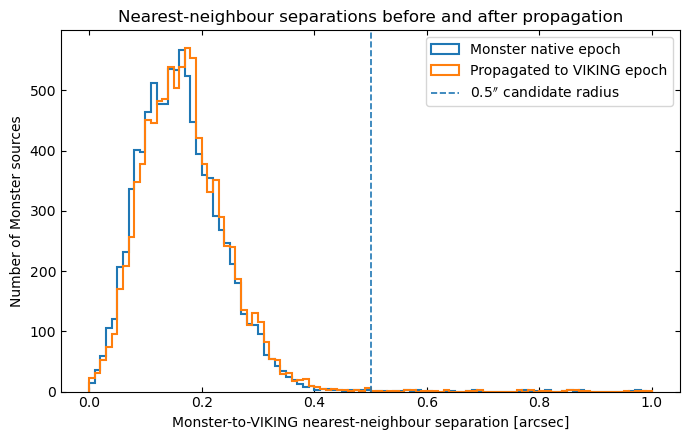

Saved: data/outputs/Monster_VIKING_Z/development_tile_separation_before_after_propagation.pdf


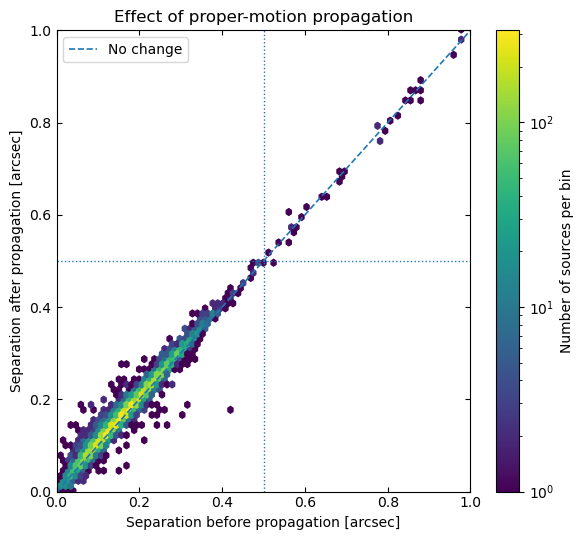

Saved: data/outputs/Monster_VIKING_Z/development_tile_separation_before_vs_after.pdf

Prepared variables for the next step:
  nearest_viking_index_native       : nearest VIKING row before propagation
  nearest_viking_index_propagated   : nearest VIKING row after propagation
  separation_native_arcsec          : native-epoch nearest-neighbour separation
  separation_propagated_arcsec      : propagated nearest-neighbour separation
  propagated_within_match_radius    : one-direction candidates within 0.5 arcsec


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# -------------------------------------------------------------------
# Match Monster to VIKING before and after proper-motion propagation
# -------------------------------------------------------------------

nearest_viking_index_native, separation_native, _ = (
    monster_coordinates_native.match_to_catalog_sky(
        viking_coordinates
    )
)

nearest_viking_index_propagated, separation_propagated, _ = (
    monster_coordinates_viking_epoch.match_to_catalog_sky(
        viking_coordinates
    )
)

separation_native_arcsec = separation_native.arcsec
separation_propagated_arcsec = separation_propagated.arcsec


# Positive values mean that propagation reduced the separation.
separation_improvement_arcsec = (
    separation_native_arcsec
    - separation_propagated_arcsec
)

same_nearest_neighbour = (
    nearest_viking_index_native
    == nearest_viking_index_propagated
)


# -------------------------------------------------------------------
# Helper functions for robust statistics
# -------------------------------------------------------------------

def robust_nmad(values):
    """
    Calculate 1.4826 times the median absolute deviation.

    For a Gaussian distribution, this is comparable to the standard
    deviation but is much less sensitive to outliers.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    median = np.median(values)

    return 1.4826 * np.median(
        np.abs(values - median)
    )


def offset_statistics(
    monster_coordinates,
    viking_indices,
    selection,
):
    """
    Calculate VIKING-minus-Monster tangent-plane coordinate offsets.
    """
    selection = np.asarray(selection, dtype=bool)

    if not np.any(selection):
        return {
            "n": 0,
            "median_dra_arcsec": np.nan,
            "nmad_dra_arcsec": np.nan,
            "median_ddec_arcsec": np.nan,
            "nmad_ddec_arcsec": np.nan,
        }

    selected_monster = monster_coordinates[selection]

    selected_viking = viking_coordinates[
        viking_indices[selection]
    ]

    delta_ra_cosdec, delta_dec = (
        selected_monster.spherical_offsets_to(
            selected_viking
        )
    )

    delta_ra_arcsec = delta_ra_cosdec.arcsec
    delta_dec_arcsec = delta_dec.arcsec

    return {
        "n": int(np.count_nonzero(selection)),
        "median_dra_arcsec": float(
            np.median(delta_ra_arcsec)
        ),
        "nmad_dra_arcsec": float(
            robust_nmad(delta_ra_arcsec)
        ),
        "median_ddec_arcsec": float(
            np.median(delta_dec_arcsec)
        ),
        "nmad_ddec_arcsec": float(
            robust_nmad(delta_dec_arcsec)
        ),
    }


# -------------------------------------------------------------------
# Compare candidate counts at several matching radii
# -------------------------------------------------------------------

matching_radii_arcsec = [
    0.2,
    0.3,
    0.4,
    0.5,
    0.75,
    1.0,
    2.0,
]

radius_records = []

for radius_arcsec in matching_radii_arcsec:
    native_within_radius = (
        separation_native_arcsec <= radius_arcsec
    )

    propagated_within_radius = (
        separation_propagated_arcsec <= radius_arcsec
    )

    entered_after_propagation = (
        ~native_within_radius
        & propagated_within_radius
    )

    left_after_propagation = (
        native_within_radius
        & ~propagated_within_radius
    )

    radius_records.append(
        {
            "radius_arcsec": radius_arcsec,
            "native_candidates":
                int(np.count_nonzero(native_within_radius)),
            "propagated_candidates":
                int(np.count_nonzero(propagated_within_radius)),
            "net_change":
                int(
                    np.count_nonzero(propagated_within_radius)
                    - np.count_nonzero(native_within_radius)
                ),
            "entered_after_propagation":
                int(np.count_nonzero(entered_after_propagation)),
            "left_after_propagation":
                int(np.count_nonzero(left_after_propagation)),
        }
    )

radius_comparison = pd.DataFrame(radius_records)


print("=" * 72)
print("NEAREST-NEIGHBOUR COMPARISON")
print("=" * 72)

display(radius_comparison)


# -------------------------------------------------------------------
# Detailed comparison at the intended 0.5-arcsec radius
# -------------------------------------------------------------------

MATCH_RADIUS_ARCSEC = 0.5

native_within_match_radius = (
    separation_native_arcsec <= MATCH_RADIUS_ARCSEC
)

propagated_within_match_radius = (
    separation_propagated_arcsec <= MATCH_RADIUS_ARCSEC
)

entered_match_radius = (
    ~native_within_match_radius
    & propagated_within_match_radius
)

left_match_radius = (
    native_within_match_radius
    & ~propagated_within_match_radius
)

within_radius_in_both = (
    native_within_match_radius
    & propagated_within_match_radius
)

counterpart_changed = ~same_nearest_neighbour

counterpart_changed_near_match = (
    counterpart_changed
    & (
        native_within_match_radius
        | propagated_within_match_radius
    )
)


print("\nDetailed results at 0.5 arcsec")
print("--------------------------------")

print(
    f"Candidates before propagation : "
    f"{np.count_nonzero(native_within_match_radius):,}"
)

print(
    f"Candidates after propagation  : "
    f"{np.count_nonzero(propagated_within_match_radius):,}"
)

print(
    f"Entered the 0.5-arcsec sample : "
    f"{np.count_nonzero(entered_match_radius):,}"
)

print(
    f"Left the 0.5-arcsec sample    : "
    f"{np.count_nonzero(left_match_radius):,}"
)

print(
    f"Within 0.5 arcsec in both     : "
    f"{np.count_nonzero(within_radius_in_both):,}"
)

print(
    f"Nearest counterpart changed   : "
    f"{np.count_nonzero(counterpart_changed):,}"
)

print(
    f"Counterpart changed near 0.5\" : "
    f"{np.count_nonzero(counterpart_changed_near_match):,}"
)


# -------------------------------------------------------------------
# Separation-improvement statistics
# -------------------------------------------------------------------

diagnostic_candidate = (
    (separation_native_arcsec <= 1.0)
    | (separation_propagated_arcsec <= 1.0)
)

diagnostic_improvement = separation_improvement_arcsec[
    diagnostic_candidate
]


print("\nSeparation changes for candidates within 1 arcsec")
print("-------------------------------------------------")

print(
    f"Number of diagnostic candidates : "
    f"{np.count_nonzero(diagnostic_candidate):,}"
)

print(
    f"Median improvement              : "
    f"{np.median(diagnostic_improvement):.6f} arcsec"
)

print(
    f"NMAD of improvement            : "
    f"{robust_nmad(diagnostic_improvement):.6f} arcsec"
)

print(
    f"Improved after propagation     : "
    f"{np.count_nonzero(diagnostic_improvement > 0):,}"
)

print(
    f"Worsened after propagation     : "
    f"{np.count_nonzero(diagnostic_improvement < 0):,}"
)

print(
    f"Improved by more than 0.02\"    : "
    f"{np.count_nonzero(diagnostic_improvement > 0.02):,}"
)

print(
    f"Improved by more than 0.10\"    : "
    f"{np.count_nonzero(diagnostic_improvement > 0.10):,}"
)


# -------------------------------------------------------------------
# Check the effect for high-proper-motion sources
# -------------------------------------------------------------------

for proper_motion_limit in [50.0, 100.0, 500.0]:
    high_pm = (
        proper_motion_total_mas_per_year
        > proper_motion_limit
    )

    high_pm_near_match = (
        high_pm
        & (
            native_within_match_radius
            | propagated_within_match_radius
        )
    )

    if np.any(high_pm_near_match):
        median_high_pm_improvement = np.median(
            separation_improvement_arcsec[
                high_pm_near_match
            ]
        )
    else:
        median_high_pm_improvement = np.nan

    print(
        f"\nPM > {proper_motion_limit:5.1f} mas/yr:"
    )

    print(
        f"  Total Monster sources      : "
        f"{np.count_nonzero(high_pm):,}"
    )

    print(
        f"  Near the 0.5\" match sample: "
        f"{np.count_nonzero(high_pm_near_match):,}"
    )

    print(
        f"  Median separation gain     : "
        f"{median_high_pm_improvement:.6f} arcsec"
    )


# -------------------------------------------------------------------
# Residual coordinate offsets before and after propagation
# -------------------------------------------------------------------

native_offset_stats = offset_statistics(
    monster_coordinates_native,
    nearest_viking_index_native,
    native_within_match_radius,
)

propagated_offset_stats = offset_statistics(
    monster_coordinates_viking_epoch,
    nearest_viking_index_propagated,
    propagated_within_match_radius,
)

offset_comparison = pd.DataFrame(
    [
        {
            "coordinate_epoch": "Monster native epoch",
            **native_offset_stats,
        },
        {
            "coordinate_epoch": "Propagated to VIKING epoch",
            **propagated_offset_stats,
        },
    ]
)


print("\nCoordinate residuals for candidates within 0.5 arcsec")
print("------------------------------------------------------")

display(offset_comparison)


# -------------------------------------------------------------------
# Plot 1: nearest-neighbour separation distributions
# -------------------------------------------------------------------

separation_plot_limit = 1.0

separation_bins = np.linspace(
    0.0,
    separation_plot_limit,
    101,
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    separation_native_arcsec[
        separation_native_arcsec <= separation_plot_limit
    ],
    bins=separation_bins,
    histtype="step",
    linewidth=1.5,
    label="Monster native epoch",
)

ax.hist(
    separation_propagated_arcsec[
        separation_propagated_arcsec <= separation_plot_limit
    ],
    bins=separation_bins,
    histtype="step",
    linewidth=1.5,
    label="Propagated to VIKING epoch",
)

ax.axvline(
    MATCH_RADIUS_ARCSEC,
    linestyle="--",
    linewidth=1.2,
    label=r"$0.5''$ candidate radius",
)

ax.set_xlabel("Monster-to-VIKING nearest-neighbour separation [arcsec]")
ax.set_ylabel("Number of Monster sources")
ax.set_title("Nearest-neighbour separations before and after propagation")
ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

fig.tight_layout()

separation_histogram_path = (
    OUTPUT_DIR
    / "development_tile_separation_before_after_propagation.pdf"
)

fig.savefig(
    separation_histogram_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {separation_histogram_path}")


# -------------------------------------------------------------------
# Plot 2: direct before-versus-after separation comparison
# -------------------------------------------------------------------

comparison_selection = (
    (separation_native_arcsec <= 1.0)
    | (separation_propagated_arcsec <= 1.0)
)

fig, ax = plt.subplots(figsize=(6, 5.5))

hexbin = ax.hexbin(
    separation_native_arcsec[comparison_selection],
    separation_propagated_arcsec[comparison_selection],
    gridsize=80,
    mincnt=1,
    bins="log",
)

ax.plot(
    [0.0, 1.0],
    [0.0, 1.0],
    linestyle="--",
    linewidth=1.2,
    label="No change",
)

ax.axhline(
    MATCH_RADIUS_ARCSEC,
    linestyle=":",
    linewidth=1.0,
)

ax.axvline(
    MATCH_RADIUS_ARCSEC,
    linestyle=":",
    linewidth=1.0,
)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

ax.set_xlabel("Separation before propagation [arcsec]")
ax.set_ylabel("Separation after propagation [arcsec]")
ax.set_title("Effect of proper-motion propagation")

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label("Number of sources per bin")

fig.tight_layout()

comparison_plot_path = (
    OUTPUT_DIR
    / "development_tile_separation_before_vs_after.pdf"
)

fig.savefig(
    comparison_plot_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {comparison_plot_path}")


# -------------------------------------------------------------------
# Variables retained for the mutual-matching step
# -------------------------------------------------------------------

print("\nPrepared variables for the next step:")
print(
    "  nearest_viking_index_native       : "
    "nearest VIKING row before propagation"
)

print(
    "  nearest_viking_index_propagated   : "
    "nearest VIKING row after propagation"
)

print(
    "  separation_native_arcsec          : "
    "native-epoch nearest-neighbour separation"
)

print(
    "  separation_propagated_arcsec      : "
    "propagated nearest-neighbour separation"
)

print(
    "  propagated_within_match_radius    : "
    "one-direction candidates within 0.5 arcsec"
)

### Result

Using a \(0.5''\) radius gives 9,490 nearest-neighbour candidates both before
and after propagation. Propagation changes very few candidate associations,
but the residual distribution retains a small systematic astrometric offset
between the VIKING and Monster reference frames. I do not subtract this
offset and continue with the physically defined VIKING observing epoch.

## 6. Construct the final Gold astrometric match

The final astrometric associations are constructed using the recorded VIKING
observing epoch derived from the median source-level `MJD`. This follows the
matching direction recommended for VISTA catalogues with known observation
dates:

$$
\text{Monster reference epoch}
\longrightarrow
\text{VIKING observing epoch}.
$$

For each Monster source with valid coordinates, reference epoch, and
two-component proper motion, I propagate the Monster position to the median
observing epoch of the VIKING tile. The right-ascension proper motion follows
the LSST reference-catalogue convention

$$
\mu_{\alpha^\ast}
=
\frac{d\alpha}{dt}\cos\delta.
$$

The Gold sample is then defined by the following requirements:

- the Monster source has valid two-component proper motion;
- the second-nearest Monster source is farther than \(1''\);
- Monster and VIKING identify each other as their nearest neighbours;
- the final angular separation is smaller than \(0.5''\).

This is the same high-purity matching strategy used for the DP1/VIDEO
catalogue.

The propagated Monster coordinates are used only to establish the
associations. The original Gaia-tied Monster coordinates are retained in the
output catalogue. A residual bulk offset between the two astrometric systems
is measured and reported, but it is not subtracted.

FINAL GOLD ASTROMETRIC MATCH
VIKING tile                     : ADP.2020-03-02T18:38:39.084.fits
Recorded VIKING epoch           : 2017.07559945
Valid Monster PM sources        : 44,696
Monster sources isolated > 1"   : 44,662
Mutual nearest neighbours       : 9,636
Gold matches within 0.5"        : 9,485
Gold matches within 0.3"        : 9,022
Unique Monster sources          : 9,485
Unique VIKING sources           : 9,485

Separation statistics
---------------------
Median separation               : 0.163675 arcsec
Separation NMAD                 : 0.071796 arcsec
16th--84th percentile           : 0.097158 -- 0.239746 arcsec
95th percentile                 : 0.298775 arcsec

VIKING minus propagated Monster residuals
-----------------------------------------
Median Delta RA cos(Dec)        : +0.066126 arcsec
NMAD Delta RA cos(Dec)          : 0.103153 arcsec
Median Delta Dec                : +0.116426 arcsec
NMAD Delta Dec                  : 0.078387 arcsec
Median residual-vector amplitu

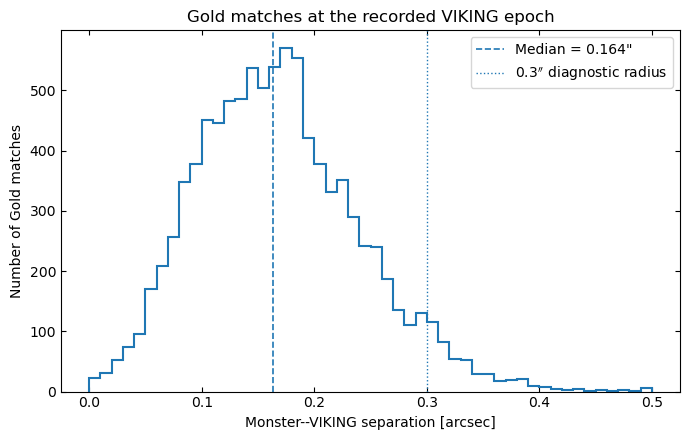

Saved: data/outputs/Monster_VIKING_Z/development_tile_gold_separations_recorded_epoch.pdf


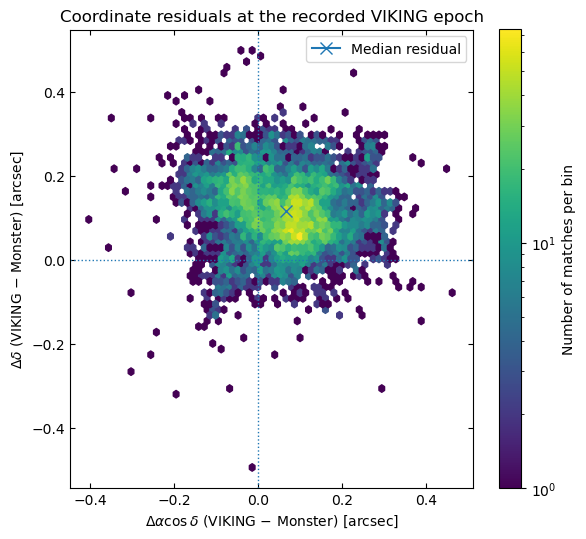

Saved: data/outputs/Monster_VIKING_Z/development_tile_gold_residuals_recorded_epoch.pdf


In [8]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.time import Time
import astropy.units as u


# -------------------------------------------------------------------
# Final matching configuration
# -------------------------------------------------------------------

MATCH_RADIUS = 0.5 * u.arcsec
MONSTER_ISOLATION_RADIUS = 1.0 * u.arcsec

viking_mjd_utc = float(
    development_tile["effective_mjd"]
)

viking_time_utc = Time(
    viking_mjd_utc,
    format="mjd",
    scale="utc",
)

# Monster epochs are stored as TAI MJD.
viking_mjd_tai = float(
    viking_time_utc.tai.mjd
)

viking_epoch_jyear = float(
    viking_time_utc.jyear
)


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def as_float_array(column):
    """Convert an ordinary or masked table column to a float array."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(column, dtype=float),
            np.nan,
        ),
        dtype=float,
    )


def robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    median = np.median(values)

    return float(
        1.4826
        * np.median(
            np.abs(values - median)
        )
    )


# -------------------------------------------------------------------
# Read Monster astrometric quantities
#
# pm_ra is interpreted as mu_alpha* in rad/year, following the LSST
# reference-catalogue schema, even though its FITS unit metadata may
# be displayed simply as "rad".
# -------------------------------------------------------------------

monster_ra_native_rad = as_float_array(
    monster["coord_ra"]
)

monster_dec_native_rad = as_float_array(
    monster["coord_dec"]
)

monster_epoch_tai_mjd = as_float_array(
    monster["epoch"]
)

monster_pmra_rad_per_year = as_float_array(
    monster["pm_ra"]
)

monster_pmdec_rad_per_year = as_float_array(
    monster["pm_dec"]
)

cos_monster_dec = np.cos(
    monster_dec_native_rad
)


# -------------------------------------------------------------------
# Select Monster sources with complete propagation information
# -------------------------------------------------------------------

valid_monster_astrometry = (
    np.isfinite(monster_ra_native_rad)
    & np.isfinite(monster_dec_native_rad)
    & np.isfinite(monster_epoch_tai_mjd)
    & np.isfinite(monster_pmra_rad_per_year)
    & np.isfinite(monster_pmdec_rad_per_year)
    & (monster_dec_native_rad >= -0.5 * np.pi)
    & (monster_dec_native_rad <= 0.5 * np.pi)
    & (np.abs(cos_monster_dec) > 1.0e-10)
)

valid_monster_indices = np.flatnonzero(
    valid_monster_astrometry
)

monster_ra0 = monster_ra_native_rad[
    valid_monster_astrometry
]

monster_dec0 = monster_dec_native_rad[
    valid_monster_astrometry
]

monster_epoch0 = monster_epoch_tai_mjd[
    valid_monster_astrometry
]

monster_pmra = monster_pmra_rad_per_year[
    valid_monster_astrometry
]

monster_pmdec = monster_pmdec_rad_per_year[
    valid_monster_astrometry
]


# -------------------------------------------------------------------
# Propagate Monster to the recorded VIKING observing epoch
# -------------------------------------------------------------------

delta_time_year = (
    viking_mjd_tai
    - monster_epoch0
) / 365.25

monster_ra_viking_epoch = (
    monster_ra0
    + (
        monster_pmra
        * delta_time_year
        / np.cos(monster_dec0)
    )
)

monster_dec_viking_epoch = (
    monster_dec0
    + monster_pmdec
    * delta_time_year
)

monster_ra_viking_epoch = np.mod(
    monster_ra_viking_epoch,
    2.0 * np.pi,
)

valid_propagated_coordinates = (
    np.isfinite(monster_ra_viking_epoch)
    & np.isfinite(monster_dec_viking_epoch)
    & (monster_dec_viking_epoch >= -0.5 * np.pi)
    & (monster_dec_viking_epoch <= 0.5 * np.pi)
)

if not np.all(valid_propagated_coordinates):
    valid_monster_indices = valid_monster_indices[
        valid_propagated_coordinates
    ]

    monster_ra0 = monster_ra0[
        valid_propagated_coordinates
    ]

    monster_dec0 = monster_dec0[
        valid_propagated_coordinates
    ]

    monster_epoch0 = monster_epoch0[
        valid_propagated_coordinates
    ]

    monster_pmra = monster_pmra[
        valid_propagated_coordinates
    ]

    monster_pmdec = monster_pmdec[
        valid_propagated_coordinates
    ]

    delta_time_year = delta_time_year[
        valid_propagated_coordinates
    ]

    monster_ra_viking_epoch = (
        monster_ra_viking_epoch[
            valid_propagated_coordinates
        ]
    )

    monster_dec_viking_epoch = (
        monster_dec_viking_epoch[
            valid_propagated_coordinates
        ]
    )


monster_coordinates_viking_epoch = SkyCoord(
    ra=monster_ra_viking_epoch * u.rad,
    dec=monster_dec_viking_epoch * u.rad,
    frame="icrs",
)


# -------------------------------------------------------------------
# Reconstruct the valid VIKING coordinate catalogue
# -------------------------------------------------------------------

viking_ra_deg = as_float_array(
    viking["RA"]
)

viking_dec_deg = as_float_array(
    viking["DEC"]
)

valid_viking_coordinates = (
    np.isfinite(viking_ra_deg)
    & np.isfinite(viking_dec_deg)
    & (viking_ra_deg >= 0.0)
    & (viking_ra_deg <= 360.0)
    & (viking_dec_deg >= -90.0)
    & (viking_dec_deg <= 90.0)
)

viking_original_indices = np.flatnonzero(
    valid_viking_coordinates
)

viking_coordinates = SkyCoord(
    ra=viking_ra_deg[
        valid_viking_coordinates
    ] * u.deg,

    dec=viking_dec_deg[
        valid_viking_coordinates
    ] * u.deg,

    frame="icrs",
)


# -------------------------------------------------------------------
# Apply Monster-side isolation
# -------------------------------------------------------------------

_, monster_second_neighbour_separation, _ = (
    match_coordinates_sky(
        monster_coordinates_viking_epoch,
        monster_coordinates_viking_epoch,
        nthneighbor=2,
    )
)

monster_isolated = (
    monster_second_neighbour_separation
    > MONSTER_ISOLATION_RADIUS
)

isolated_monster_coordinates = (
    monster_coordinates_viking_epoch[
        monster_isolated
    ]
)

isolated_monster_indices = (
    valid_monster_indices[
        monster_isolated
    ]
)

isolated_second_neighbour_arcsec = (
    monster_second_neighbour_separation[
        monster_isolated
    ].arcsec
)


# -------------------------------------------------------------------
# Perform nearest-neighbour matching in both directions
# -------------------------------------------------------------------

# Monster -> VIKING
nearest_viking_for_monster, separation_mv, _ = (
    match_coordinates_sky(
        isolated_monster_coordinates,
        viking_coordinates,
    )
)

# VIKING -> Monster
nearest_monster_for_viking, _, _ = (
    match_coordinates_sky(
        viking_coordinates,
        isolated_monster_coordinates,
    )
)

isolated_monster_row = np.arange(
    len(isolated_monster_coordinates)
)

mutual_nearest_neighbour = (
    nearest_monster_for_viking[
        nearest_viking_for_monster
    ]
    == isolated_monster_row
)

within_match_radius = (
    separation_mv < MATCH_RADIUS
)

gold_mask = (
    mutual_nearest_neighbour
    & within_match_radius
)


# -------------------------------------------------------------------
# Recover the original table indices
# -------------------------------------------------------------------

gold_monster_indices = (
    isolated_monster_indices[
        gold_mask
    ]
)

gold_viking_coordinate_indices = (
    nearest_viking_for_monster[
        gold_mask
    ]
)

gold_viking_indices = (
    viking_original_indices[
        gold_viking_coordinate_indices
    ]
)

gold_monster_coordinates = (
    isolated_monster_coordinates[
        gold_mask
    ]
)

gold_viking_coordinates = (
    viking_coordinates[
        gold_viking_coordinate_indices
    ]
)

gold_separation_arcsec = (
    separation_mv[
        gold_mask
    ].arcsec
)

gold_second_neighbour_arcsec = (
    isolated_second_neighbour_arcsec[
        gold_mask
    ]
)


# -------------------------------------------------------------------
# Calculate VIKING-minus-Monster coordinate residuals
# -------------------------------------------------------------------

delta_ra_cosdec, delta_dec = (
    gold_monster_coordinates.spherical_offsets_to(
        gold_viking_coordinates
    )
)

delta_ra_cosdec_arcsec = (
    delta_ra_cosdec.arcsec
)

delta_dec_arcsec = (
    delta_dec.arcsec
)

median_delta_ra = float(
    np.median(delta_ra_cosdec_arcsec)
)

median_delta_dec = float(
    np.median(delta_dec_arcsec)
)

median_offset_amplitude = float(
    np.hypot(
        median_delta_ra,
        median_delta_dec,
    )
)


# -------------------------------------------------------------------
# Construct the Gold matched catalogue
# -------------------------------------------------------------------

gold_matches = Table()

gold_matches["monster_original_index"] = (
    gold_monster_indices.astype(np.int64)
)

gold_matches["viking_original_index"] = (
    gold_viking_indices.astype(np.int64)
)

gold_matches["monster_id"] = np.asarray(
    monster["id"][
        gold_monster_indices
    ],
    dtype=np.int64,
)

gold_matches["viking_file"] = np.full(
    len(gold_matches),
    development_tile["name"],
)

gold_matches["matching_epoch_method"] = np.full(
    len(gold_matches),
    "median_viking_source_mjd",
)

gold_matches["viking_epoch_utc_mjd"] = np.full(
    len(gold_matches),
    viking_mjd_utc,
)

gold_matches["viking_epoch_jyear"] = np.full(
    len(gold_matches),
    viking_epoch_jyear,
)


# Original Gaia-tied Monster positions
gold_matches["monster_ra_native_deg"] = np.degrees(
    as_float_array(
        monster["coord_ra"][
            gold_monster_indices
        ]
    )
)

gold_matches["monster_dec_native_deg"] = np.degrees(
    as_float_array(
        monster["coord_dec"][
            gold_monster_indices
        ]
    )
)


# Propagated coordinates used for matching
gold_matches["monster_ra_match_deg"] = (
    gold_monster_coordinates.ra.degree
)

gold_matches["monster_dec_match_deg"] = (
    gold_monster_coordinates.dec.degree
)


# Native VIKING coordinates
gold_matches["viking_ra_deg"] = (
    gold_viking_coordinates.ra.degree
)

gold_matches["viking_dec_deg"] = (
    gold_viking_coordinates.dec.degree
)


# Match diagnostics
gold_matches["separation_arcsec"] = (
    gold_separation_arcsec
)

gold_matches["delta_ra_cosdec_arcsec"] = (
    delta_ra_cosdec_arcsec
)

gold_matches["delta_dec_arcsec"] = (
    delta_dec_arcsec
)

gold_matches[
    "monster_second_neighbour_arcsec"
] = gold_second_neighbour_arcsec


# -------------------------------------------------------------------
# Add Monster astrometry
# -------------------------------------------------------------------

radian_to_milliarcsec = u.rad.to(u.mas)

monster_pmra_gold = as_float_array(
    monster["pm_ra"][
        gold_monster_indices
    ]
)

monster_pmdec_gold = as_float_array(
    monster["pm_dec"][
        gold_monster_indices
    ]
)

gold_matches[
    "monster_pmra_mas_per_year"
] = (
    monster_pmra_gold
    * radian_to_milliarcsec
)

gold_matches[
    "monster_pmdec_mas_per_year"
] = (
    monster_pmdec_gold
    * radian_to_milliarcsec
)

gold_matches[
    "monster_pm_total_mas_per_year"
] = np.hypot(
    gold_matches[
        "monster_pmra_mas_per_year"
    ],
    gold_matches[
        "monster_pmdec_mas_per_year"
    ],
)

gold_matches["monster_epoch_tai_mjd"] = (
    as_float_array(
        monster["epoch"][
            gold_monster_indices
        ]
    )
)


# -------------------------------------------------------------------
# Add Monster DES photometry
# -------------------------------------------------------------------

monster_photometric_columns = {
    "monster_DES_i_flux":
        "monster_DES_i_flux_nJy",

    "monster_DES_i_fluxErr":
        "monster_DES_i_fluxErr_nJy",

    "monster_DES_z_flux":
        "monster_DES_z_flux_nJy",

    "monster_DES_z_fluxErr":
        "monster_DES_z_fluxErr_nJy",
}

for input_name, output_name in (
    monster_photometric_columns.items()
):
    if input_name not in monster.colnames:
        raise KeyError(
            f"Required Monster column is missing: "
            f"{input_name}"
        )

    gold_matches[output_name] = (
        as_float_array(
            monster[input_name][
                gold_monster_indices
            ]
        )
    )


# -------------------------------------------------------------------
# Add native VIKING Z photometry and quality columns
# -------------------------------------------------------------------

required_viking_columns = [
    "MJD",
    "APERFLUX3",
    "APERFLUX3ERR",
    "APERMAG3",
    "APERMAG3ERR",
    "CLASS",
    "CLASSSTAT",
    "PPERRBITS",
]

missing_viking_columns = [
    name
    for name in required_viking_columns
    if name not in viking.colnames
]

if missing_viking_columns:
    raise KeyError(
        "The VIKING catalogue is missing columns: "
        f"{missing_viking_columns}"
    )


gold_matches["viking_mjd"] = (
    as_float_array(
        viking["MJD"][
            gold_viking_indices
        ]
    )
)

gold_matches["viking_z_aperflux3_adu"] = (
    as_float_array(
        viking["APERFLUX3"][
            gold_viking_indices
        ]
    )
)

gold_matches[
    "viking_z_aperflux3err_adu"
] = (
    as_float_array(
        viking["APERFLUX3ERR"][
            gold_viking_indices
        ]
    )
)

gold_matches["viking_z_apermag3_vega"] = (
    as_float_array(
        viking["APERMAG3"][
            gold_viking_indices
        ]
    )
)

gold_matches["viking_z_apermag3err"] = (
    as_float_array(
        viking["APERMAG3ERR"][
            gold_viking_indices
        ]
    )
)

gold_matches["viking_class"] = np.asarray(
    viking["CLASS"][
        gold_viking_indices
    ],
    dtype=np.int16,
)

gold_matches["viking_classstat"] = (
    as_float_array(
        viking["CLASSSTAT"][
            gold_viking_indices
        ]
    )
)

gold_matches["viking_pperrbits"] = np.asarray(
    viking["PPERRBITS"][
        gold_viking_indices
    ],
    dtype=np.int64,
)

if "AVERAGECONF" in viking.colnames:
    gold_matches["viking_averageconf"] = (
        as_float_array(
            viking["AVERAGECONF"][
                gold_viking_indices
            ]
        )
    )


# -------------------------------------------------------------------
# Calculate the correct VIKING flux signal-to-noise ratio
# -------------------------------------------------------------------

viking_flux = np.asarray(
    gold_matches[
        "viking_z_aperflux3_adu"
    ],
    dtype=float,
)

viking_flux_error = np.asarray(
    gold_matches[
        "viking_z_aperflux3err_adu"
    ],
    dtype=float,
)

viking_flux_snr = np.full(
    len(gold_matches),
    np.nan,
    dtype=float,
)

valid_viking_flux = (
    np.isfinite(viking_flux)
    & np.isfinite(viking_flux_error)
    & (viking_flux > 0.0)
    & (viking_flux_error > 0.0)
)

viking_flux_snr[
    valid_viking_flux
] = (
    viking_flux[
        valid_viking_flux
    ]
    / viking_flux_error[
        valid_viking_flux
    ]
)

gold_matches[
    "viking_z_aperflux3_snr"
] = viking_flux_snr


# -------------------------------------------------------------------
# Verify that the result is one-to-one
# -------------------------------------------------------------------

n_unique_monster = len(
    np.unique(
        np.asarray(
            gold_matches["monster_id"],
            dtype=np.int64,
        )
    )
)

n_unique_viking = len(
    np.unique(
        np.asarray(
            gold_matches[
                "viking_original_index"
            ],
            dtype=np.int64,
        )
    )
)

if n_unique_monster != len(gold_matches):
    raise RuntimeError(
        "Repeated Monster sources remain in the Gold catalogue."
    )

if n_unique_viking != len(gold_matches):
    raise RuntimeError(
        "Repeated VIKING sources remain in the Gold catalogue."
    )


# -------------------------------------------------------------------
# Print the final astrometric summary
# -------------------------------------------------------------------

print("=" * 72)
print("FINAL GOLD ASTROMETRIC MATCH")
print("=" * 72)

print(
    f"VIKING tile                     : "
    f"{development_tile['name']}"
)

print(
    f"Recorded VIKING epoch           : "
    f"{viking_epoch_jyear:.8f}"
)

print(
    f"Valid Monster PM sources        : "
    f"{len(monster_coordinates_viking_epoch):,}"
)

print(
    f"Monster sources isolated > 1\"   : "
    f"{np.count_nonzero(monster_isolated):,}"
)

print(
    f"Mutual nearest neighbours       : "
    f"{np.count_nonzero(mutual_nearest_neighbour):,}"
)

print(
    f"Gold matches within 0.5\"        : "
    f"{len(gold_matches):,}"
)

print(
    f"Gold matches within 0.3\"        : "
    f"{np.count_nonzero(gold_separation_arcsec < 0.3):,}"
)

print(
    f"Unique Monster sources          : "
    f"{n_unique_monster:,}"
)

print(
    f"Unique VIKING sources           : "
    f"{n_unique_viking:,}"
)


print("\nSeparation statistics")
print("---------------------")

print(
    f"Median separation               : "
    f"{np.median(gold_separation_arcsec):.6f} arcsec"
)

print(
    f"Separation NMAD                 : "
    f"{robust_nmad(gold_separation_arcsec):.6f} arcsec"
)

print(
    f"16th--84th percentile           : "
    f"{np.percentile(gold_separation_arcsec, 16):.6f} -- "
    f"{np.percentile(gold_separation_arcsec, 84):.6f} arcsec"
)

print(
    f"95th percentile                 : "
    f"{np.percentile(gold_separation_arcsec, 95):.6f} arcsec"
)


print("\nVIKING minus propagated Monster residuals")
print("-----------------------------------------")

print(
    f"Median Delta RA cos(Dec)        : "
    f"{median_delta_ra:+.6f} arcsec"
)

print(
    f"NMAD Delta RA cos(Dec)          : "
    f"{robust_nmad(delta_ra_cosdec_arcsec):.6f} arcsec"
)

print(
    f"Median Delta Dec                : "
    f"{median_delta_dec:+.6f} arcsec"
)

print(
    f"NMAD Delta Dec                  : "
    f"{robust_nmad(delta_dec_arcsec):.6f} arcsec"
)

print(
    f"Median residual-vector amplitude: "
    f"{median_offset_amplitude:.6f} arcsec"
)

print(
    "\nNo bulk astrometric offset was subtracted."
)


# -------------------------------------------------------------------
# Save the corrected Gold catalogue
# -------------------------------------------------------------------

gold_match_path = (
    OUTPUT_DIR
    / "development_tile_gold_matches_recorded_viking_epoch.ecsv"
)

gold_matches.write(
    gold_match_path,
    format="ascii.ecsv",
    overwrite=True,
)

print(
    f"\nSaved Gold catalogue:\n"
    f"{gold_match_path}"
)


# -------------------------------------------------------------------
# Plot the Gold-match separation distribution
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

ax.hist(
    gold_separation_arcsec,
    bins=np.linspace(
        0.0,
        0.5,
        51,
    ),
    histtype="step",
    linewidth=1.5,
)

ax.axvline(
    np.median(
        gold_separation_arcsec
    ),
    linestyle="--",
    linewidth=1.2,
    label=(
        "Median = "
        f"{np.median(gold_separation_arcsec):.3f}\""
    ),
)

ax.axvline(
    0.3,
    linestyle=":",
    linewidth=1.0,
    label=r"$0.3''$ diagnostic radius",
)

ax.set_xlabel(
    "Monster--VIKING separation [arcsec]"
)

ax.set_ylabel(
    "Number of Gold matches"
)

ax.set_title(
    "Gold matches at the recorded VIKING epoch"
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

fig.tight_layout()

separation_plot_path = (
    OUTPUT_DIR
    / "development_tile_gold_separations_recorded_epoch.pdf"
)

fig.savefig(
    separation_plot_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {separation_plot_path}"
)


# -------------------------------------------------------------------
# Plot the coordinate residual distribution
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6, 5.5)
)

hexbin = ax.hexbin(
    delta_ra_cosdec_arcsec,
    delta_dec_arcsec,
    gridsize=65,
    mincnt=1,
    bins="log",
)

ax.axvline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

ax.plot(
    median_delta_ra,
    median_delta_dec,
    marker="x",
    markersize=9,
    label="Median residual",
)

ax.set_xlabel(
    r"$\Delta\alpha\cos\delta$ "
    r"(VIKING $-$ Monster) [arcsec]"
)

ax.set_ylabel(
    r"$\Delta\delta$ "
    r"(VIKING $-$ Monster) [arcsec]"
)

ax.set_title(
    "Coordinate residuals at the recorded VIKING epoch"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of matches per bin"
)

fig.tight_layout()

residual_plot_path = (
    OUTPUT_DIR
    / "development_tile_gold_residuals_recorded_epoch.pdf"
)

fig.savefig(
    residual_plot_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {residual_plot_path}"
)


### Result

Propagating Monster sources to the recorded VIKING epoch
2017.0756 and applying the mutual nearest-neighbour, Monster-isolation,
and 0.5'' separation requirements produced 9,485 unique Gold matches.

The median Monster--VIKING separation is 0.164'', and 9,022 matches
95.1\% lie within 0.3''. The 95th-percentile separation is
0.299'', showing that only a small tail extends beyond 0.3''.

The residual distribution has median offsets of
+0.066'' and +0.116'', corresponding to a residual-vector amplitude of
0.134''. This compact systematic offset is retained as a diagnostic and
is not subtracted from the catalogue.

## 7. Audit the photometric quality of the Gold matches

The Gold catalogue contains secure astrometric associations, but not every
matched source is suitable for deriving a photometric colour transformation.
I therefore inspect the VIKING and Monster photometric measurements before
defining the final calibration-star sample.

For every Gold match, this cell calculates:

- the VIKING Z-band aperture-flux signal-to-noise ratio;
- the Monster DES i- and z-band signal-to-noise ratios;
- the Monster DES i and z AB magnitudes;
- the availability of positive flux measurements in all three bands;
- the distributions of the VIKING `CLASS`, `CLASSSTAT`, `PPERRBITS`, and
  `AVERAGECONF` quantities.

Monster fluxes are stored in nJy, so their AB magnitudes are calculated using

$$
m_{\mathrm{AB}}
=
31.4
-
2.5\log_{10}
\left(
\frac{F_\nu}{\mathrm{nJy}}
\right).
$$

The VIKING `PPERRBITS` column is a bit mask rather than a simple good/bad
flag. A nonzero value can contain one or more individual conditions.
Consequently, I do not yet reject every source with nonzero `PPERRBITS`.
Instead, I report both the most common complete values and the occupancy of
each individual bit. The final bit-mask selection will be chosen after
examining its relation to magnitude and photometric residuals.

An illustrative sequence of conservative cuts is also reported. This sequence
is diagnostic only and does not yet define the final spline sample. In
particular, the S/N threshold of 50 is initially adopted to reproduce the
high-S/N selection used in the earlier VIKING calibration notebooks.

No sources are removed or overwritten in this cell. A copy of the Gold table
with the derived quality quantities is retained for the following analysis.

VIKING CLASS DISTRIBUTION


,viking_class,number_of_gold_matches,fraction_of_gold_sample
0,-2,32,0.003374
1,-1,9031,0.952135
2,0,21,0.002214
3,1,401,0.042277



MOST COMMON COMPLETE PPERRBITS VALUES


,pperrbits_value,number_of_sources,fraction_of_gold_sample
0,0,5934,0.625619
1,16,1342,0.141487
2,8388736,1032,0.108803
3,4096,392,0.041328
4,8388752,170,0.017923
5,8392832,131,0.013811
6,4224,100,0.010543
7,4112,77,0.008118
8,128,50,0.005271
9,12583040,45,0.004744



INDIVIDUAL PPERRBITS BIT OCCUPANCY


...


ILLUSTRATIVE QUALITY-SELECTION COUNTS


,stage,number_remaining,fraction_of_gold_sample
0,Gold astrometric matches,9485,1.000000
1,Positive VIKING Z and Monster DES i/z fluxes,5608,0.591249
2,VIKING CLASS = -1,5471,0.576805
3,VIKING Z S/N >= 50,5471,0.576805
4,Monster DES i S/N >= 50,5396,0.568898
5,Monster DES z S/N >= 50,5277,0.556352
6,Before PPERRBITS and confidence tests,5277,0.556352
7,Additionally require PPERRBITS = 0,3206,0.338007
8,Additionally require AVERAGECONF >= 80,4392,0.463047
9,Additionally require both tests,3206,0.338007



PHOTOMETRIC-QUALITY PERCENTILES


,quantity,p01,p05,p16,median,p84,p95,p99
0,VIKING Z APERMAG3 [Vega],12.663713,14.049646,15.762150,17.792336,18.929365,19.492002,19.896201
1,VIKING Z aperture S/N,36.905817,51.199805,77.833926,163.948490,484.608893,1086.243901,2078.738023
2,Monster DES i S/N,22.641100,34.322061,107.900516,226.692617,407.203251,666.913554,1444.243601
3,Monster DES z S/N,21.336088,48.101148,76.622231,140.777280,268.020784,433.925324,850.599765
4,VIKING CLASSSTAT,-2.481789,-1.580170,-0.930160,0.094195,1.214151,3.628928,21.506001
5,VIKING AVERAGECONF,27.149509,50.055521,62.024434,101.593567,110.525955,111.052223,111.118927



Saved diagnostic tables:
  data/outputs/Monster_VIKING_Z/development_tile_quality_selection_counts.csv
  data/outputs/Monster_VIKING_Z/development_tile_pperrbits_values.csv
  data/outputs/Monster_VIKING_Z/development_tile_pperrbits_bit_occupancy.csv


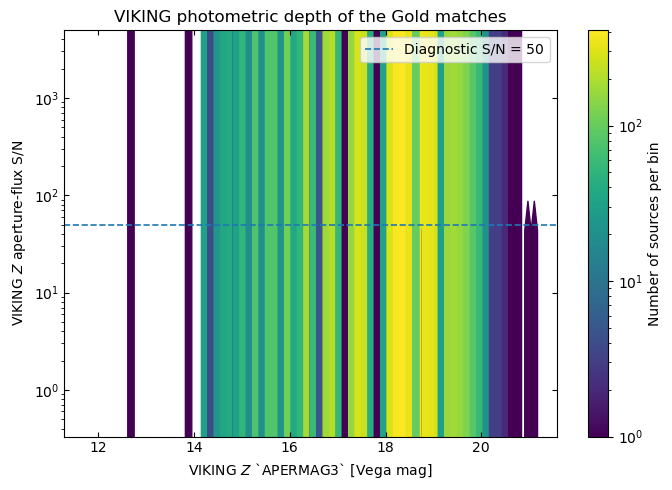

Saved: data/outputs/Monster_VIKING_Z/development_tile_viking_z_snr_vs_magnitude.pdf


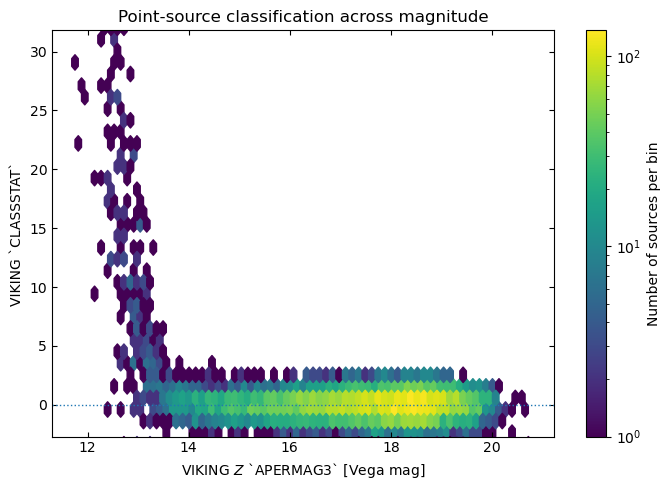

Saved: data/outputs/Monster_VIKING_Z/development_tile_classstat_vs_magnitude.pdf

Prepared variables for the next step:
  gold_quality                  : Gold matches with derived S/N and magnitudes
  quality_stage_summary         : diagnostic staged selection counts
  pperrbits_summary             : frequency of complete PPERRBITS values
  pperrbits_bit_summary         : frequency of individual PPERRBITS bits
  selection_before_flag_tests   : high-S/N stellar candidates before flag cuts


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def as_float_array(column):
    """Convert an ordinary or masked table column into a float array."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(column, dtype=float),
            np.nan,
        ),
        dtype=float,
    )


def safe_signal_to_noise(flux, flux_error):
    """Calculate flux/error only where both values are valid."""
    flux = np.asarray(flux, dtype=float)
    flux_error = np.asarray(flux_error, dtype=float)

    signal_to_noise = np.full(
        len(flux),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(flux)
        & np.isfinite(flux_error)
        & (flux > 0.0)
        & (flux_error > 0.0)
    )

    signal_to_noise[valid] = (
        flux[valid]
        / flux_error[valid]
    )

    return signal_to_noise


def flux_njy_to_abmag(flux_njy):
    """Convert positive nJy fluxes to AB magnitudes."""
    flux_njy = np.asarray(flux_njy, dtype=float)

    magnitude = np.full(
        len(flux_njy),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(flux_njy)
        & (flux_njy > 0.0)
    )

    magnitude[valid] = (
        31.4
        - 2.5 * np.log10(flux_njy[valid])
    )

    return magnitude


# -------------------------------------------------------------------
# Copy the Gold table and read the required measurements
# -------------------------------------------------------------------

gold_quality = gold_matches.copy()

n_gold = len(gold_quality)

viking_flux = as_float_array(
    gold_quality["viking_z_aperflux3_adu"]
)

viking_flux_error = as_float_array(
    gold_quality["viking_z_aperflux3err_adu"]
)

viking_mag_vega = as_float_array(
    gold_quality["viking_z_apermag3_vega"]
)

viking_mag_error = as_float_array(
    gold_quality["viking_z_apermag3err"]
)

monster_i_flux = as_float_array(
    gold_quality["monster_DES_i_flux_nJy"]
)

monster_i_flux_error = as_float_array(
    gold_quality["monster_DES_i_fluxErr_nJy"]
)

monster_z_flux = as_float_array(
    gold_quality["monster_DES_z_flux_nJy"]
)

monster_z_flux_error = as_float_array(
    gold_quality["monster_DES_z_fluxErr_nJy"]
)

viking_class = np.asarray(
    gold_quality["viking_class"],
    dtype=np.int64,
)

viking_classstat = as_float_array(
    gold_quality["viking_classstat"]
)

viking_pperrbits = np.asarray(
    gold_quality["viking_pperrbits"],
    dtype=np.int64,
)

if "viking_averageconf" in gold_quality.colnames:
    viking_averageconf = as_float_array(
        gold_quality["viking_averageconf"]
    )
else:
    viking_averageconf = np.full(
        n_gold,
        np.nan,
        dtype=float,
    )


# -------------------------------------------------------------------
# Calculate S/N and Monster AB magnitudes
# -------------------------------------------------------------------

viking_z_snr = safe_signal_to_noise(
    viking_flux,
    viking_flux_error,
)

monster_i_snr = safe_signal_to_noise(
    monster_i_flux,
    monster_i_flux_error,
)

monster_z_snr = safe_signal_to_noise(
    monster_z_flux,
    monster_z_flux_error,
)

monster_i_mag_ab = flux_njy_to_abmag(
    monster_i_flux
)

monster_z_mag_ab = flux_njy_to_abmag(
    monster_z_flux
)


# Store the derived quantities in the working table.
gold_quality["monster_DES_i_snr"] = (
    monster_i_snr
)

gold_quality["monster_DES_z_snr"] = (
    monster_z_snr
)

gold_quality["monster_DES_i_mag_ab"] = (
    monster_i_mag_ab
)

gold_quality["monster_DES_z_mag_ab"] = (
    monster_z_mag_ab
)


# -------------------------------------------------------------------
# Basic validity and morphology masks
# -------------------------------------------------------------------

valid_viking_z = (
    np.isfinite(viking_flux)
    & np.isfinite(viking_flux_error)
    & (viking_flux > 0.0)
    & (viking_flux_error > 0.0)
)

valid_monster_i = (
    np.isfinite(monster_i_flux)
    & np.isfinite(monster_i_flux_error)
    & (monster_i_flux > 0.0)
    & (monster_i_flux_error > 0.0)
)

valid_monster_z = (
    np.isfinite(monster_z_flux)
    & np.isfinite(monster_z_flux_error)
    & (monster_z_flux > 0.0)
    & (monster_z_flux_error > 0.0)
)

valid_three_fluxes = (
    valid_viking_z
    & valid_monster_i
    & valid_monster_z
)

# CLASS = -1 is treated here as the conservative point-source
# candidate selection. I will verify its behaviour before adopting it
# in the final sample.
viking_point_source_candidate = (
    viking_class == -1
)

high_snr_viking = (
    viking_z_snr >= 50.0
)

high_snr_monster_i = (
    monster_i_snr >= 50.0
)

high_snr_monster_z = (
    monster_z_snr >= 50.0
)

pperrbits_zero = (
    viking_pperrbits == 0
)

high_average_confidence = (
    np.isfinite(viking_averageconf)
    & (viking_averageconf >= 80.0)
)


gold_quality["valid_three_fluxes"] = (
    valid_three_fluxes
)

gold_quality["viking_point_source_candidate"] = (
    viking_point_source_candidate
)


# -------------------------------------------------------------------
# Report the VIKING CLASS distribution
# -------------------------------------------------------------------

class_values, class_counts = np.unique(
    viking_class,
    return_counts=True,
)

class_summary = pd.DataFrame(
    {
        "viking_class": class_values,
        "number_of_gold_matches": class_counts,
        "fraction_of_gold_sample": (
            class_counts / n_gold
        ),
    }
)

print("=" * 72)
print("VIKING CLASS DISTRIBUTION")
print("=" * 72)

display(class_summary)


# -------------------------------------------------------------------
# Report the most common complete PPERRBITS values
# -------------------------------------------------------------------

pperrbits_values, pperrbits_counts = np.unique(
    viking_pperrbits,
    return_counts=True,
)

pperrbits_summary = pd.DataFrame(
    {
        "pperrbits_value": pperrbits_values,
        "number_of_sources": pperrbits_counts,
        "fraction_of_gold_sample": (
            pperrbits_counts / n_gold
        ),
    }
).sort_values(
    "number_of_sources",
    ascending=False,
).reset_index(drop=True)


print("\n" + "=" * 72)
print("MOST COMMON COMPLETE PPERRBITS VALUES")
print("=" * 72)

display(
    pperrbits_summary.head(20)
)


# -------------------------------------------------------------------
# Determine the occupancy of individual PPERRBITS bits
# -------------------------------------------------------------------

# PPERRBITS values are non-negative integer bit masks.
pperrbits_unsigned = np.asarray(
    np.maximum(viking_pperrbits, 0),
    dtype=np.uint64,
)

bit_records = []

for bit_number in range(32):
    bit_value = np.uint64(1) << np.uint64(bit_number)

    bit_is_set = (
        pperrbits_unsigned
        & bit_value
    ) != 0

    n_set = int(
        np.count_nonzero(bit_is_set)
    )

    if n_set > 0:
        bit_records.append(
            {
                "bit_number": bit_number,
                "bit_value": int(bit_value),
                "number_of_sources": n_set,
                "fraction_of_gold_sample": (
                    n_set / n_gold
                ),
            }
        )

pperrbits_bit_summary = pd.DataFrame(
    bit_records
).sort_values(
    "number_of_sources",
    ascending=False,
).reset_index(drop=True)


print("\n" + "=" * 72)
print("INDIVIDUAL PPERRBITS BIT OCCUPANCY")
print("=" * 72)

display(pperrbits_bit_summary)


# -------------------------------------------------------------------
# Report an illustrative sequence of conservative quality cuts
#
# These counts are diagnostic only. No final sample is selected here.
# -------------------------------------------------------------------

selection_stages = []

current_selection = np.ones(
    n_gold,
    dtype=bool,
)


def record_stage(stage_name, selection):
    """Add one row to the staged selection summary."""
    selection_stages.append(
        {
            "stage": stage_name,
            "number_remaining": int(
                np.count_nonzero(selection)
            ),
            "fraction_of_gold_sample": float(
                np.mean(selection)
            ),
        }
    )


record_stage(
    "Gold astrometric matches",
    current_selection,
)

current_selection &= valid_three_fluxes

record_stage(
    "Positive VIKING Z and Monster DES i/z fluxes",
    current_selection,
)

current_selection &= viking_point_source_candidate

record_stage(
    "VIKING CLASS = -1",
    current_selection,
)

current_selection &= high_snr_viking

record_stage(
    "VIKING Z S/N >= 50",
    current_selection,
)

current_selection &= high_snr_monster_i

record_stage(
    "Monster DES i S/N >= 50",
    current_selection,
)

current_selection &= high_snr_monster_z

record_stage(
    "Monster DES z S/N >= 50",
    current_selection,
)


# The following two stages are reported only to show their numerical
# effect. I have not yet decided whether they should be final cuts.
selection_before_flag_tests = current_selection.copy()

record_stage(
    "Before PPERRBITS and confidence tests",
    selection_before_flag_tests,
)

record_stage(
    "Additionally require PPERRBITS = 0",
    selection_before_flag_tests
    & pperrbits_zero,
)

record_stage(
    "Additionally require AVERAGECONF >= 80",
    selection_before_flag_tests
    & high_average_confidence,
)

record_stage(
    "Additionally require both tests",
    selection_before_flag_tests
    & pperrbits_zero
    & high_average_confidence,
)


quality_stage_summary = pd.DataFrame(
    selection_stages
)


print("\n" + "=" * 72)
print("ILLUSTRATIVE QUALITY-SELECTION COUNTS")
print("=" * 72)

display(quality_stage_summary)


# -------------------------------------------------------------------
# Summary percentiles
# -------------------------------------------------------------------

def percentile_summary(values, label):
    """Return selected percentiles for finite values."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    percentiles = np.percentile(
        values,
        [1, 5, 16, 50, 84, 95, 99],
    )

    return {
        "quantity": label,
        "p01": percentiles[0],
        "p05": percentiles[1],
        "p16": percentiles[2],
        "median": percentiles[3],
        "p84": percentiles[4],
        "p95": percentiles[5],
        "p99": percentiles[6],
    }


photometric_percentiles = pd.DataFrame(
    [
        percentile_summary(
            viking_mag_vega,
            "VIKING Z APERMAG3 [Vega]",
        ),
        percentile_summary(
            viking_z_snr,
            "VIKING Z aperture S/N",
        ),
        percentile_summary(
            monster_i_snr,
            "Monster DES i S/N",
        ),
        percentile_summary(
            monster_z_snr,
            "Monster DES z S/N",
        ),
        percentile_summary(
            viking_classstat,
            "VIKING CLASSSTAT",
        ),
        percentile_summary(
            viking_averageconf,
            "VIKING AVERAGECONF",
        ),
    ]
)


print("\n" + "=" * 72)
print("PHOTOMETRIC-QUALITY PERCENTILES")
print("=" * 72)

display(photometric_percentiles)


# -------------------------------------------------------------------
# Save the diagnostic tables
# -------------------------------------------------------------------

quality_stage_path = (
    OUTPUT_DIR
    / "development_tile_quality_selection_counts.csv"
)

pperrbits_value_path = (
    OUTPUT_DIR
    / "development_tile_pperrbits_values.csv"
)

pperrbits_bit_path = (
    OUTPUT_DIR
    / "development_tile_pperrbits_bit_occupancy.csv"
)

quality_stage_summary.to_csv(
    quality_stage_path,
    index=False,
)

pperrbits_summary.to_csv(
    pperrbits_value_path,
    index=False,
)

pperrbits_bit_summary.to_csv(
    pperrbits_bit_path,
    index=False,
)

print("\nSaved diagnostic tables:")
print(f"  {quality_stage_path}")
print(f"  {pperrbits_value_path}")
print(f"  {pperrbits_bit_path}")


# -------------------------------------------------------------------
# Plot 1: VIKING magnitude versus aperture-flux S/N
# -------------------------------------------------------------------

snr_plot_selection = (
    np.isfinite(viking_mag_vega)
    & np.isfinite(viking_z_snr)
    & (viking_z_snr > 0.0)
)

fig, ax = plt.subplots(figsize=(7, 5))

hexbin = ax.hexbin(
    viking_mag_vega[snr_plot_selection],
    viking_z_snr[snr_plot_selection],
    gridsize=70,
    mincnt=1,
    bins="log",
)

ax.axhline(
    50.0,
    linestyle="--",
    linewidth=1.2,
    label="Diagnostic S/N = 50",
)

ax.set_yscale("log")

ax.set_xlabel(
    r"VIKING $Z$ `APERMAG3` [Vega mag]"
)

ax.set_ylabel(
    r"VIKING $Z$ aperture-flux S/N"
)

ax.set_title(
    "VIKING photometric depth of the Gold matches"
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of sources per bin"
)

fig.tight_layout()

snr_plot_path = (
    OUTPUT_DIR
    / "development_tile_viking_z_snr_vs_magnitude.pdf"
)

fig.savefig(
    snr_plot_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {snr_plot_path}")


# -------------------------------------------------------------------
# Plot 2: CLASSSTAT versus VIKING magnitude
# -------------------------------------------------------------------

classstat_plot_selection = (
    viking_point_source_candidate
    & np.isfinite(viking_mag_vega)
    & np.isfinite(viking_classstat)
)

classstat_plot_values = viking_classstat[
    classstat_plot_selection
]

# Restrict the displayed range to robust percentiles so that extreme
# values do not hide the structure of the main stellar population.
classstat_lower, classstat_upper = np.percentile(
    classstat_plot_values,
    [0.5, 99.5],
)

fig, ax = plt.subplots(figsize=(7, 5))

hexbin = ax.hexbin(
    viking_mag_vega[
        classstat_plot_selection
    ],
    classstat_plot_values,
    gridsize=70,
    mincnt=1,
    bins="log",
)

ax.set_ylim(
    classstat_lower,
    classstat_upper,
)

ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)

ax.set_xlabel(
    r"VIKING $Z$ `APERMAG3` [Vega mag]"
)

ax.set_ylabel(
    "VIKING `CLASSSTAT`"
)

ax.set_title(
    "Point-source classification across magnitude"
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of sources per bin"
)

fig.tight_layout()

classstat_plot_path = (
    OUTPUT_DIR
    / "development_tile_classstat_vs_magnitude.pdf"
)

fig.savefig(
    classstat_plot_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {classstat_plot_path}")


# -------------------------------------------------------------------
# Variables retained for the next step
# -------------------------------------------------------------------

print("\nPrepared variables for the next step:")
print(
    "  gold_quality                  : "
    "Gold matches with derived S/N and magnitudes"
)

print(
    "  quality_stage_summary         : "
    "diagnostic staged selection counts"
)

print(
    "  pperrbits_summary             : "
    "frequency of complete PPERRBITS values"
)

print(
    "  pperrbits_bit_summary         : "
    "frequency of individual PPERRBITS bits"
)

print(
    "  selection_before_flag_tests   : "
    "high-S/N stellar candidates before flag cuts"
)

### Result

Of the 9,485 Gold astrometric matches, 5,608 have valid positive fluxes in
VIKING Z and Monster DES i and z. Requiring VIKING stellar
classification and S/N ≥ 50 in all three bands leaves 5,277 sources.

A strict `PPERRBITS = 0` requirement reduces the sample to 3,206 sources,
which is still more than sufficient for this development tile. The stellar
`CLASSSTAT` distribution is concentrated near zero over approximately
14<Z_Vega<20; brighter sources show less reliable classification
and are excluded from the provisional calibration sample.

## 8. Construct the provisional Z-band calibration sample

The Gold catalogue provides high-purity astrometric associations. I now
construct a conservative photometric sample for deriving the VIRCAM
Z-band colour transformation.

The VIKING catalogue reports aperture-corrected `APERMAG3` measurements in
the Vega system. For the VIRCAM Z band, these are converted to AB
magnitudes using

$$
Z_{\mathrm{AB}}
=
Z_{\mathrm{Vega}}+0.502.
$$

The corresponding flux density in nJy is

$$
F_\nu\,[\mathrm{nJy}]
=
10^{(31.4-Z_{\mathrm{AB}})/2.5}.
$$

For every matched star, I then calculate the Monster colour

$$
(i-z)_{\mathrm{Monster}}
=
-2.5\log_{10}
\left(
\frac{F_{\mathrm{DES},i}}
     {F_{\mathrm{DES},z}}
\right),
$$

and the flux ratio

$$
R_Z
=
\frac{F_{\mathrm{DES},z}}
     {F_{\mathrm{VISTA},Z}}.
$$

The provisional calibration sample requires:

- a Gold astrometric match with separation smaller than 0.3'';
- positive VIKING Z and Monster DES i,z fluxes;
- VIKING `CLASS = -1`;
- \(|\mathrm{CLASSSTAT}|<3\);
- S/N  ≥ 50 in VIKING Z, DES i, and DES z;
- `PPERRBITS = 0`;
- 14 < Z_Vega < 20.

The 0.3'' requirement is a photometric-calibration cut applied within
the Gold catalogue; it does not define a separate astrometric catalogue.
The colour range is not restricted at this stage. Its supported limits will
be chosen later from the combined 88-tile sample.

This cell does not fit the final spline. It first checks that the selected
stars form a well-defined colour relation without strong magnitude-dependent
structure.

,stage,number_remaining,fraction_of_gold_catalogue
0,Gold catalogue,9485,1.000000
1,Finite colour and flux ratio,5608,0.591249
2,Separation < 0.3 arcsec,5347,0.563732
3,VIKING CLASS = -1,5239,0.552346
4,|CLASSSTAT| < 3,5029,0.530206
5,S/N >= 50 in all three bands,4845,0.510807
6,PPERRBITS = 0,3008,0.317132
7,14 < VIKING Z(Vega) < 20,2918,0.307644



PROVISIONAL Z-BAND CALIBRATION SAMPLE
Selected stars                  : 2,918
Monster (i-z) range             : -0.0253 to 0.6681 mag
Monster (i-z) 1st--99th pct.    : 0.0345 to 0.5994 mag
Median DES_z / VISTA_Z ratio    : 0.978104
NMAD DES_z / VISTA_Z ratio      : 0.030594
VIKING Z(Vega) range            : 14.000 to 18.899

Diagnostic colour bins:


,colour_centre,number_of_stars,median_ratio,ratio_nmad
0,0.040428,121,0.940755,0.012544
1,0.070300,409,0.953940,0.014746
2,0.100173,367,0.960740,0.014436
3,0.130045,313,0.968131,0.015790
4,0.159917,285,0.973360,0.015664
5,0.189790,235,0.982676,0.015845
6,0.219662,175,0.985434,0.015021
7,0.249534,136,0.990788,0.016185
8,0.279407,114,0.993766,0.014895
9,0.309279,121,0.998320,0.017853


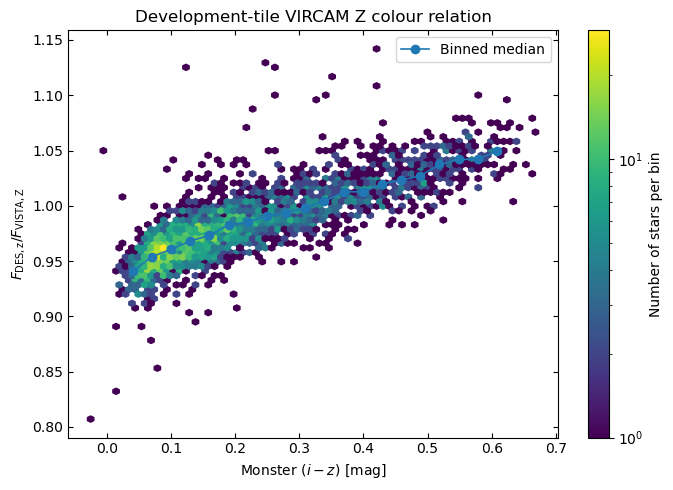

Saved: data/outputs/Monster_VIKING_Z/development_tile_z_colour_relation.pdf


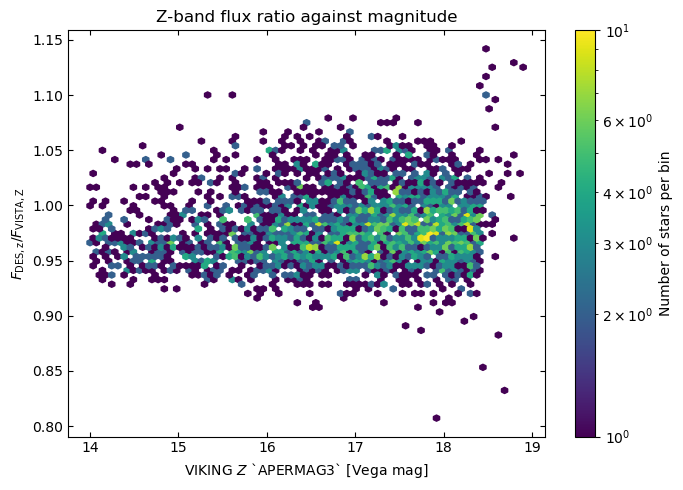

Saved: data/outputs/Monster_VIKING_Z/development_tile_z_ratio_vs_magnitude.pdf

Saved:
  data/outputs/Monster_VIKING_Z/development_tile_z_calibration_sample.ecsv
  data/outputs/Monster_VIKING_Z/development_tile_z_calibration_selection.csv

Prepared variables for the next step:
  z_calibration_sample          : provisional clean Z-band stellar sample
  selected_colour               : Monster (i-z) colour
  selected_ratio                : DES z / VISTA Z flux ratio
  diagnostic_colour_table       : first binned view of the colour relation


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table
from IPython.display import display


# -------------------------------------------------------------------
# Calibration configuration
# -------------------------------------------------------------------

VISTA_Z_AB_MINUS_VEGA = 0.502

CALIBRATION_MAX_SEPARATION_ARCSEC = 0.3
CALIBRATION_MIN_SNR = 50.0
CALIBRATION_MAX_ABS_CLASSSTAT = 3.0

CALIBRATION_MIN_Z_VEGA = 14.0
CALIBRATION_MAX_Z_VEGA = 20.0


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def as_float_array(column):
    """Convert an ordinary or masked table column to a float array."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(column, dtype=float),
            np.nan,
        ),
        dtype=float,
    )


def safe_snr(flux, flux_error):
    """Calculate flux/error where both quantities are valid."""
    flux = np.asarray(flux, dtype=float)
    flux_error = np.asarray(flux_error, dtype=float)

    result = np.full(
        len(flux),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(flux)
        & np.isfinite(flux_error)
        & (flux > 0.0)
        & (flux_error > 0.0)
    )

    result[valid] = (
        flux[valid]
        / flux_error[valid]
    )

    return result


def robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    centre = np.median(values)

    return float(
        1.4826
        * np.median(
            np.abs(values - centre)
        )
    )


# -------------------------------------------------------------------
# Start from the Gold-quality working table
# -------------------------------------------------------------------

z_candidates = gold_quality.copy()

separation_arcsec = as_float_array(
    z_candidates["separation_arcsec"]
)

viking_z_mag_vega = as_float_array(
    z_candidates["viking_z_apermag3_vega"]
)

viking_z_mag_error = as_float_array(
    z_candidates["viking_z_apermag3err"]
)

viking_z_flux_adu = as_float_array(
    z_candidates["viking_z_aperflux3_adu"]
)

viking_z_flux_error_adu = as_float_array(
    z_candidates["viking_z_aperflux3err_adu"]
)

monster_i_flux_njy = as_float_array(
    z_candidates["monster_DES_i_flux_nJy"]
)

monster_i_flux_error_njy = as_float_array(
    z_candidates["monster_DES_i_fluxErr_nJy"]
)

monster_z_flux_njy = as_float_array(
    z_candidates["monster_DES_z_flux_nJy"]
)

monster_z_flux_error_njy = as_float_array(
    z_candidates["monster_DES_z_fluxErr_nJy"]
)

viking_class = np.asarray(
    z_candidates["viking_class"],
    dtype=np.int64,
)

viking_classstat = as_float_array(
    z_candidates["viking_classstat"]
)

viking_pperrbits = np.asarray(
    z_candidates["viking_pperrbits"],
    dtype=np.int64,
)


# -------------------------------------------------------------------
# Convert the VIKING Vega magnitude to AB magnitude and nJy
# -------------------------------------------------------------------

viking_z_mag_ab = (
    viking_z_mag_vega
    + VISTA_Z_AB_MINUS_VEGA
)

viking_z_flux_njy = np.full(
    len(z_candidates),
    np.nan,
    dtype=float,
)

valid_viking_magnitude = (
    np.isfinite(viking_z_mag_ab)
)

viking_z_flux_njy[
    valid_viking_magnitude
] = 10.0 ** (
    (31.4 - viking_z_mag_ab[
        valid_viking_magnitude
    ])
    / 2.5
)


# Propagate the catalogue magnitude uncertainty into a flux error.
viking_z_flux_error_njy = np.full(
    len(z_candidates),
    np.nan,
    dtype=float,
)

valid_viking_flux_error = (
    valid_viking_magnitude
    & np.isfinite(viking_z_mag_error)
    & (viking_z_mag_error > 0.0)
)

viking_z_flux_error_njy[
    valid_viking_flux_error
] = (
    viking_z_flux_njy[
        valid_viking_flux_error
    ]
    * np.log(10.0)
    / 2.5
    * viking_z_mag_error[
        valid_viking_flux_error
    ]
)


# -------------------------------------------------------------------
# Calculate the three photometric S/N values
# -------------------------------------------------------------------

viking_z_snr = safe_snr(
    viking_z_flux_adu,
    viking_z_flux_error_adu,
)

monster_i_snr = safe_snr(
    monster_i_flux_njy,
    monster_i_flux_error_njy,
)

monster_z_snr = safe_snr(
    monster_z_flux_njy,
    monster_z_flux_error_njy,
)


# -------------------------------------------------------------------
# Calculate Monster colour and the measured Z-band flux ratio
# -------------------------------------------------------------------

monster_iz_colour = np.full(
    len(z_candidates),
    np.nan,
    dtype=float,
)

z_flux_ratio = np.full(
    len(z_candidates),
    np.nan,
    dtype=float,
)

valid_colour_fluxes = (
    np.isfinite(monster_i_flux_njy)
    & np.isfinite(monster_z_flux_njy)
    & (monster_i_flux_njy > 0.0)
    & (monster_z_flux_njy > 0.0)
)

monster_iz_colour[
    valid_colour_fluxes
] = (
    -2.5
    * np.log10(
        monster_i_flux_njy[
            valid_colour_fluxes
        ]
        / monster_z_flux_njy[
            valid_colour_fluxes
        ]
    )
)

valid_ratio_fluxes = (
    np.isfinite(monster_z_flux_njy)
    & np.isfinite(viking_z_flux_njy)
    & (monster_z_flux_njy > 0.0)
    & (viking_z_flux_njy > 0.0)
)

z_flux_ratio[
    valid_ratio_fluxes
] = (
    monster_z_flux_njy[
        valid_ratio_fluxes
    ]
    / viking_z_flux_njy[
        valid_ratio_fluxes
    ]
)


# -------------------------------------------------------------------
# Store all derived quantities
# -------------------------------------------------------------------

z_candidates["viking_z_mag_ab"] = (
    viking_z_mag_ab
)

z_candidates["viking_z_flux_nJy"] = (
    viking_z_flux_njy
)

z_candidates["viking_z_fluxErr_nJy"] = (
    viking_z_flux_error_njy
)

z_candidates["monster_iz_colour"] = (
    monster_iz_colour
)

z_candidates["monster_z_over_vista_z"] = (
    z_flux_ratio
)

z_candidates["viking_z_snr"] = (
    viking_z_snr
)

z_candidates["monster_i_snr"] = (
    monster_i_snr
)

z_candidates["monster_z_snr"] = (
    monster_z_snr
)


# -------------------------------------------------------------------
# Construct the staged calibration selection
# -------------------------------------------------------------------

finite_photometry = (
    np.isfinite(monster_iz_colour)
    & np.isfinite(z_flux_ratio)
    & (z_flux_ratio > 0.0)
)

secure_separation = (
    separation_arcsec
    < CALIBRATION_MAX_SEPARATION_ARCSEC
)

stellar_classification = (
    viking_class == -1
)

stable_classstat = (
    np.isfinite(viking_classstat)
    & (
        np.abs(viking_classstat)
        < CALIBRATION_MAX_ABS_CLASSSTAT
    )
)

high_snr_all_bands = (
    (viking_z_snr >= CALIBRATION_MIN_SNR)
    & (monster_i_snr >= CALIBRATION_MIN_SNR)
    & (monster_z_snr >= CALIBRATION_MIN_SNR)
)

clean_viking_flags = (
    viking_pperrbits == 0
)

safe_viking_magnitude = (
    np.isfinite(viking_z_mag_vega)
    & (
        viking_z_mag_vega
        > CALIBRATION_MIN_Z_VEGA
    )
    & (
        viking_z_mag_vega
        < CALIBRATION_MAX_Z_VEGA
    )
)


selection_steps = [
    (
        "Gold catalogue",
        np.ones(
            len(z_candidates),
            dtype=bool,
        ),
    ),
    (
        "Finite colour and flux ratio",
        finite_photometry,
    ),
    (
        "Separation < 0.3 arcsec",
        finite_photometry
        & secure_separation,
    ),
    (
        "VIKING CLASS = -1",
        finite_photometry
        & secure_separation
        & stellar_classification,
    ),
    (
        "|CLASSSTAT| < 3",
        finite_photometry
        & secure_separation
        & stellar_classification
        & stable_classstat,
    ),
    (
        "S/N >= 50 in all three bands",
        finite_photometry
        & secure_separation
        & stellar_classification
        & stable_classstat
        & high_snr_all_bands,
    ),
    (
        "PPERRBITS = 0",
        finite_photometry
        & secure_separation
        & stellar_classification
        & stable_classstat
        & high_snr_all_bands
        & clean_viking_flags,
    ),
    (
        "14 < VIKING Z(Vega) < 20",
        finite_photometry
        & secure_separation
        & stellar_classification
        & stable_classstat
        & high_snr_all_bands
        & clean_viking_flags
        & safe_viking_magnitude,
    ),
]


selection_summary_records = []

for stage_name, stage_mask in selection_steps:
    selection_summary_records.append(
        {
            "stage": stage_name,
            "number_remaining": int(
                np.count_nonzero(stage_mask)
            ),
            "fraction_of_gold_catalogue": float(
                np.mean(stage_mask)
            ),
        }
    )

z_calibration_selection_summary = pd.DataFrame(
    selection_summary_records
)

display(z_calibration_selection_summary)


# -------------------------------------------------------------------
# Final provisional development-tile calibration mask
# -------------------------------------------------------------------

z_calibration_mask = (
    finite_photometry
    & secure_separation
    & stellar_classification
    & stable_classstat
    & high_snr_all_bands
    & clean_viking_flags
    & safe_viking_magnitude
)

z_calibration_sample = z_candidates[
    z_calibration_mask
].copy()

z_calibration_sample[
    "calibration_sample"
] = np.ones(
    len(z_calibration_sample),
    dtype=bool,
)


if len(z_calibration_sample) == 0:
    raise RuntimeError(
        "The provisional calibration selection contains no sources."
    )


# -------------------------------------------------------------------
# Print summary statistics
# -------------------------------------------------------------------

selected_colour = as_float_array(
    z_calibration_sample["monster_iz_colour"]
)

selected_ratio = as_float_array(
    z_calibration_sample["monster_z_over_vista_z"]
)

selected_viking_mag = as_float_array(
    z_calibration_sample["viking_z_apermag3_vega"]
)


print("\n" + "=" * 72)
print("PROVISIONAL Z-BAND CALIBRATION SAMPLE")
print("=" * 72)

print(
    f"Selected stars                  : "
    f"{len(z_calibration_sample):,}"
)

print(
    f"Monster (i-z) range             : "
    f"{np.min(selected_colour):.4f} to "
    f"{np.max(selected_colour):.4f} mag"
)

print(
    f"Monster (i-z) 1st--99th pct.    : "
    f"{np.percentile(selected_colour, 1):.4f} to "
    f"{np.percentile(selected_colour, 99):.4f} mag"
)

print(
    f"Median DES_z / VISTA_Z ratio    : "
    f"{np.median(selected_ratio):.6f}"
)

print(
    f"NMAD DES_z / VISTA_Z ratio      : "
    f"{robust_nmad(selected_ratio):.6f}"
)

print(
    f"VIKING Z(Vega) range            : "
    f"{np.min(selected_viking_mag):.3f} to "
    f"{np.max(selected_viking_mag):.3f}"
)


# -------------------------------------------------------------------
# Binned medians for a first view of the colour relation
# -------------------------------------------------------------------

colour_low = float(
    np.percentile(
        selected_colour,
        0.5,
    )
)

colour_high = float(
    np.percentile(
        selected_colour,
        99.5,
    )
)

diagnostic_colour_edges = np.linspace(
    colour_low,
    colour_high,
    21,
)

diagnostic_colour_centres = 0.5 * (
    diagnostic_colour_edges[:-1]
    + diagnostic_colour_edges[1:]
)

diagnostic_median_ratio = np.full(
    len(diagnostic_colour_centres),
    np.nan,
)

diagnostic_ratio_nmad = np.full(
    len(diagnostic_colour_centres),
    np.nan,
)

diagnostic_number = np.zeros(
    len(diagnostic_colour_centres),
    dtype=int,
)

for index in range(
    len(diagnostic_colour_centres)
):
    in_bin = (
        selected_colour
        >= diagnostic_colour_edges[index]
    ) & (
        selected_colour
        < diagnostic_colour_edges[index + 1]
    )

    diagnostic_number[index] = int(
        np.count_nonzero(in_bin)
    )

    if diagnostic_number[index] >= 20:
        diagnostic_median_ratio[index] = float(
            np.median(
                selected_ratio[in_bin]
            )
        )

        diagnostic_ratio_nmad[index] = (
            robust_nmad(
                selected_ratio[in_bin]
            )
        )


diagnostic_colour_table = pd.DataFrame(
    {
        "colour_centre": diagnostic_colour_centres,
        "number_of_stars": diagnostic_number,
        "median_ratio": diagnostic_median_ratio,
        "ratio_nmad": diagnostic_ratio_nmad,
    }
)

print("\nDiagnostic colour bins:")
display(diagnostic_colour_table)


# -------------------------------------------------------------------
# Plot 1: raw colour-term relation
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 5),
)

hexbin = ax.hexbin(
    selected_colour,
    selected_ratio,
    gridsize=70,
    mincnt=1,
    bins="log",
)

valid_binned_median = np.isfinite(
    diagnostic_median_ratio
)

ax.plot(
    diagnostic_colour_centres[
        valid_binned_median
    ],
    diagnostic_median_ratio[
        valid_binned_median
    ],
    marker="o",
    linewidth=1.2,
    label="Binned median",
)

ax.set_xlabel(
    r"Monster $(i-z)$ [mag]"
)

ax.set_ylabel(
    r"$F_{\rm DES,z}/F_{\rm VISTA,Z}$"
)

ax.set_title(
    "Development-tile VIRCAM Z colour relation"
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of stars per bin"
)

fig.tight_layout()

colour_relation_path = (
    OUTPUT_DIR
    / "development_tile_z_colour_relation.pdf"
)

fig.savefig(
    colour_relation_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {colour_relation_path}")


# -------------------------------------------------------------------
# Plot 2: flux ratio against VIKING magnitude
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 5),
)

hexbin = ax.hexbin(
    selected_viking_mag,
    selected_ratio,
    gridsize=70,
    mincnt=1,
    bins="log",
)

ax.set_xlabel(
    r"VIKING $Z$ `APERMAG3` [Vega mag]"
)

ax.set_ylabel(
    r"$F_{\rm DES,z}/F_{\rm VISTA,Z}$"
)

ax.set_title(
    "Z-band flux ratio against magnitude"
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of stars per bin"
)

fig.tight_layout()

ratio_magnitude_path = (
    OUTPUT_DIR
    / "development_tile_z_ratio_vs_magnitude.pdf"
)

fig.savefig(
    ratio_magnitude_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {ratio_magnitude_path}")


# -------------------------------------------------------------------
# Save the provisional development-tile sample
# -------------------------------------------------------------------

z_calibration_sample_path = (
    OUTPUT_DIR
    / "development_tile_z_calibration_sample.ecsv"
)

z_calibration_sample.write(
    z_calibration_sample_path,
    format="ascii.ecsv",
    overwrite=True,
)

selection_summary_path = (
    OUTPUT_DIR
    / "development_tile_z_calibration_selection.csv"
)

z_calibration_selection_summary.to_csv(
    selection_summary_path,
    index=False,
)

print("\nSaved:")
print(f"  {z_calibration_sample_path}")
print(f"  {selection_summary_path}")


print("\nPrepared variables for the next step:")
print(
    "  z_calibration_sample          : "
    "provisional clean Z-band stellar sample"
)

print(
    "  selected_colour               : "
    "Monster (i-z) colour"
)

print(
    "  selected_ratio                : "
    "DES z / VISTA Z flux ratio"
)

print(
    "  diagnostic_colour_table       : "
    "first binned view of the colour relation"
)

### Result

The conservative photometric selection leaves 2,918 calibration stars from
this development tile. The selected sample spans
$$
-0.025 < (i-z)_{\mathrm{Monster}} < 0.668,
$$
with 98 per cent of the
sources between 0.035 and 0.599 mag.

The median flux ratio is
$$
F_{\mathrm{DES},z}/F_{\mathrm{VISTA},Z}=0.978,
$$
with an NMAD of 0.031.
A clear, smooth colour dependence is visible: the median ratio increases
from approximately 0.94 for the bluest stars to approximately 1.05 near
(i-z)=0.6. No discontinuity or separate population is apparent.

The raw ratio shows only a weak dependence on magnitude. This cannot yet be
interpreted as a photometric bias because stellar colour and magnitude are
correlated; the magnitude dependence must be examined after subtracting the
colour model.

## 9. Test the spline method on an independent validation sample

Before processing all 88 VIKING catalogues, I test the spline methodology
using the development tile. The provisional calibration stars are divided
deterministically into a fitting sample and an independent validation sample
using their Monster source identifiers. Eighty per cent of the stars are
used to derive the colour relation, while the remaining 20 per cent are used
only for validation.

For this development test, candidate spline nodes are placed uniformly over

$$
0.0 \leq (i-z)_{\mathrm{Monster}} \leq 0.6.
$$

This interval contains approximately 98 per cent of the selected stars in the
development tile. The final node range will be reconsidered after combining
all 88 VIKING catalogues.

Within the colour bin associated with each node, the flux ratios are
iteratively clipped around their median using the normalized median absolute
deviation. A minimum of 30 fitting stars is required at every node. A cubic
spline is then passed through the robust node medians.

For each validation star, the residual is defined as

$$
\Delta R_Z
=
\left(
\frac{F_{\mathrm{DES},z}}
     {F_{\mathrm{VISTA},Z}}
\right)_{\mathrm{measured}}
-
R_Z\!\left[(i-z)_{\mathrm{Monster}}\right].
$$

A successful transformation should produce residuals centred near zero,
without a significant remaining dependence on colour or magnitude. This cell
does not write the final YAML file; it only verifies the fitting procedure.

PRELIMINARY SPLINE SAMPLE
All provisional calibration stars : 2,918
Stars inside node range            : 2,887
Fitting stars                      : 2,335
Independent validation stars       : 552
Stars outside preliminary range    : 31

Robust preliminary spline nodes
-------------------------------


,node_colour,bin_lower_edge,bin_upper_edge,number_before_clipping,number_after_clipping,median_ratio,ratio_nmad,median_uncertainty
0,0.000,-0.0375,0.0375,32,30,0.942098,0.017584,0.004024
1,0.075,0.0375,0.1125,683,681,0.954720,0.015345,0.000737
2,0.150,0.1125,0.1875,583,570,0.971473,0.016930,0.000889
3,0.225,0.1875,0.2625,352,342,0.985387,0.014393,0.000975
4,0.300,0.2625,0.3375,238,234,0.997173,0.016677,0.001366
5,0.375,0.3375,0.4125,179,177,1.011900,0.017876,0.001684
6,0.450,0.4125,0.4875,126,124,1.023063,0.018516,0.002084
7,0.525,0.4875,0.5625,107,107,1.034915,0.017612,0.002134
8,0.600,0.5625,0.6375,35,32,1.041623,0.010196,0.002259



Residual summary
----------------


,sample,number_of_stars,median_residual,residual_nmad,residual_std,p16,p84
0,Fitting,2335,0.000081,0.015515,0.018279,-0.014795,0.016407
1,Validation,552,0.001345,0.015741,0.019342,-0.014776,0.016934



Independent-validation diagnostics
----------------------------------
Median residual                  : +0.001345
Residual NMAD                    : 0.015741
Fractional residual NMAD         : 1.623 per cent
Residual--colour Spearman rho    : +0.0595
Residual--colour p-value         : 1.626e-01
Residual--magnitude Spearman rho : +0.0945
Residual--magnitude p-value      : 2.638e-02


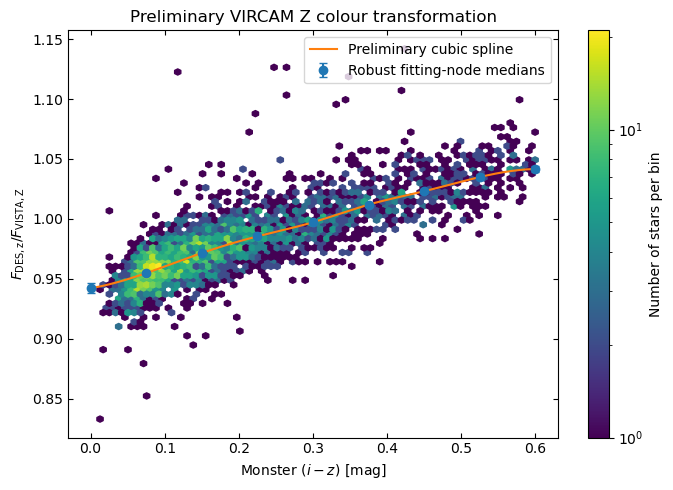

Saved: data/outputs/Monster_VIKING_Z/development_tile_z_preliminary_spline.pdf


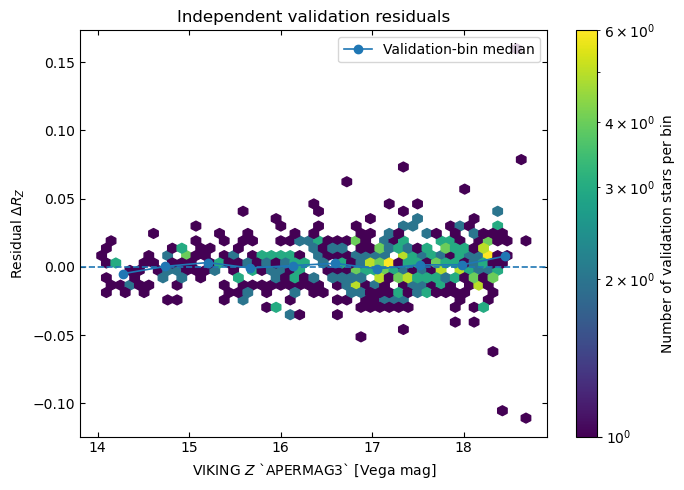

Saved: data/outputs/Monster_VIKING_Z/development_tile_z_validation_residuals.pdf

Saved:
  data/outputs/Monster_VIKING_Z/development_tile_z_preliminary_nodes.csv
  data/outputs/Monster_VIKING_Z/development_tile_z_validation_residuals.csv

Prepared variables for the next step:
  preliminary_spline          : development-tile cubic spline
  node_table                  : robust node measurements
  residual_summary            : fitting and validation statistics
  validation_residual         : independent validation residuals


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import make_interp_spline
from scipy.stats import spearmanr
from IPython.display import display


# -------------------------------------------------------------------
# Preliminary spline configuration
# -------------------------------------------------------------------

PRELIMINARY_NODES = np.linspace(
    0.0,
    0.6,
    9,
)

MINIMUM_STARS_PER_NODE = 30
SIGMA_CLIP_THRESHOLD = 3.0
MAXIMUM_CLIP_ITERATIONS = 10

# A deterministic source-ID split gives approximately 80 per cent
# fitting stars and 20 per cent independent validation stars.
VALIDATION_MODULUS = 5
VALIDATION_REMAINDER = 0


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def to_float_array(column):
    """Convert an ordinary or masked column into a float array."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(column, dtype=float),
            np.nan,
        ),
        dtype=float,
    )


def calculate_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    centre = np.median(values)

    return float(
        1.4826
        * np.median(
            np.abs(values - centre)
        )
    )


def iteratively_clip_ratios(
    values,
    threshold=SIGMA_CLIP_THRESHOLD,
    maximum_iterations=MAXIMUM_CLIP_ITERATIONS,
):
    """
    Iteratively clip a one-dimensional distribution around its
    median using the NMAD as a robust estimate of scatter.
    """
    values = np.asarray(values, dtype=float)

    finite = np.isfinite(values)
    clipped_values = values[finite]

    if len(clipped_values) == 0:
        return clipped_values

    for _ in range(maximum_iterations):
        centre = np.median(clipped_values)
        scatter = calculate_nmad(clipped_values)

        if (
            not np.isfinite(scatter)
            or scatter <= 0.0
        ):
            break

        keep = (
            np.abs(clipped_values - centre)
            <= threshold * scatter
        )

        if np.all(keep):
            break

        clipped_values = clipped_values[keep]

        if len(clipped_values) < 3:
            break

    return clipped_values


def summarise_residuals(label, residuals):
    """Return robust residual statistics for one sample."""
    residuals = np.asarray(residuals, dtype=float)
    residuals = residuals[np.isfinite(residuals)]

    return {
        "sample": label,
        "number_of_stars": len(residuals),
        "median_residual": float(
            np.median(residuals)
        ),
        "residual_nmad": calculate_nmad(
            residuals
        ),
        "residual_std": float(
            np.std(residuals)
        ),
        "p16": float(
            np.percentile(residuals, 16)
        ),
        "p84": float(
            np.percentile(residuals, 84)
        ),
    }


# -------------------------------------------------------------------
# Read the development-tile calibration quantities
# -------------------------------------------------------------------

spline_colour = to_float_array(
    z_calibration_sample["monster_iz_colour"]
)

spline_ratio = to_float_array(
    z_calibration_sample["monster_z_over_vista_z"]
)

spline_viking_magnitude = to_float_array(
    z_calibration_sample["viking_z_apermag3_vega"]
)

spline_monster_id = np.asarray(
    z_calibration_sample["monster_id"],
    dtype=np.int64,
)


valid_input = (
    np.isfinite(spline_colour)
    & np.isfinite(spline_ratio)
    & np.isfinite(spline_viking_magnitude)
    & (spline_ratio > 0.0)
)

spline_colour = spline_colour[valid_input]
spline_ratio = spline_ratio[valid_input]
spline_viking_magnitude = (
    spline_viking_magnitude[valid_input]
)
spline_monster_id = spline_monster_id[valid_input]


# -------------------------------------------------------------------
# Define fitting and validation subsets
# -------------------------------------------------------------------

validation_sample = (
    np.mod(
        spline_monster_id,
        VALIDATION_MODULUS,
    )
    == VALIDATION_REMAINDER
)

fitting_sample = ~validation_sample


# The spline is evaluated only inside the node interval.
inside_node_range = (
    spline_colour >= PRELIMINARY_NODES[0]
) & (
    spline_colour <= PRELIMINARY_NODES[-1]
)

fitting_sample &= inside_node_range
validation_sample &= inside_node_range


print("=" * 72)
print("PRELIMINARY SPLINE SAMPLE")
print("=" * 72)

print(
    f"All provisional calibration stars : "
    f"{len(spline_colour):,}"
)

print(
    f"Stars inside node range            : "
    f"{np.count_nonzero(inside_node_range):,}"
)

print(
    f"Fitting stars                      : "
    f"{np.count_nonzero(fitting_sample):,}"
)

print(
    f"Independent validation stars       : "
    f"{np.count_nonzero(validation_sample):,}"
)

print(
    f"Stars outside preliminary range    : "
    f"{np.count_nonzero(~inside_node_range):,}"
)


# -------------------------------------------------------------------
# Construct bins centred on the spline nodes
# -------------------------------------------------------------------

node_midpoints = 0.5 * (
    PRELIMINARY_NODES[:-1]
    + PRELIMINARY_NODES[1:]
)

first_edge = (
    PRELIMINARY_NODES[0]
    - (
        node_midpoints[0]
        - PRELIMINARY_NODES[0]
    )
)

last_edge = (
    PRELIMINARY_NODES[-1]
    + (
        PRELIMINARY_NODES[-1]
        - node_midpoints[-1]
    )
)

node_edges = np.concatenate(
    [
        [first_edge],
        node_midpoints,
        [last_edge],
    ]
)


# -------------------------------------------------------------------
# Derive robust node values using fitting stars only
# -------------------------------------------------------------------

node_values = np.full(
    len(PRELIMINARY_NODES),
    np.nan,
    dtype=float,
)

node_scatter = np.full(
    len(PRELIMINARY_NODES),
    np.nan,
    dtype=float,
)

node_uncertainty = np.full(
    len(PRELIMINARY_NODES),
    np.nan,
    dtype=float,
)

node_number_initial = np.zeros(
    len(PRELIMINARY_NODES),
    dtype=int,
)

node_number_clipped = np.zeros(
    len(PRELIMINARY_NODES),
    dtype=int,
)


for node_index in range(
    len(PRELIMINARY_NODES)
):
    in_node_bin = (
        fitting_sample
        & (
            spline_colour
            >= node_edges[node_index]
        )
        & (
            spline_colour
            < node_edges[node_index + 1]
        )
    )

    # Include the upper boundary in the final bin.
    if node_index == len(PRELIMINARY_NODES) - 1:
        in_node_bin = (
            fitting_sample
            & (
                spline_colour
                >= node_edges[node_index]
            )
            & (
                spline_colour
                <= node_edges[node_index + 1]
            )
        )

    ratios_in_bin = spline_ratio[
        in_node_bin
    ]

    node_number_initial[node_index] = (
        len(ratios_in_bin)
    )

    clipped_ratios = iteratively_clip_ratios(
        ratios_in_bin
    )

    node_number_clipped[node_index] = (
        len(clipped_ratios)
    )

    if (
        len(clipped_ratios)
        < MINIMUM_STARS_PER_NODE
    ):
        continue

    node_values[node_index] = float(
        np.median(clipped_ratios)
    )

    node_scatter[node_index] = (
        calculate_nmad(clipped_ratios)
    )

    # Approximate uncertainty of a sample median for a nearly
    # Gaussian distribution.
    node_uncertainty[node_index] = (
        1.2533
        * node_scatter[node_index]
        / np.sqrt(len(clipped_ratios))
    )


node_table = pd.DataFrame(
    {
        "node_colour": PRELIMINARY_NODES,
        "bin_lower_edge": node_edges[:-1],
        "bin_upper_edge": node_edges[1:],
        "number_before_clipping":
            node_number_initial,
        "number_after_clipping":
            node_number_clipped,
        "median_ratio": node_values,
        "ratio_nmad": node_scatter,
        "median_uncertainty":
            node_uncertainty,
    }
)


print("\nRobust preliminary spline nodes")
print("-------------------------------")

display(node_table)


unsupported_nodes = (
    ~np.isfinite(node_values)
)

if np.any(unsupported_nodes):
    unsupported_colours = (
        PRELIMINARY_NODES[
            unsupported_nodes
        ]
    )

    raise RuntimeError(
        "The following preliminary nodes have fewer than "
        f"{MINIMUM_STARS_PER_NODE} accepted fitting stars: "
        f"{unsupported_colours}"
    )


# -------------------------------------------------------------------
# Fit the cubic spline
# -------------------------------------------------------------------

preliminary_spline = make_interp_spline(
    PRELIMINARY_NODES,
    node_values,
    k=3,
)

smooth_colour_grid = np.linspace(
    PRELIMINARY_NODES[0],
    PRELIMINARY_NODES[-1],
    500,
)

smooth_ratio_model = preliminary_spline(
    smooth_colour_grid
)


# -------------------------------------------------------------------
# Evaluate the spline for all fitting and validation stars
# -------------------------------------------------------------------

ratio_model = np.full(
    len(spline_colour),
    np.nan,
    dtype=float,
)

ratio_model[inside_node_range] = (
    preliminary_spline(
        spline_colour[
            inside_node_range
        ]
    )
)

ratio_residual = (
    spline_ratio
    - ratio_model
)

fractional_residual = np.full(
    len(spline_ratio),
    np.nan,
    dtype=float,
)

valid_model = (
    np.isfinite(ratio_model)
    & (ratio_model > 0.0)
)

fractional_residual[valid_model] = (
    ratio_residual[valid_model]
    / ratio_model[valid_model]
)


# -------------------------------------------------------------------
# Residual summaries
# -------------------------------------------------------------------

residual_summary = pd.DataFrame(
    [
        summarise_residuals(
            "Fitting",
            ratio_residual[fitting_sample],
        ),
        summarise_residuals(
            "Validation",
            ratio_residual[validation_sample],
        ),
    ]
)


print("\nResidual summary")
print("----------------")

display(residual_summary)


validation_residual = ratio_residual[
    validation_sample
]

validation_fractional_residual = (
    fractional_residual[
        validation_sample
    ]
)

validation_colour = spline_colour[
    validation_sample
]

validation_magnitude = (
    spline_viking_magnitude[
        validation_sample
    ]
)


colour_correlation = spearmanr(
    validation_colour,
    validation_residual,
)

magnitude_correlation = spearmanr(
    validation_magnitude,
    validation_residual,
)


print("\nIndependent-validation diagnostics")
print("----------------------------------")

print(
    f"Median residual                  : "
    f"{np.median(validation_residual):+.6f}"
)

print(
    f"Residual NMAD                    : "
    f"{calculate_nmad(validation_residual):.6f}"
)

print(
    f"Fractional residual NMAD         : "
    f"{100.0 * calculate_nmad(validation_fractional_residual):.3f} per cent"
)

print(
    f"Residual--colour Spearman rho    : "
    f"{colour_correlation.statistic:+.4f}"
)

print(
    f"Residual--colour p-value         : "
    f"{colour_correlation.pvalue:.3e}"
)

print(
    f"Residual--magnitude Spearman rho : "
    f"{magnitude_correlation.statistic:+.4f}"
)

print(
    f"Residual--magnitude p-value      : "
    f"{magnitude_correlation.pvalue:.3e}"
)


# -------------------------------------------------------------------
# Plot 1: preliminary colour relation and fitted spline
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 5),
)

hexbin = ax.hexbin(
    spline_colour[inside_node_range],
    spline_ratio[inside_node_range],
    gridsize=70,
    mincnt=1,
    bins="log",
)

ax.errorbar(
    PRELIMINARY_NODES,
    node_values,
    yerr=node_uncertainty,
    fmt="o",
    capsize=3,
    label="Robust fitting-node medians",
)

ax.plot(
    smooth_colour_grid,
    smooth_ratio_model,
    linewidth=1.5,
    label="Preliminary cubic spline",
)

ax.set_xlabel(
    r"Monster $(i-z)$ [mag]"
)

ax.set_ylabel(
    r"$F_{\rm DES,z}/F_{\rm VISTA,Z}$"
)

ax.set_title(
    "Preliminary VIRCAM Z colour transformation"
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of stars per bin"
)

fig.tight_layout()

preliminary_spline_plot_path = (
    OUTPUT_DIR
    / "development_tile_z_preliminary_spline.pdf"
)

fig.savefig(
    preliminary_spline_plot_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {preliminary_spline_plot_path}"
)


# -------------------------------------------------------------------
# Plot 2: independent validation residuals
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 5),
)

hexbin = ax.hexbin(
    validation_magnitude,
    validation_residual,
    gridsize=45,
    mincnt=1,
    bins="log",
)

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.2,
)

# Robust binned medians versus magnitude
magnitude_edges = np.linspace(
    np.min(validation_magnitude),
    np.max(validation_magnitude),
    11,
)

magnitude_centres = 0.5 * (
    magnitude_edges[:-1]
    + magnitude_edges[1:]
)

median_residual_by_magnitude = np.full(
    len(magnitude_centres),
    np.nan,
)

for bin_index in range(
    len(magnitude_centres)
):
    in_magnitude_bin = (
        validation_magnitude
        >= magnitude_edges[bin_index]
    ) & (
        validation_magnitude
        < magnitude_edges[bin_index + 1]
    )

    if bin_index == len(magnitude_centres) - 1:
        in_magnitude_bin = (
            validation_magnitude
            >= magnitude_edges[bin_index]
        ) & (
            validation_magnitude
            <= magnitude_edges[bin_index + 1]
        )

    if np.count_nonzero(in_magnitude_bin) >= 15:
        median_residual_by_magnitude[
            bin_index
        ] = np.median(
            validation_residual[
                in_magnitude_bin
            ]
        )


valid_magnitude_medians = np.isfinite(
    median_residual_by_magnitude
)

ax.plot(
    magnitude_centres[
        valid_magnitude_medians
    ],
    median_residual_by_magnitude[
        valid_magnitude_medians
    ],
    marker="o",
    linewidth=1.2,
    label="Validation-bin median",
)

ax.set_xlabel(
    r"VIKING $Z$ `APERMAG3` [Vega mag]"
)

ax.set_ylabel(
    r"Residual $\Delta R_Z$"
)

ax.set_title(
    "Independent validation residuals"
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of validation stars per bin"
)

fig.tight_layout()

validation_plot_path = (
    OUTPUT_DIR
    / "development_tile_z_validation_residuals.pdf"
)

fig.savefig(
    validation_plot_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {validation_plot_path}"
)


# -------------------------------------------------------------------
# Save the preliminary node and residual tables
# -------------------------------------------------------------------

node_table_path = (
    OUTPUT_DIR
    / "development_tile_z_preliminary_nodes.csv"
)

node_table.to_csv(
    node_table_path,
    index=False,
)

validation_output = pd.DataFrame(
    {
        "monster_id":
            spline_monster_id[validation_sample],
        "monster_iz_colour":
            validation_colour,
        "viking_z_mag_vega":
            validation_magnitude,
        "measured_ratio":
            spline_ratio[validation_sample],
        "model_ratio":
            ratio_model[validation_sample],
        "ratio_residual":
            validation_residual,
        "fractional_residual":
            validation_fractional_residual,
    }
)

validation_output_path = (
    OUTPUT_DIR
    / "development_tile_z_validation_residuals.csv"
)

validation_output.to_csv(
    validation_output_path,
    index=False,
)


print("\nSaved:")
print(f"  {node_table_path}")
print(f"  {validation_output_path}")


print("\nPrepared variables for the next step:")
print(
    "  preliminary_spline          : "
    "development-tile cubic spline"
)

print(
    "  node_table                  : "
    "robust node measurements"
)

print(
    "  residual_summary            : "
    "fitting and validation statistics"
)

print(
    "  validation_residual         : "
    "independent validation residuals"
)

### Result

The preliminary cubic spline follows the Z-band stellar colour relation
smoothly over 
$$
0.0 \leq (i-z)_{\mathrm{Monster}} \leq 0.6.
$$
The independent
validation sample contains 552 stars and has a median residual of +0.0013,
a residual NMAD of 0.0157, and a fractional NMAD of approximately
1.62\%.

No significant residual dependence on colour is detected. A weak dependence
on VIKING magnitude remains, particularly near the faint end, and will be
reassessed using the complete 88-tile sample. The edge nodes are less strongly
constrained than the central nodes, so the final colour range and node
locations will be selected only after combining all tiles.

## 10. Construct the combined Z-band calibration sample

The development-tile analysis confirms that the adopted astrometric matching,
photometric selection, and spline methodology produce a clean VIRCAM
Z-band colour relation. I now apply the same procedure to all 88
available VIKING DR4 Z-band catalogues.

Each tile is processed independently because it has its own observing epoch
and astrometric residuals. For every tile, the workflow is:

1. read the VIKING catalogue and determine its median source-level MJD;
2. combine and deduplicate its overlapping Monster HTM7 shards;
3. propagate Monster positions to the recorded VIKING observing epoch;
4. require a Monster second-neighbour distance greater than 1'';
5. retain mutual nearest-neighbour matches within 0.5'';
6. apply the photometric-calibration separation requirement of 0.3'';
7. require VIKING stellar classification, clean flags,
 CLASSSTAT<3, and S/N > 50 in VIKING Z and Monster DES i,z;
9. restrict the VIKING magnitude to 14<Z_Vega<20;
10. calculate the Monster (i-z) colour and
   F_{DES},z/F_{VISTA},Z ratio.

The VIKING `PPERRBITS` column requires special handling because clean values
of zero can be represented as masked integers when the FITS table is read.
The underlying zero values are therefore preserved before applying the
`PPERRBITS = 0` requirement.

Neighbouring VIKING tiles can contain repeated measurements of the same
Monster source. The complete observation-level table is retained for
diagnosing tile-to-tile variations. A second table contains one measurement
per Monster source; for duplicated sources, the measurement with the highest
VIKING aperture-flux S/N is selected, with angular separation used as a
secondary criterion.

No restriction on Monster colour is imposed in this cell. The final supported
colour range and spline-node positions will be determined from the combined
sample.

In [12]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning
import astropy.units as u

from IPython.display import display


# -------------------------------------------------------------------
# Full-sample configuration
# -------------------------------------------------------------------

VIKING_DIR = Path("data/VIKING/z_band/viking")
MONSTER_ROOT = Path("data/VIKING/z_band/monster")

OUTPUT_DIR = Path("data/outputs/Monster_VIKING_Z")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Native CASU VISTA Z -> true Vega -> AB:
# Z_true_Vega = Z_native - 0.004
# Z_AB - Z_true_Vega = 0.502
VISTA_Z_AB_MINUS_NATIVE = 0.498

GOLD_MATCH_RADIUS = 0.5 * u.arcsec
CALIBRATION_MATCH_RADIUS_ARCSEC = 0.3
MONSTER_ISOLATION_RADIUS = 1.0 * u.arcsec

MINIMUM_SNR = 50.0
MAXIMUM_ABS_CLASSSTAT = 3.0

MINIMUM_Z_VEGA = 14.0
MAXIMUM_Z_VEGA = 20.0


viking_z_files = sorted(
    VIKING_DIR.glob("*.fits")
)

if not viking_z_files:
    raise FileNotFoundError(
        f"No VIKING Z catalogues were found in {VIKING_DIR}"
    )

print(
    f"Found {len(viking_z_files)} VIKING Z catalogues."
)


# -------------------------------------------------------------------
# General helper functions
# -------------------------------------------------------------------

def float_array(column):
    """Convert an ordinary or masked numerical column to float."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column,
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


def integer_array(column, fill_value=-1):
    """Convert an ordinary or masked integer column to int64."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(column),
            fill_value,
        ),
        dtype=np.int64,
    )


def pperrbits_array(column):
    """
    Read VIKING PPERRBITS while preserving underlying clean zeros.

    In these FITS catalogues, Astropy can represent raw PPERRBITS=0
    entries as masked values because of the FITS null-value metadata.
    The underlying zero values must therefore be retained rather than
    replaced by a nonzero fill value.
    """
    masked_column = np.ma.asarray(column)

    raw_values = np.asarray(
        np.ma.getdata(masked_column),
        dtype=np.int64,
    )

    mask = np.ma.getmaskarray(
        masked_column
    )

    if np.any(mask):
        masked_raw_values = raw_values[
            mask
        ]

        if not np.all(
            masked_raw_values == 0
        ):
            raise ValueError(
                "Masked PPERRBITS entries contain nonzero raw values."
            )

    return raw_values


def robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return np.nan

    centre = np.median(values)

    return float(
        1.4826
        * np.median(
            np.abs(values - centre)
        )
    )


def safe_snr(flux, flux_error):
    """Calculate flux/error where both measurements are valid."""
    flux = np.asarray(
        flux,
        dtype=float,
    )

    flux_error = np.asarray(
        flux_error,
        dtype=float,
    )

    result = np.full(
        len(flux),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(flux)
        & np.isfinite(flux_error)
        & (flux > 0.0)
        & (flux_error > 0.0)
    )

    result[valid] = (
        flux[valid]
        / flux_error[valid]
    )

    return result


def read_table_safely(path):
    """Read a FITS table while suppressing non-standard-unit warnings."""
    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            AstropyWarning,
        )

        return Table.read(path)


# -------------------------------------------------------------------
# Process one VIKING tile
# -------------------------------------------------------------------

def process_viking_z_tile(viking_path):
    """
    Construct selected Z-band calibration stars for one VIKING tile.

    Parameters
    ----------
    viking_path : pathlib.Path
        Path to one VIKING Z-band catalogue.

    Returns
    -------
    selected : astropy.table.Table
        Sources passing the complete astrometric and photometric
        calibration selection.

    summary : dict
        Per-tile processing and quality-control statistics.
    """

    monster_directory = (
        MONSTER_ROOT
        / viking_path.stem
    )

    monster_paths = sorted(
        monster_directory.glob(
            "*.fits"
        )
    )

    if not monster_paths:
        raise FileNotFoundError(
            "No Monster shards found for "
            f"{viking_path.name}"
        )


    # ---------------------------------------------------------------
    # Read the VIKING catalogue
    # ---------------------------------------------------------------

    viking_tile = read_table_safely(
        viking_path
    )

    required_viking_columns = [
        "RA",
        "DEC",
        "MJD",
        "APERFLUX3",
        "APERFLUX3ERR",
        "APERMAG3",
        "APERMAG3ERR",
        "CLASS",
        "CLASSSTAT",
        "PPERRBITS",
    ]

    missing_viking_columns = [
        name
        for name in required_viking_columns
        if name not in viking_tile.colnames
    ]

    if missing_viking_columns:
        raise KeyError(
            f"{viking_path.name} is missing columns: "
            f"{missing_viking_columns}"
        )


    # ---------------------------------------------------------------
    # Determine the recorded observing epoch
    # ---------------------------------------------------------------

    source_mjd_utc = float_array(
        viking_tile["MJD"]
    )

    finite_source_mjd = source_mjd_utc[
        np.isfinite(source_mjd_utc)
    ]

    if len(finite_source_mjd) == 0:
        raise ValueError(
            f"{viking_path.name} contains no finite MJD values."
        )

    tile_mjd_utc = float(
        np.median(
            finite_source_mjd
        )
    )

    tile_time_utc = Time(
        tile_mjd_utc,
        format="mjd",
        scale="utc",
    )

    tile_mjd_tai = float(
        tile_time_utc.tai.mjd
    )

    tile_epoch_jyear = float(
        tile_time_utc.jyear
    )


    # ---------------------------------------------------------------
    # Prepare native VIKING coordinates
    # ---------------------------------------------------------------

    viking_ra_deg = float_array(
        viking_tile["RA"]
    )

    viking_dec_deg = float_array(
        viking_tile["DEC"]
    )

    valid_viking_coordinates = (
        np.isfinite(viking_ra_deg)
        & np.isfinite(viking_dec_deg)
        & (viking_ra_deg >= 0.0)
        & (viking_ra_deg <= 360.0)
        & (viking_dec_deg >= -90.0)
        & (viking_dec_deg <= 90.0)
    )

    viking_original_indices = np.flatnonzero(
        valid_viking_coordinates
    )

    viking_coordinates = SkyCoord(
        ra=viking_ra_deg[
            valid_viking_coordinates
        ] * u.deg,

        dec=viking_dec_deg[
            valid_viking_coordinates
        ] * u.deg,

        frame="icrs",
    )

    if len(viking_coordinates) == 0:
        raise ValueError(
            f"{viking_path.name} contains no valid coordinates."
        )

    median_tile_dec = float(
        np.nanmedian(
            viking_dec_deg[
                valid_viking_coordinates
            ]
        )
    )

    region = (
        "southern"
        if median_tile_dec < -20.0
        else "northern_equatorial"
    )


    # ---------------------------------------------------------------
    # Load, combine, and deduplicate Monster shards
    # ---------------------------------------------------------------

    monster_columns = [
        "id",
        "coord_ra",
        "coord_dec",
        "epoch",
        "pm_ra",
        "pm_dec",
        "monster_DES_i_flux",
        "monster_DES_i_fluxErr",
        "monster_DES_z_flux",
        "monster_DES_z_fluxErr",
    ]

    monster_parts = []

    for monster_path in monster_paths:
        shard = read_table_safely(
            monster_path
        )

        missing_monster_columns = [
            name
            for name in monster_columns
            if name not in shard.colnames
        ]

        if missing_monster_columns:
            raise KeyError(
                f"{monster_path.name} is missing columns: "
                f"{missing_monster_columns}"
            )

        monster_parts.append(
            shard[
                monster_columns
            ]
        )


    monster_tile = vstack(
        monster_parts,
        join_type="exact",
        metadata_conflicts="silent",
    )

    monster_ids_all = integer_array(
        monster_tile["id"]
    )

    _, first_monster_rows = np.unique(
        monster_ids_all,
        return_index=True,
    )

    monster_tile = monster_tile[
        np.sort(
            first_monster_rows
        )
    ]


    # ---------------------------------------------------------------
    # Propagate Monster positions to the VIKING observing epoch
    # ---------------------------------------------------------------

    monster_ra_rad = float_array(
        monster_tile["coord_ra"]
    )

    monster_dec_rad = float_array(
        monster_tile["coord_dec"]
    )

    monster_epoch_tai_mjd = float_array(
        monster_tile["epoch"]
    )

    monster_pmra_rad_per_year = float_array(
        monster_tile["pm_ra"]
    )

    monster_pmdec_rad_per_year = float_array(
        monster_tile["pm_dec"]
    )

    cos_monster_dec = np.cos(
        monster_dec_rad
    )

    valid_monster_astrometry = (
        np.isfinite(monster_ra_rad)
        & np.isfinite(monster_dec_rad)
        & np.isfinite(monster_epoch_tai_mjd)
        & np.isfinite(monster_pmra_rad_per_year)
        & np.isfinite(monster_pmdec_rad_per_year)
        & (monster_dec_rad >= -0.5 * np.pi)
        & (monster_dec_rad <= 0.5 * np.pi)
        & (np.abs(cos_monster_dec) > 1.0e-10)
    )

    valid_monster_indices = np.flatnonzero(
        valid_monster_astrometry
    )

    ra0 = monster_ra_rad[
        valid_monster_astrometry
    ]

    dec0 = monster_dec_rad[
        valid_monster_astrometry
    ]

    epoch0 = monster_epoch_tai_mjd[
        valid_monster_astrometry
    ]

    pmra = monster_pmra_rad_per_year[
        valid_monster_astrometry
    ]

    pmdec = monster_pmdec_rad_per_year[
        valid_monster_astrometry
    ]

    delta_time_year = (
        tile_mjd_tai
        - epoch0
    ) / 365.25

    propagated_ra = (
        ra0
        + (
            pmra
            * delta_time_year
            / np.cos(dec0)
        )
    )

    propagated_dec = (
        dec0
        + pmdec
        * delta_time_year
    )

    propagated_ra = np.mod(
        propagated_ra,
        2.0 * np.pi,
    )

    valid_propagated = (
        np.isfinite(propagated_ra)
        & np.isfinite(propagated_dec)
        & (propagated_dec >= -0.5 * np.pi)
        & (propagated_dec <= 0.5 * np.pi)
    )

    valid_monster_indices = valid_monster_indices[
        valid_propagated
    ]

    propagated_ra = propagated_ra[
        valid_propagated
    ]

    propagated_dec = propagated_dec[
        valid_propagated
    ]

    monster_coordinates = SkyCoord(
        ra=propagated_ra * u.rad,
        dec=propagated_dec * u.rad,
        frame="icrs",
    )

    if len(monster_coordinates) < 2:
        raise ValueError(
            f"{viking_path.name} has fewer than two usable Monster sources."
        )


    # ---------------------------------------------------------------
    # Apply Monster-side isolation
    # ---------------------------------------------------------------

    _, second_monster_separation, _ = (
        match_coordinates_sky(
            monster_coordinates,
            monster_coordinates,
            nthneighbor=2,
        )
    )

    monster_isolated = (
        second_monster_separation
        > MONSTER_ISOLATION_RADIUS
    )

    isolated_monster_coordinates = (
        monster_coordinates[
            monster_isolated
        ]
    )

    isolated_monster_indices = (
        valid_monster_indices[
            monster_isolated
        ]
    )

    if len(isolated_monster_coordinates) == 0:
        raise ValueError(
            f"{viking_path.name} contains no isolated Monster sources."
        )


    # ---------------------------------------------------------------
    # Perform mutual nearest-neighbour matching
    # ---------------------------------------------------------------

    nearest_viking_for_monster, separation_mv, _ = (
        match_coordinates_sky(
            isolated_monster_coordinates,
            viking_coordinates,
        )
    )

    nearest_monster_for_viking, _, _ = (
        match_coordinates_sky(
            viking_coordinates,
            isolated_monster_coordinates,
        )
    )

    isolated_monster_rows = np.arange(
        len(isolated_monster_coordinates)
    )

    mutual = (
        nearest_monster_for_viking[
            nearest_viking_for_monster
        ]
        == isolated_monster_rows
    )

    gold = (
        mutual
        & (
            separation_mv
            < GOLD_MATCH_RADIUS
        )
    )

    gold_monster_indices = (
        isolated_monster_indices[
            gold
        ]
    )

    gold_viking_coordinate_indices = (
        nearest_viking_for_monster[
            gold
        ]
    )

    gold_viking_indices = (
        viking_original_indices[
            gold_viking_coordinate_indices
        ]
    )

    gold_monster_coordinates = (
        isolated_monster_coordinates[
            gold
        ]
    )

    gold_viking_coordinates = (
        viking_coordinates[
            gold_viking_coordinate_indices
        ]
    )

    gold_separation_arcsec = (
        separation_mv[
            gold
        ].arcsec
    )

    if len(gold_monster_indices) == 0:
        raise ValueError(
            f"{viking_path.name} produced no Gold matches."
        )


    # ---------------------------------------------------------------
    # Calculate astrometric residuals
    # ---------------------------------------------------------------

    delta_ra_cosdec, delta_dec = (
        gold_monster_coordinates.spherical_offsets_to(
            gold_viking_coordinates
        )
    )

    delta_ra_arcsec = (
        delta_ra_cosdec.arcsec
    )

    delta_dec_arcsec = (
        delta_dec.arcsec
    )


    # ---------------------------------------------------------------
    # Read matched Monster photometry
    # ---------------------------------------------------------------

    monster_id = integer_array(
        monster_tile["id"][
            gold_monster_indices
        ]
    )

    monster_ra_native_deg = np.degrees(
        float_array(
            monster_tile["coord_ra"][
                gold_monster_indices
            ]
        )
    )

    monster_dec_native_deg = np.degrees(
        float_array(
            monster_tile["coord_dec"][
                gold_monster_indices
            ]
        )
    )

    monster_i_flux = float_array(
        monster_tile[
            "monster_DES_i_flux"
        ][
            gold_monster_indices
        ]
    )

    monster_i_flux_error = float_array(
        monster_tile[
            "monster_DES_i_fluxErr"
        ][
            gold_monster_indices
        ]
    )

    monster_z_flux = float_array(
        monster_tile[
            "monster_DES_z_flux"
        ][
            gold_monster_indices
        ]
    )

    monster_z_flux_error = float_array(
        monster_tile[
            "monster_DES_z_fluxErr"
        ][
            gold_monster_indices
        ]
    )


    # ---------------------------------------------------------------
    # Read matched VIKING photometry and quality columns
    # ---------------------------------------------------------------

    viking_z_flux_adu = float_array(
        viking_tile["APERFLUX3"][
            gold_viking_indices
        ]
    )

    viking_z_flux_error_adu = float_array(
        viking_tile["APERFLUX3ERR"][
            gold_viking_indices
        ]
    )

    viking_z_mag_vega = float_array(
        viking_tile["APERMAG3"][
            gold_viking_indices
        ]
    )

    viking_z_mag_error = float_array(
        viking_tile["APERMAG3ERR"][
            gold_viking_indices
        ]
    )

    viking_class = integer_array(
        viking_tile["CLASS"][
            gold_viking_indices
        ],
        fill_value=999,
    )

    viking_classstat = float_array(
        viking_tile["CLASSSTAT"][
            gold_viking_indices
        ]
    )

    # Preserve clean zero values that Astropy may represent as masked.
    viking_pperrbits = pperrbits_array(
        viking_tile["PPERRBITS"][
            gold_viking_indices
        ]
    )


    # ---------------------------------------------------------------
    # Calculate derived photometric quantities
    # ---------------------------------------------------------------

    viking_z_snr = safe_snr(
        viking_z_flux_adu,
        viking_z_flux_error_adu,
    )

    monster_i_snr = safe_snr(
        monster_i_flux,
        monster_i_flux_error,
    )

    monster_z_snr = safe_snr(
        monster_z_flux,
        monster_z_flux_error,
    )

    viking_z_mag_ab = (
       viking_z_mag_vega
       + VISTA_Z_AB_MINUS_NATIVE
    )

    viking_z_flux_njy = np.full(
        len(viking_z_mag_ab),
        np.nan,
        dtype=float,
    )

    valid_viking_mag = np.isfinite(
        viking_z_mag_ab
    )

    viking_z_flux_njy[
        valid_viking_mag
    ] = 10.0 ** (
        (
            31.4
            - viking_z_mag_ab[
                valid_viking_mag
            ]
        )
        / 2.5
    )

    viking_z_flux_error_njy = np.full(
        len(viking_z_mag_ab),
        np.nan,
        dtype=float,
    )

    valid_viking_mag_error = (
        valid_viking_mag
        & np.isfinite(viking_z_mag_error)
        & (viking_z_mag_error > 0.0)
    )

    viking_z_flux_error_njy[
        valid_viking_mag_error
    ] = (
        viking_z_flux_njy[
            valid_viking_mag_error
        ]
        * np.log(10.0)
        / 2.5
        * viking_z_mag_error[
            valid_viking_mag_error
        ]
    )


    monster_iz_colour = np.full(
        len(monster_id),
        np.nan,
        dtype=float,
    )

    valid_colour = (
        np.isfinite(monster_i_flux)
        & np.isfinite(monster_z_flux)
        & (monster_i_flux > 0.0)
        & (monster_z_flux > 0.0)
    )

    monster_iz_colour[
        valid_colour
    ] = (
        -2.5
        * np.log10(
            monster_i_flux[
                valid_colour
            ]
            / monster_z_flux[
                valid_colour
            ]
        )
    )


    flux_ratio = np.full(
        len(monster_id),
        np.nan,
        dtype=float,
    )

    valid_ratio = (
        np.isfinite(monster_z_flux)
        & np.isfinite(viking_z_flux_njy)
        & (monster_z_flux > 0.0)
        & (viking_z_flux_njy > 0.0)
    )

    flux_ratio[
        valid_ratio
    ] = (
        monster_z_flux[
            valid_ratio
        ]
        / viking_z_flux_njy[
            valid_ratio
        ]
    )


    # ---------------------------------------------------------------
    # Apply the final calibration selection
    # ---------------------------------------------------------------

    finite_photometry = (
        np.isfinite(monster_iz_colour)
        & np.isfinite(flux_ratio)
        & (flux_ratio > 0.0)
    )

    secure_separation = (
        gold_separation_arcsec
        < CALIBRATION_MATCH_RADIUS_ARCSEC
    )

    stellar = (
        viking_class == -1
    )

    stable_classification = (
        np.isfinite(viking_classstat)
        & (
            np.abs(viking_classstat)
            < MAXIMUM_ABS_CLASSSTAT
        )
    )

    high_snr = (
        (viking_z_snr >= MINIMUM_SNR)
        & (monster_i_snr >= MINIMUM_SNR)
        & (monster_z_snr >= MINIMUM_SNR)
    )

    clean_flags = (
        viking_pperrbits == 0
    )

    safe_magnitude = (
        np.isfinite(viking_z_mag_vega)
        & (viking_z_mag_vega > MINIMUM_Z_VEGA)
        & (viking_z_mag_vega < MAXIMUM_Z_VEGA)
    )

    selected_mask = (
        finite_photometry
        & secure_separation
        & stellar
        & stable_classification
        & high_snr
        & clean_flags
        & safe_magnitude
    )


    # ---------------------------------------------------------------
    # Construct the selected output table
    # ---------------------------------------------------------------

    n_selected = int(
        np.count_nonzero(
            selected_mask
        )
    )

    selected = Table()

    selected["viking_file"] = np.full(
        n_selected,
        viking_path.name,
        dtype="U64",
    )

    selected["region"] = np.full(
        n_selected,
        region,
        dtype="U24",
    )

    selected["tile_epoch_utc_mjd"] = np.full(
        n_selected,
        tile_mjd_utc,
        dtype=float,
    )

    selected["tile_epoch_jyear"] = np.full(
        n_selected,
        tile_epoch_jyear,
        dtype=float,
    )

    selected["monster_id"] = (
        monster_id[
            selected_mask
        ]
    )

    selected["monster_ra_native_deg"] = (
        monster_ra_native_deg[
            selected_mask
        ]
    )

    selected["monster_dec_native_deg"] = (
        monster_dec_native_deg[
            selected_mask
        ]
    )

    selected["viking_ra_deg"] = (
        viking_ra_deg[
            gold_viking_indices
        ][
            selected_mask
        ]
    )

    selected["viking_dec_deg"] = (
        viking_dec_deg[
            gold_viking_indices
        ][
            selected_mask
        ]
    )

    selected["monster_original_index"] = (
        gold_monster_indices[
            selected_mask
        ].astype(np.int64)
    )

    selected["viking_original_index"] = (
        gold_viking_indices[
            selected_mask
        ].astype(np.int64)
    )

    selected["separation_arcsec"] = (
        gold_separation_arcsec[
            selected_mask
        ]
    )

    selected["delta_ra_cosdec_arcsec"] = (
        delta_ra_arcsec[
            selected_mask
        ]
    )

    selected["delta_dec_arcsec"] = (
        delta_dec_arcsec[
            selected_mask
        ]
    )

    selected["viking_z_mag_vega"] = (
        viking_z_mag_vega[
            selected_mask
        ]
    )

    selected["viking_z_mag_ab"] = (
        viking_z_mag_ab[
            selected_mask
        ]
    )

    selected["viking_z_mag_error"] = (
        viking_z_mag_error[
            selected_mask
        ]
    )

    selected["viking_z_flux_njy"] = (
        viking_z_flux_njy[
            selected_mask
        ]
    )

    selected["viking_z_fluxerr_njy"] = (
        viking_z_flux_error_njy[
            selected_mask
        ]
    )

    selected["viking_z_snr"] = (
        viking_z_snr[
            selected_mask
        ]
    )

    selected["viking_class"] = (
        viking_class[
            selected_mask
        ]
    )

    selected["viking_classstat"] = (
        viking_classstat[
            selected_mask
        ]
    )

    selected["viking_pperrbits"] = (
        viking_pperrbits[
            selected_mask
        ]
    )

    selected["monster_i_flux_njy"] = (
        monster_i_flux[
            selected_mask
        ]
    )

    selected["monster_i_fluxerr_njy"] = (
        monster_i_flux_error[
            selected_mask
        ]
    )

    selected["monster_z_flux_njy"] = (
        monster_z_flux[
            selected_mask
        ]
    )

    selected["monster_z_fluxerr_njy"] = (
        monster_z_flux_error[
            selected_mask
        ]
    )

    selected["monster_i_snr"] = (
        monster_i_snr[
            selected_mask
        ]
    )

    selected["monster_z_snr"] = (
        monster_z_snr[
            selected_mask
        ]
    )

    selected["monster_iz_colour"] = (
        monster_iz_colour[
            selected_mask
        ]
    )

    selected["monster_z_over_vista_z"] = (
        flux_ratio[
            selected_mask
        ]
    )


    # ---------------------------------------------------------------
    # Per-tile summary
    # ---------------------------------------------------------------

    summary = {
        "viking_file":
            viking_path.name,

        "status":
            "OK",

        "region":
            region,

        "tile_epoch_utc_mjd":
            tile_mjd_utc,

        "tile_epoch_jyear":
            tile_epoch_jyear,

        "n_viking_rows":
            len(viking_tile),

        "n_monster_shards":
            len(monster_paths),

        "n_unique_monster_rows":
            len(monster_tile),

        "n_monster_valid_pm":
            len(valid_monster_indices),

        "n_monster_isolated":
            int(
                np.count_nonzero(
                    monster_isolated
                )
            ),

        "n_mutual_nearest":
            int(
                np.count_nonzero(
                    mutual
                )
            ),

        "n_gold_within_0p5":
            len(gold_monster_indices),

        "n_gold_within_0p3":
            int(
                np.count_nonzero(
                    secure_separation
                )
            ),

        "n_finite_photometry":
            int(
                np.count_nonzero(
                    finite_photometry
                )
            ),

        "n_selected":
            n_selected,

        "median_gold_separation_arcsec":
            float(
                np.median(
                    gold_separation_arcsec
                )
            ),

        "median_delta_ra_arcsec":
            float(
                np.median(
                    delta_ra_arcsec
                )
            ),

        "median_delta_dec_arcsec":
            float(
                np.median(
                    delta_dec_arcsec
                )
            ),

        "selected_median_ratio":
            (
                float(
                    np.median(
                        flux_ratio[
                            selected_mask
                        ]
                    )
                )
                if n_selected > 0
                else np.nan
            ),

        "selected_ratio_nmad":
            (
                robust_nmad(
                    flux_ratio[
                        selected_mask
                    ]
                )
                if n_selected > 0
                else np.nan
            ),
    }

    return selected, summary


# -------------------------------------------------------------------
# Process all VIKING Z-band tiles
# -------------------------------------------------------------------

selected_tile_tables = []
tile_summary_records = []

for tile_number, viking_path in enumerate(
    viking_z_files,
    start=1,
):
    print(
        f"[{tile_number:03d}/{len(viking_z_files):03d}] "
        f"{viking_path.name}"
    )

    try:
        selected_tile, tile_summary = (
            process_viking_z_tile(
                viking_path
            )
        )

        tile_summary_records.append(
            tile_summary
        )

        if len(selected_tile) > 0:
            selected_tile_tables.append(
                selected_tile
            )

        print(
            f"    Gold={tile_summary['n_gold_within_0p5']:,}, "
            f"selected={tile_summary['n_selected']:,}, "
            f"median separation="
            f"{tile_summary['median_gold_separation_arcsec']:.3f}\""
        )

    except Exception as error:
        print(
            f"    FAILED: {error}"
        )

        tile_summary_records.append(
            {
                "viking_file":
                    viking_path.name,

                "status":
                    "FAILED",

                "error":
                    repr(error),
            }
        )


# -------------------------------------------------------------------
# Combine all selected tile observations
# -------------------------------------------------------------------

if not selected_tile_tables:
    raise RuntimeError(
        "No VIKING tiles produced calibration stars. "
        "Inspect the per-tile failure messages above."
    )

all_z_calibration_observations = vstack(
    selected_tile_tables,
    join_type="exact",
    metadata_conflicts="silent",
)

z_tile_summary = pd.DataFrame(
    tile_summary_records
)


# -------------------------------------------------------------------
# Select one best observation for each Monster source
# -------------------------------------------------------------------

all_ids = np.asarray(
    all_z_calibration_observations[
        "monster_id"
    ],
    dtype=np.int64,
)

all_viking_snr = np.asarray(
    all_z_calibration_observations[
        "viking_z_snr"
    ],
    dtype=float,
)

all_separation = np.asarray(
    all_z_calibration_observations[
        "separation_arcsec"
    ],
    dtype=float,
)

# Primary ordering:
#   1. Monster ID
#   2. highest VIKING S/N
#   3. smallest angular separation
best_observation_order = np.lexsort(
    (
        all_separation,
        -all_viking_snr,
        all_ids,
    )
)

ordered_observations = (
    all_z_calibration_observations[
        best_observation_order
    ]
)

ordered_ids = np.asarray(
    ordered_observations[
        "monster_id"
    ],
    dtype=np.int64,
)

_, first_row_for_each_source = np.unique(
    ordered_ids,
    return_index=True,
)

unique_z_calibration_sample = (
    ordered_observations[
        first_row_for_each_source
    ]
)


# -------------------------------------------------------------------
# Save the combined products
# -------------------------------------------------------------------

all_observations_path = (
    OUTPUT_DIR
    / "viking_z_calibration_observations_all_tiles.fits"
)

unique_sample_path = (
    OUTPUT_DIR
    / "viking_z_calibration_unique_sources.fits"
)

tile_summary_path = (
    OUTPUT_DIR
    / "viking_z_tile_processing_summary.csv"
)

all_z_calibration_observations.write(
    all_observations_path,
    format="fits",
    overwrite=True,
)

unique_z_calibration_sample.write(
    unique_sample_path,
    format="fits",
    overwrite=True,
)

z_tile_summary.to_csv(
    tile_summary_path,
    index=False,
)


# -------------------------------------------------------------------
# Print the complete-sample summary
# -------------------------------------------------------------------

successful_summary = z_tile_summary[
    z_tile_summary["status"] == "OK"
]

failed_summary = z_tile_summary[
    z_tile_summary["status"] != "OK"
]

n_all_observations = len(
    all_z_calibration_observations
)

n_unique_sources = len(
    unique_z_calibration_sample
)

n_duplicate_observations = (
    n_all_observations
    - n_unique_sources
)

unique_colours = np.asarray(
    unique_z_calibration_sample[
        "monster_iz_colour"
    ],
    dtype=float,
)

unique_ratios = np.asarray(
    unique_z_calibration_sample[
        "monster_z_over_vista_z"
    ],
    dtype=float,
)


print("\n" + "=" * 72)
print("COMBINED VIKING Z CALIBRATION SAMPLE")
print("=" * 72)

print(
    f"Input VIKING catalogues       : "
    f"{len(viking_z_files)}"
)

print(
    f"Successfully processed        : "
    f"{len(successful_summary)}"
)

print(
    f"Failed catalogues             : "
    f"{len(failed_summary)}"
)

print(
    f"Selected tile observations    : "
    f"{n_all_observations:,}"
)

print(
    f"Unique Monster sources        : "
    f"{n_unique_sources:,}"
)

print(
    f"Repeated overlap observations : "
    f"{n_duplicate_observations:,}"
)

print(
    f"Colour 1st--99th percentile   : "
    f"{np.percentile(unique_colours, 1):.4f} to "
    f"{np.percentile(unique_colours, 99):.4f}"
)

print(
    f"Median Z flux ratio           : "
    f"{np.median(unique_ratios):.6f}"
)

print(
    f"Z flux-ratio NMAD             : "
    f"{robust_nmad(unique_ratios):.6f}"
)


print("\nSaved:")
print(f"  {all_observations_path}")
print(f"  {unique_sample_path}")
print(f"  {tile_summary_path}")


if len(failed_summary) > 0:
    print("\nFailed tiles:")

    display(
        failed_summary[
            [
                "viking_file",
                "error",
            ]
        ]
    )


print("\nPrepared variables for the next step:")
print(
    "  all_z_calibration_observations : "
    "all accepted tile measurements"
)

print(
    "  unique_z_calibration_sample    : "
    "one best measurement per Monster source"
)

print(
    "  z_tile_summary                 : "
    "per-tile processing summary"
)

Found 88 VIKING Z catalogues.
[001/088] ADP.2020-03-02T18:38:28.220.fits
    Gold=4,689, selected=1,118, median separation=0.182"
[002/088] ADP.2020-03-02T18:38:28.307.fits
    Gold=4,626, selected=1,956, median separation=0.185"
[003/088] ADP.2020-03-02T18:38:28.351.fits
    Gold=4,391, selected=1,158, median separation=0.197"
[004/088] ADP.2020-03-02T18:38:28.614.fits
    Gold=4,140, selected=2,507, median separation=0.208"
[005/088] ADP.2020-03-02T18:38:28.835.fits
    Gold=4,386, selected=2,627, median separation=0.203"
[006/088] ADP.2020-03-02T18:38:28.996.fits
    Gold=4,072, selected=1,663, median separation=0.202"
[007/088] ADP.2020-03-02T18:38:29.134.fits
    Gold=6,569, selected=2,145, median separation=0.142"
[008/088] ADP.2020-03-02T18:38:29.174.fits
    Gold=4,232, selected=1,992, median separation=0.188"
[009/088] ADP.2020-03-02T18:38:29.311.fits
    Gold=4,118, selected=2,291, median separation=0.221"
[010/088] ADP.2020-03-02T18:38:29.451.fits
    Gold=3,878, selected=1,

### Result

All 88 VIKING Z-band catalogues were processed successfully, with no
failed tiles. The final selection contains 189,686 accepted tile
measurements corresponding to 186,960 unique Monster sources. Only 2,726
measurements, or approximately 1.4\%, are duplicates caused by overlap
between neighbouring VIKING tiles.

The sample covers 40 northern/equatorial tiles and 48 southern tiles. The
median astrometric separation of individual tiles ranges from 0.096'' to
0.227'', with a median of approximately 0.180''.

The central 98 per cent of the unique-source sample spans
0.011<(i-z)_{Monster}<0.653. The overall median
F_{DES},z/F_{VISTA},Z ratio is 0.9905, with an NMAD of 0.0415.

A small number of tiles show substantially larger raw flux-ratio scatter than
the majority. Because the raw ratio includes the astrophysical colour trend,
these tiles are not removed at this stage. Their colour-corrected residuals
are examined in the following section.

## 11. Test tile-to-tile and regional consistency

The combined catalogue contains almost 190,000 accepted VIKING measurements,
but the number of stars differs considerably between tiles. A direct
star-weighted fit would therefore allow the most densely populated tiles to
dominate the transformation.

For this diagnostic, I construct a tile-balanced colour relation. Candidate
nodes are placed at intervals of 0.05 mag over

$$
0.0 \leq (i-z)_{\mathrm{Monster}} \leq 0.65.
$$

Within the colour interval associated with each node, I first calculate the
median flux ratio separately for every tile containing at least 10 stars.
The global node value is then taken as the median of these tile medians.
Consequently, every adequately sampled tile has equal weight at a given
colour, irrespective of its total number of stars.

A preliminary cubic spline is fitted through these tile-balanced nodes. For
each observation, the colour-corrected residual is

$$
\Delta R_Z
=
\frac{F_{\mathrm{DES},z}}{F_{\mathrm{VISTA},Z}}
-
R_Z\!\left[(i-z)_{\mathrm{Monster}}\right].
$$

The median residual of each tile measures its relative photometric offset
after accounting for stellar colour, while the residual NMAD measures its
internal scatter. I also compare the northern/equatorial and southern
regions.

Tiles with unusually large residual offsets or scatter are identified only
as candidates for further inspection. They are not excluded automatically
in this cell.

TILE-BALANCED DIAGNOSTIC NODES


,node_colour,bin_lower_edge,bin_upper_edge,number_of_stars,number_of_contributing_tiles,tile_balanced_median_ratio,star_weighted_median_ratio,tile_to_tile_nmad,node_uncertainty
0,0.00,-0.025,0.025,7504,83,0.946496,0.948702,0.013577,0.001868
1,0.05,0.025,0.075,32061,88,0.956507,0.958896,0.011483,0.001534
2,0.10,0.075,0.125,31264,88,0.968195,0.969429,0.012452,0.001664
3,0.15,0.125,0.175,22406,88,0.979822,0.980317,0.012731,0.001701
4,0.20,0.175,0.225,17127,88,0.989687,0.989536,0.013852,0.001851
5,0.25,0.225,0.275,14315,88,0.996567,0.996942,0.013707,0.001831
6,0.30,0.275,0.325,12407,88,1.004210,1.004076,0.013428,0.001794
7,0.35,0.325,0.375,10874,88,1.011189,1.011004,0.013297,0.001777
8,0.40,0.375,0.425,9924,88,1.018445,1.018200,0.012596,0.001683
9,0.45,0.425,0.475,9227,88,1.026866,1.026009,0.015864,0.002119



Number of decreasing spline steps: 12

TILE RESIDUAL SUMMARY
Median of tile residual medians : -0.000047
NMAD of tile residual medians   : 0.011801
Median tile residual NMAD       : 0.022114
NMAD of tile residual NMADs     : 0.008048
Candidate outlier tiles         : 8

Candidate tiles requiring inspection:


,viking_file,region,number_of_stars,median_residual,residual_nmad,p16_residual,p84_residual,candidate_median_outlier,candidate_scatter_outlier,candidate_outlier
0,ADP.2020-03-02T18:38:28.220.fits,southern,1106,-0.035566,0.235401,-0.302967,0.101604,False,True,True
68,ADP.2020-03-02T18:38:40.606.fits,northern_equatorial,5448,0.028567,0.132047,-0.481804,0.117412,False,True,True
42,ADP.2020-03-02T18:38:35.427.fits,northern_equatorial,1335,-0.020042,0.099030,-0.119631,0.085782,False,True,True
84,ADP.2020-03-02T18:38:42.814.fits,southern,1367,-0.013479,0.075026,-0.093983,0.048341,False,True,True
79,ADP.2020-03-02T18:38:41.909.fits,southern,1654,-0.006226,0.073100,-0.061948,0.059492,False,True,True
6,ADP.2020-03-02T18:38:29.134.fits,southern,2086,-0.015583,0.070202,-0.077674,0.049451,False,True,True
77,ADP.2020-03-02T18:38:41.497.fits,southern,1437,0.006855,0.067127,-0.070592,0.055667,False,True,True
87,ADP.2020-03-02T18:38:43.030.fits,southern,1140,-0.060873,0.034542,-0.091740,-0.010089,True,False,True



Regional residual comparison
----------------------------


,region,number_of_stars,median_residual,residual_nmad,p16_residual,p84_residual
0,northern_equatorial,99865,0.003487,0.023899,-0.020064,0.028707
1,southern,87763,-0.003475,0.030595,-0.039165,0.024829


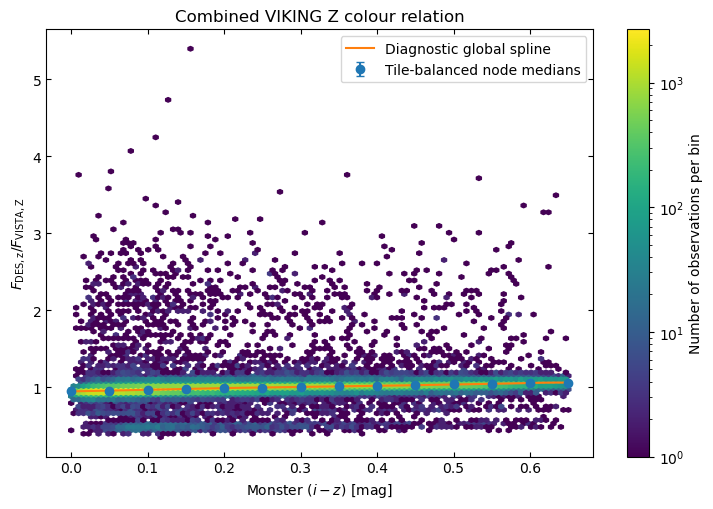

Saved: data/outputs/Monster_VIKING_Z/viking_z_tile_balanced_global_relation.pdf


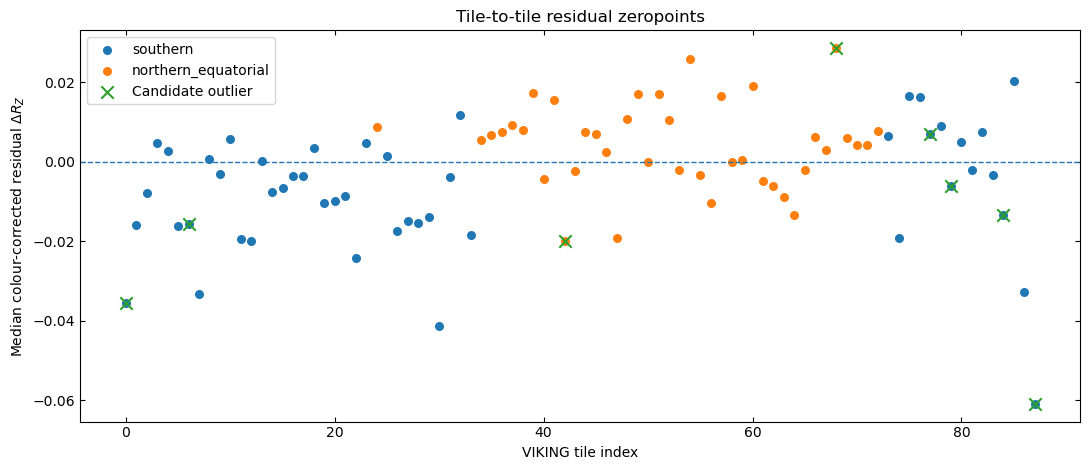

Saved: data/outputs/Monster_VIKING_Z/viking_z_tile_median_residuals.pdf


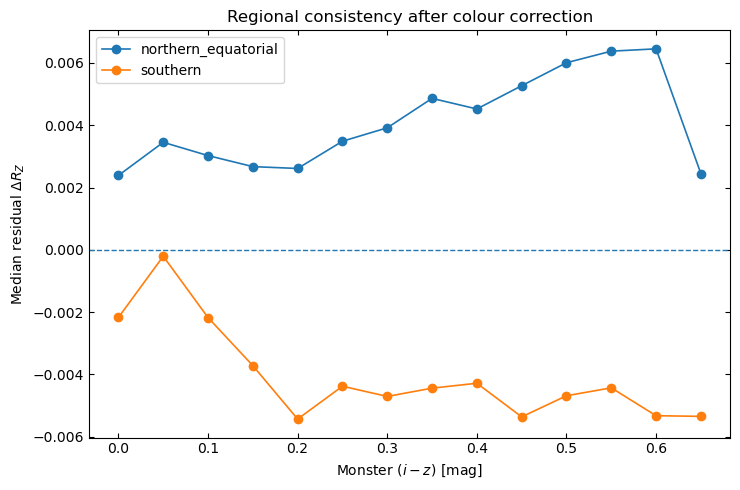

Saved: data/outputs/Monster_VIKING_Z/viking_z_regional_residuals_vs_colour.pdf

Saved diagnostic tables:
  data/outputs/Monster_VIKING_Z/viking_z_tile_balanced_diagnostic_nodes.csv
  data/outputs/Monster_VIKING_Z/viking_z_tile_residual_summary.csv
  data/outputs/Monster_VIKING_Z/viking_z_regional_residual_summary.csv

Prepared variables for the next step:
  diagnostic_global_spline      : tile-balanced preliminary global spline
  tile_balanced_node_table      : global diagnostic node measurements
  tile_residual_summary         : colour-corrected statistics for every tile
  regional_residual_summary     : north-south residual comparison


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table
from scipy.interpolate import make_interp_spline
from IPython.display import display


# -------------------------------------------------------------------
# Reload the combined products if the notebook was restarted
# -------------------------------------------------------------------

if "all_z_calibration_observations" not in globals():
    all_z_calibration_observations = Table.read(
        OUTPUT_DIR
        / "viking_z_calibration_observations_all_tiles.fits"
    )

if "unique_z_calibration_sample" not in globals():
    unique_z_calibration_sample = Table.read(
        OUTPUT_DIR
        / "viking_z_calibration_unique_sources.fits"
    )


# -------------------------------------------------------------------
# Diagnostic configuration
# -------------------------------------------------------------------

TILE_BALANCED_NODES = np.arange(
    0.0,
    0.6501,
    0.05,
)

MINIMUM_STARS_PER_TILE_BIN = 10
MINIMUM_TILES_PER_NODE = 10
OUTLIER_THRESHOLD_NMAD = 5.0


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def as_float_array(column):
    """Convert an ordinary or masked column to a float array."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(column, dtype=float),
            np.nan,
        ),
        dtype=float,
    )


def robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    centre = np.median(values)

    return float(
        1.4826
        * np.median(
            np.abs(values - centre)
        )
    )


# -------------------------------------------------------------------
# Read observation-level quantities
# -------------------------------------------------------------------

observation_colour = as_float_array(
    all_z_calibration_observations[
        "monster_iz_colour"
    ]
)

observation_ratio = as_float_array(
    all_z_calibration_observations[
        "monster_z_over_vista_z"
    ]
)

observation_tile = np.asarray(
    all_z_calibration_observations[
        "viking_file"
    ]
).astype(str)

observation_region = np.asarray(
    all_z_calibration_observations[
        "region"
    ]
).astype(str)

valid_observation = (
    np.isfinite(observation_colour)
    & np.isfinite(observation_ratio)
    & (observation_ratio > 0.0)
)

observation_colour = observation_colour[
    valid_observation
]

observation_ratio = observation_ratio[
    valid_observation
]

observation_tile = observation_tile[
    valid_observation
]

observation_region = observation_region[
    valid_observation
]


# -------------------------------------------------------------------
# Construct colour-bin edges centred on the candidate nodes
# -------------------------------------------------------------------

node_midpoints = 0.5 * (
    TILE_BALANCED_NODES[:-1]
    + TILE_BALANCED_NODES[1:]
)

node_edges = np.concatenate(
    [
        [
            TILE_BALANCED_NODES[0]
            - (
                node_midpoints[0]
                - TILE_BALANCED_NODES[0]
            )
        ],
        node_midpoints,
        [
            TILE_BALANCED_NODES[-1]
            + (
                TILE_BALANCED_NODES[-1]
                - node_midpoints[-1]
            )
        ],
    ]
)


# -------------------------------------------------------------------
# Calculate tile-balanced node values
# -------------------------------------------------------------------

node_records = []

for node_index, node_colour in enumerate(
    TILE_BALANCED_NODES
):
    in_colour_bin = (
        observation_colour
        >= node_edges[node_index]
    ) & (
        observation_colour
        < node_edges[node_index + 1]
    )

    if node_index == len(TILE_BALANCED_NODES) - 1:
        in_colour_bin = (
            observation_colour
            >= node_edges[node_index]
        ) & (
            observation_colour
            <= node_edges[node_index + 1]
        )

    bin_tiles = np.unique(
        observation_tile[in_colour_bin]
    )

    tile_medians = []
    tile_numbers = []

    for tile_name in bin_tiles:
        tile_selection = (
            in_colour_bin
            & (observation_tile == tile_name)
        )

        number_in_tile_bin = int(
            np.count_nonzero(tile_selection)
        )

        if (
            number_in_tile_bin
            < MINIMUM_STARS_PER_TILE_BIN
        ):
            continue

        tile_medians.append(
            float(
                np.median(
                    observation_ratio[
                        tile_selection
                    ]
                )
            )
        )

        tile_numbers.append(
            number_in_tile_bin
        )

    tile_medians = np.asarray(
        tile_medians,
        dtype=float,
    )

    if len(tile_medians) >= MINIMUM_TILES_PER_NODE:
        balanced_node_value = float(
            np.median(tile_medians)
        )

        tile_to_tile_nmad = robust_nmad(
            tile_medians
        )

        balanced_node_uncertainty = (
            1.2533
            * tile_to_tile_nmad
            / np.sqrt(len(tile_medians))
        )
    else:
        balanced_node_value = np.nan
        tile_to_tile_nmad = np.nan
        balanced_node_uncertainty = np.nan

    star_weighted_median = (
        float(
            np.median(
                observation_ratio[in_colour_bin]
            )
        )
        if np.any(in_colour_bin)
        else np.nan
    )

    node_records.append(
        {
            "node_colour":
                float(node_colour),

            "bin_lower_edge":
                float(node_edges[node_index]),

            "bin_upper_edge":
                float(node_edges[node_index + 1]),

            "number_of_stars":
                int(
                    np.count_nonzero(
                        in_colour_bin
                    )
                ),

            "number_of_contributing_tiles":
                int(len(tile_medians)),

            "tile_balanced_median_ratio":
                balanced_node_value,

            "star_weighted_median_ratio":
                star_weighted_median,

            "tile_to_tile_nmad":
                tile_to_tile_nmad,

            "node_uncertainty":
                balanced_node_uncertainty,
        }
    )


tile_balanced_node_table = pd.DataFrame(
    node_records
)

print("=" * 72)
print("TILE-BALANCED DIAGNOSTIC NODES")
print("=" * 72)

display(tile_balanced_node_table)


unsupported_nodes = (
    ~np.isfinite(
        tile_balanced_node_table[
            "tile_balanced_median_ratio"
        ]
    )
)

if np.any(unsupported_nodes):
    raise RuntimeError(
        "Some diagnostic nodes are insufficiently sampled:\n"
        f"{tile_balanced_node_table.loc[unsupported_nodes]}"
    )


# -------------------------------------------------------------------
# Fit the preliminary global spline
# -------------------------------------------------------------------

diagnostic_global_spline = make_interp_spline(
    tile_balanced_node_table[
        "node_colour"
    ].to_numpy(),

    tile_balanced_node_table[
        "tile_balanced_median_ratio"
    ].to_numpy(),

    k=3,
)


smooth_colour = np.linspace(
    TILE_BALANCED_NODES[0],
    TILE_BALANCED_NODES[-1],
    600,
)

smooth_ratio = diagnostic_global_spline(
    smooth_colour
)


# Check whether the fitted relation remains monotonic.
number_of_decreasing_steps = int(
    np.count_nonzero(
        np.diff(smooth_ratio) < 0.0
    )
)

print(
    f"\nNumber of decreasing spline steps: "
    f"{number_of_decreasing_steps}"
)


# -------------------------------------------------------------------
# Calculate colour-corrected residuals for all observations
# -------------------------------------------------------------------

inside_spline_range = (
    observation_colour
    >= TILE_BALANCED_NODES[0]
) & (
    observation_colour
    <= TILE_BALANCED_NODES[-1]
)

model_ratio = np.full(
    len(observation_ratio),
    np.nan,
    dtype=float,
)

model_ratio[
    inside_spline_range
] = diagnostic_global_spline(
    observation_colour[
        inside_spline_range
    ]
)

ratio_residual = (
    observation_ratio
    - model_ratio
)


# -------------------------------------------------------------------
# Summarise residuals separately for each tile
# -------------------------------------------------------------------

tile_residual_records = []

for tile_name in np.unique(
    observation_tile[
        inside_spline_range
    ]
):
    tile_selection = (
        inside_spline_range
        & (observation_tile == tile_name)
    )

    tile_residuals = ratio_residual[
        tile_selection
    ]

    tile_region_values = np.unique(
        observation_region[
            tile_selection
        ]
    )

    tile_region = (
        tile_region_values[0]
        if len(tile_region_values) > 0
        else ""
    )

    tile_residual_records.append(
        {
            "viking_file":
                tile_name,

            "region":
                tile_region,

            "number_of_stars":
                int(
                    np.count_nonzero(
                        tile_selection
                    )
                ),

            "median_residual":
                float(
                    np.median(
                        tile_residuals
                    )
                ),

            "residual_nmad":
                robust_nmad(
                    tile_residuals
                ),

            "p16_residual":
                float(
                    np.percentile(
                        tile_residuals,
                        16,
                    )
                ),

            "p84_residual":
                float(
                    np.percentile(
                        tile_residuals,
                        84,
                    )
                ),
        }
    )


tile_residual_summary = pd.DataFrame(
    tile_residual_records
).sort_values(
    "viking_file"
).reset_index(drop=True)


# -------------------------------------------------------------------
# Identify candidate tile outliers using robust tile statistics
# -------------------------------------------------------------------

tile_median_values = (
    tile_residual_summary[
        "median_residual"
    ].to_numpy()
)

tile_scatter_values = (
    tile_residual_summary[
        "residual_nmad"
    ].to_numpy()
)

tile_median_centre = float(
    np.median(
        tile_median_values
    )
)

tile_median_scale = robust_nmad(
    tile_median_values
)

tile_scatter_centre = float(
    np.median(
        tile_scatter_values
    )
)

tile_scatter_scale = robust_nmad(
    tile_scatter_values
)


if (
    not np.isfinite(tile_median_scale)
    or tile_median_scale == 0.0
):
    median_outlier = np.zeros(
        len(tile_residual_summary),
        dtype=bool,
    )
else:
    median_outlier = (
        np.abs(
            tile_median_values
            - tile_median_centre
        )
        > (
            OUTLIER_THRESHOLD_NMAD
            * tile_median_scale
        )
    )


if (
    not np.isfinite(tile_scatter_scale)
    or tile_scatter_scale == 0.0
):
    scatter_outlier = np.zeros(
        len(tile_residual_summary),
        dtype=bool,
    )
else:
    scatter_outlier = (
        tile_scatter_values
        > (
            tile_scatter_centre
            + OUTLIER_THRESHOLD_NMAD
            * tile_scatter_scale
        )
    )


tile_residual_summary[
    "candidate_median_outlier"
] = median_outlier

tile_residual_summary[
    "candidate_scatter_outlier"
] = scatter_outlier

tile_residual_summary[
    "candidate_outlier"
] = (
    median_outlier
    | scatter_outlier
)


print("\n" + "=" * 72)
print("TILE RESIDUAL SUMMARY")
print("=" * 72)

print(
    f"Median of tile residual medians : "
    f"{tile_median_centre:+.6f}"
)

print(
    f"NMAD of tile residual medians   : "
    f"{tile_median_scale:.6f}"
)

print(
    f"Median tile residual NMAD       : "
    f"{tile_scatter_centre:.6f}"
)

print(
    f"NMAD of tile residual NMADs     : "
    f"{tile_scatter_scale:.6f}"
)

print(
    f"Candidate outlier tiles         : "
    f"{np.count_nonzero(tile_residual_summary['candidate_outlier']):d}"
)


candidate_tile_outliers = (
    tile_residual_summary[
        tile_residual_summary[
            "candidate_outlier"
        ]
    ]
    .sort_values(
        [
            "candidate_scatter_outlier",
            "residual_nmad",
        ],
        ascending=False,
    )
)

if len(candidate_tile_outliers) > 0:
    print("\nCandidate tiles requiring inspection:")

    display(candidate_tile_outliers)


# -------------------------------------------------------------------
# Regional residual comparison
# -------------------------------------------------------------------

regional_records = []

for region_name in np.unique(
    observation_region[
        inside_spline_range
    ]
):
    region_selection = (
        inside_spline_range
        & (
            observation_region
            == region_name
        )
    )

    regional_residuals = ratio_residual[
        region_selection
    ]

    regional_records.append(
        {
            "region":
                region_name,

            "number_of_stars":
                int(
                    np.count_nonzero(
                        region_selection
                    )
                ),

            "median_residual":
                float(
                    np.median(
                        regional_residuals
                    )
                ),

            "residual_nmad":
                robust_nmad(
                    regional_residuals
                ),

            "p16_residual":
                float(
                    np.percentile(
                        regional_residuals,
                        16,
                    )
                ),

            "p84_residual":
                float(
                    np.percentile(
                        regional_residuals,
                        84,
                    )
                ),
        }
    )


regional_residual_summary = pd.DataFrame(
    regional_records
)

print("\nRegional residual comparison")
print("----------------------------")

display(regional_residual_summary)


# -------------------------------------------------------------------
# Plot 1: combined relation and tile-balanced spline
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.5, 5.2)
)

hexbin = ax.hexbin(
    observation_colour[
        inside_spline_range
    ],
    observation_ratio[
        inside_spline_range
    ],
    gridsize=100,
    mincnt=1,
    bins="log",
)

ax.errorbar(
    tile_balanced_node_table[
        "node_colour"
    ],
    tile_balanced_node_table[
        "tile_balanced_median_ratio"
    ],
    yerr=tile_balanced_node_table[
        "node_uncertainty"
    ],
    fmt="o",
    capsize=3,
    label="Tile-balanced node medians",
)

ax.plot(
    smooth_colour,
    smooth_ratio,
    linewidth=1.5,
    label="Diagnostic global spline",
)

ax.set_xlabel(
    r"Monster $(i-z)$ [mag]"
)

ax.set_ylabel(
    r"$F_{\rm DES,z}/F_{\rm VISTA,Z}$"
)

ax.set_title(
    "Combined VIKING Z colour relation"
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of observations per bin"
)

fig.tight_layout()

global_relation_path = (
    OUTPUT_DIR
    / "viking_z_tile_balanced_global_relation.pdf"
)

fig.savefig(
    global_relation_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {global_relation_path}")


# -------------------------------------------------------------------
# Plot 2: median residual for every tile
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 4.8)
)

tile_indices = np.arange(
    len(tile_residual_summary)
)

for region_name in tile_residual_summary[
    "region"
].unique():
    region_mask = (
        tile_residual_summary[
            "region"
        ]
        == region_name
    )

    ax.scatter(
        tile_indices[
            region_mask
        ],
        tile_residual_summary.loc[
            region_mask,
            "median_residual"
        ],
        s=30,
        label=region_name,
    )


candidate_mask = tile_residual_summary[
    "candidate_outlier"
].to_numpy()

if np.any(candidate_mask):
    ax.scatter(
        tile_indices[
            candidate_mask
        ],
        tile_residual_summary.loc[
            candidate_mask,
            "median_residual"
        ],
        marker="x",
        s=80,
        linewidths=1.5,
        label="Candidate outlier",
    )


ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    "VIKING tile index"
)

ax.set_ylabel(
    r"Median colour-corrected residual $\Delta R_Z$"
)

ax.set_title(
    "Tile-to-tile residual zeropoints"
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

fig.tight_layout()

tile_offset_plot_path = (
    OUTPUT_DIR
    / "viking_z_tile_median_residuals.pdf"
)

fig.savefig(
    tile_offset_plot_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {tile_offset_plot_path}")


# -------------------------------------------------------------------
# Plot 3: regional residual medians as a function of colour
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.5, 5.0)
)

for region_name in np.unique(
    observation_region
):
    region_bin_medians = np.full(
        len(TILE_BALANCED_NODES),
        np.nan,
        dtype=float,
    )

    for node_index in range(
        len(TILE_BALANCED_NODES)
    ):
        selection = (
            inside_spline_range
            & (
                observation_region
                == region_name
            )
            & (
                observation_colour
                >= node_edges[node_index]
            )
            & (
                observation_colour
                < node_edges[node_index + 1]
            )
        )

        if node_index == len(TILE_BALANCED_NODES) - 1:
            selection = (
                inside_spline_range
                & (
                    observation_region
                    == region_name
                )
                & (
                    observation_colour
                    >= node_edges[node_index]
                )
                & (
                    observation_colour
                    <= node_edges[node_index + 1]
                )
            )

        if np.count_nonzero(selection) >= 50:
            region_bin_medians[
                node_index
            ] = np.median(
                ratio_residual[
                    selection
                ]
            )


    valid_region_bins = np.isfinite(
        region_bin_medians
    )

    ax.plot(
        TILE_BALANCED_NODES[
            valid_region_bins
        ],
        region_bin_medians[
            valid_region_bins
        ],
        marker="o",
        linewidth=1.2,
        label=region_name,
    )


ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    r"Monster $(i-z)$ [mag]"
)

ax.set_ylabel(
    r"Median residual $\Delta R_Z$"
)

ax.set_title(
    "Regional consistency after colour correction"
)

ax.legend()

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

fig.tight_layout()

regional_plot_path = (
    OUTPUT_DIR
    / "viking_z_regional_residuals_vs_colour.pdf"
)

fig.savefig(
    regional_plot_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {regional_plot_path}")


# -------------------------------------------------------------------
# Save diagnostic tables
# -------------------------------------------------------------------

tile_balanced_node_path = (
    OUTPUT_DIR
    / "viking_z_tile_balanced_diagnostic_nodes.csv"
)

tile_residual_summary_path = (
    OUTPUT_DIR
    / "viking_z_tile_residual_summary.csv"
)

regional_residual_summary_path = (
    OUTPUT_DIR
    / "viking_z_regional_residual_summary.csv"
)

tile_balanced_node_table.to_csv(
    tile_balanced_node_path,
    index=False,
)

tile_residual_summary.to_csv(
    tile_residual_summary_path,
    index=False,
)

regional_residual_summary.to_csv(
    regional_residual_summary_path,
    index=False,
)


print("\nSaved diagnostic tables:")
print(f"  {tile_balanced_node_path}")
print(f"  {tile_residual_summary_path}")
print(f"  {regional_residual_summary_path}")


print("\nPrepared variables for the next step:")
print(
    "  diagnostic_global_spline      : "
    "tile-balanced preliminary global spline"
)

print(
    "  tile_balanced_node_table      : "
    "global diagnostic node measurements"
)

print(
    "  tile_residual_summary         : "
    "colour-corrected statistics for every tile"
)

print(
    "  regional_residual_summary     : "
    "north-south residual comparison"
)

### Result

The tile-balanced Z-band relation is smooth and monotonic over
0.0<(i-z)_{Monster}<0.65. All central nodes receive
contributions from all 88 tiles, while the two edge nodes remain supported by
at least 74 tiles. The tile-balanced and star-weighted node values differ by
less than 0.0025.

Eight tiles are identified as candidates for further inspection. Seven have
unusually large internal residual scatter, while one has a large median
photometric offset. These tiles are not removed automatically.

The northern/equatorial and southern samples differ in median residual by
approximately 0.007, corresponding to about 0.7\% in flux ratio. The
difference is broadly constant with colour and therefore appears more
consistent with a regional zeropoint offset than with a change in the
VIRCAM--DES colour transformation.

## 12. Derive and validate the final Z-band spline

The final VIRCAM Z-band transformation is derived from all 88 available
VIKING catalogues. No catalogue is removed because modest tile-to-tile
photometric variation is expected and the transformation is calculated from
robust tile-level medians rather than directly from all individual stars.

The validation is performed using complete tiles rather than randomly selected
stars. Within each of the northern/equatorial and southern regions, every
fifth tile is reserved for validation. Sources appearing in a validation tile
are also removed from the fitting sample when they occur in an overlapping
fitting tile, preventing the same Monster source from entering both samples.

Ten spline nodes are placed uniformly over

$$
0.0 \leq (i-z)_{\mathrm{Monster}} \leq 0.65.
$$

This interval contains approximately 98 per cent of the selected calibration
sources and is well sampled by both VIKING regions.

For every node:

1. the flux ratios are grouped by VIKING tile;
2. individual measurements within each tile and colour interval are
   robustly clipped;
3. one median flux ratio is calculated for each sufficiently populated tile;
4. the tile medians are robustly clipped;
5. the final node value is the median of the retained tile medians.

This gives approximately equal weight to each tile and prevents dense fields
or a small number of unusual measurements from dominating the result.

A cubic spline is first fitted using only the fitting tiles. Its performance
is measured using the withheld validation tiles. After validation, the final
node values are recalculated using all 88 tiles and written in the standard
Monster colour-term YAML structure.

The fitted quantity is

$$
R_Z(i-z)
=
\frac{F_{\mathrm{Monster},z}}
     {F_{\mathrm{VISTA},Z}}.
$$

The YAML transformation therefore predicts the VISTA flux as

$$
F_{\mathrm{VISTA},Z}
=
\frac{F_{\mathrm{Monster},z}}
     {R_Z(i-z)}.
$$

<>:1993: SyntaxWarning: invalid escape sequence '\('
<>:1993: SyntaxWarning: invalid escape sequence '\('
<>:1990: SyntaxWarning: invalid escape sequence '\m'
<>:1990: SyntaxWarning: invalid escape sequence '\l'
<>:1993: SyntaxWarning: invalid escape sequence '\('
<>:1993: SyntaxWarning: invalid escape sequence '\('
<>:1990: SyntaxWarning: invalid escape sequence '\m'
<>:1990: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16889/3698246755.py:1993: SyntaxWarning: invalid escape sequence '\('
  "\nCopy the following into a Markdown cell:\n"
/tmp/ipykernel_16889/3698246755.py:1993: SyntaxWarning: invalid escape sequence '\('
  "\nCopy the following into a Markdown cell:\n"
/tmp/ipykernel_16889/3698246755.py:1990: SyntaxWarning: invalid escape sequence '\m'
  """
/tmp/ipykernel_16889/3698246755.py:1990: SyntaxWarning: invalid escape sequence '\l'
  """


FINAL Z-BAND TILE SPLIT
Total tiles                  : 88
Fitting tiles                : 70
Validation tiles             : 18
Fitting observations         : 151,416
Validation observations      : 37,246


,region,subset,number_of_tiles
0,northern_equatorial,fitting,32
1,northern_equatorial,validation,8
2,southern,fitting,38
3,southern,validation,10



Validation-fit spline nodes
---------------------------


,node_colour,bin_lower_edge,bin_upper_edge,number_of_stars,number_of_tiles_before_clipping,number_of_tiles_after_clipping,node_ratio,tile_median_nmad,node_uncertainty
0,0.000000,-0.036111,0.036111,11255,68,67,0.948169,0.015032,0.002302
1,0.072222,0.036111,0.108333,38166,70,69,0.961080,0.012370,0.001866
2,0.144444,0.108333,0.180556,27301,70,69,0.978125,0.012017,0.001813
3,0.216667,0.180556,0.252778,18674,70,69,0.990827,0.013036,0.001967
4,0.288889,0.252778,0.325000,14782,70,69,1.003415,0.012914,0.001948
5,0.361111,0.325000,0.397222,12118,70,69,1.012760,0.013054,0.001970
6,0.433333,0.397222,0.469444,10765,70,69,1.023394,0.013083,0.001974
7,0.505556,0.469444,0.541667,9245,70,69,1.034655,0.014599,0.002203
8,0.577778,0.541667,0.613889,5884,70,69,1.050128,0.014250,0.002150
9,0.650000,0.613889,0.686111,2506,67,65,1.060377,0.014619,0.002273


...


Decreasing steps in validation spline: 0

FINAL ALL-TILE Z-BAND SPLINE NODES


,node_colour,bin_lower_edge,bin_upper_edge,number_of_stars,number_of_tiles_before_clipping,number_of_tiles_after_clipping,node_ratio,tile_median_nmad,node_uncertainty
0,0.000000,-0.036111,0.036111,14021,86,84,0.948521,0.014081,0.001925
1,0.072222,0.036111,0.108333,47279,88,86,0.961017,0.012104,0.001636
2,0.144444,0.108333,0.180556,34026,88,86,0.977703,0.012047,0.001628
3,0.216667,0.180556,0.252778,23218,88,86,0.990793,0.013036,0.001762
4,0.288889,0.252778,0.325000,18519,88,86,1.001952,0.011997,0.001621
5,0.361111,0.325000,0.397222,15334,88,86,1.012390,0.012702,0.001717
6,0.433333,0.397222,0.469444,13724,88,85,1.023152,0.012840,0.001745
7,0.505556,0.469444,0.541667,11844,88,86,1.035284,0.015112,0.002042
8,0.577778,0.541667,0.613889,7636,88,86,1.049649,0.013599,0.001838
9,0.650000,0.613889,0.686111,2027,71,69,1.057176,0.015368,0.002319


Decreasing steps in final spline: 0

Final versus validation-fit node comparison
-------------------------------------------


,node_colour,validation_fit_ratio,final_all_tile_ratio,final_minus_validation
0,0.000000,0.948169,0.948521,0.000352
1,0.072222,0.961080,0.961017,-0.000064
2,0.144444,0.978125,0.977703,-0.000422
3,0.216667,0.990827,0.990793,-0.000034
4,0.288889,1.003415,1.001952,-0.001463
5,0.361111,1.012760,1.012390,-0.000369
6,0.433333,1.023394,1.023152,-0.000243
7,0.505556,1.034655,1.035284,0.000629
8,0.577778,1.050128,1.049649,-0.000479
9,0.650000,1.060377,1.057176,-0.003201


Maximum absolute node difference: 0.003201

YAML DIRECTION TEST
Sources in direction test       : 184,936
Median fractional flux residual : +0.1235 per cent
Fractional flux residual NMAD   : 2.6834 per cent

Final YAML written and verified:
data/outputs/Monster_VIKING_Z/Monster_to_VISTA_band_z.yaml


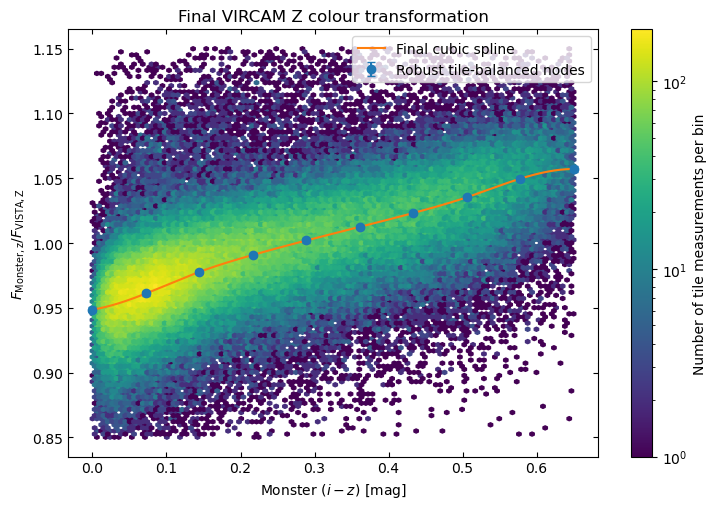

Saved: data/outputs/Monster_VIKING_Z/viking_z_final_colour_transformation.pdf


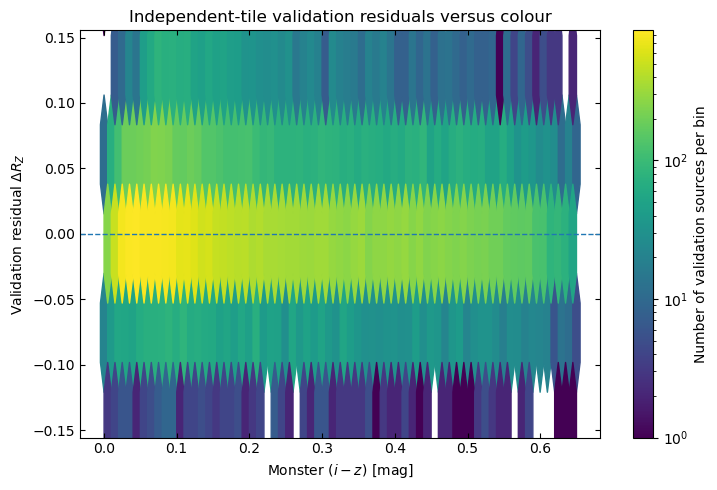

Saved: data/outputs/Monster_VIKING_Z/viking_z_validation_residuals_vs_colour.pdf


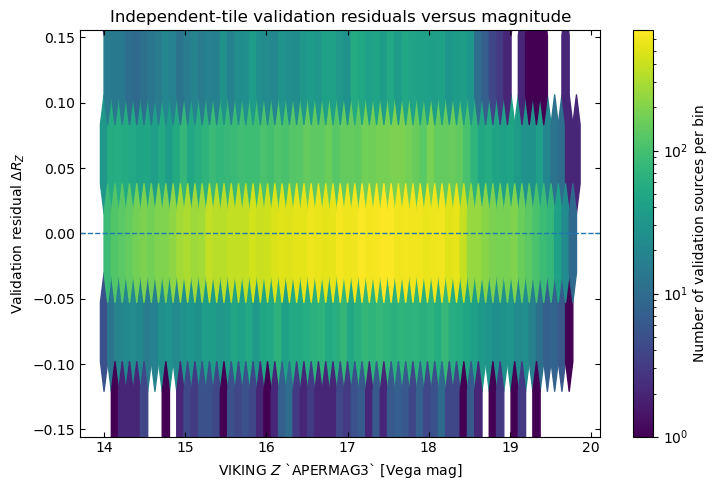

Saved: data/outputs/Monster_VIKING_Z/viking_z_validation_residuals_vs_magnitude.pdf

Saved final products:
  data/outputs/Monster_VIKING_Z/Monster_to_VISTA_band_z.yaml
  data/outputs/Monster_VIKING_Z/viking_z_final_nodes.csv
  data/outputs/Monster_VIKING_Z/viking_z_validation_summary.csv
  data/outputs/Monster_VIKING_Z/viking_z_validation_tile_summary.csv
  data/outputs/Monster_VIKING_Z/viking_z_validation_residuals.csv
  data/outputs/Monster_VIKING_Z/viking_z_fitting_validation_tile_split.csv

Copy the following into a Markdown cell:


### Result

The final VIRCAM \(Z\)-band transformation was validated using
18 withheld VIKING tiles and then refitted using all
88 catalogues. The independent validation sample
contains 36,819 unique Monster sources.

The validation residual has a median of
+0.00209, an NMAD of
0.03110, and a fractional NMAD of
3.138 per cent. The maximum difference
between the validation-fit and final all-tile node values is
0.00320.

The final spline is defined over
\

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from astropy.table import Table
from scipy.interpolate import make_interp_spline
from scipy.stats import spearmanr
from IPython.display import display


# -------------------------------------------------------------------
# Input and output configuration
# -------------------------------------------------------------------

OUTPUT_DIR = Path(
    "data/outputs/Monster_VIKING_Z"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ALL_OBSERVATIONS_PATH = (
    OUTPUT_DIR
    / "viking_z_calibration_observations_all_tiles.fits"
)

UNIQUE_SOURCES_PATH = (
    OUTPUT_DIR
    / "viking_z_calibration_unique_sources.fits"
)

FINAL_YAML_PATH = (
    OUTPUT_DIR
    / "Monster_to_VISTA_band_z.yaml"
)


# -------------------------------------------------------------------
# Final fitting configuration
# -------------------------------------------------------------------

FINAL_NODES = np.linspace(
    0.0,
    0.65,
    10,
)

VALIDATION_TILE_INTERVAL = 5

MINIMUM_STARS_PER_TILE_BIN = 10
MINIMUM_TILES_PER_NODE = 10

STAR_CLIP_THRESHOLD = 4.0
TILE_CLIP_THRESHOLD = 4.0
MAXIMUM_CLIP_ITERATIONS = 10

RANDOM_SEED = 24601


# -------------------------------------------------------------------
# Load the combined calibration products
# -------------------------------------------------------------------

if "all_z_calibration_observations" not in globals():
    if not ALL_OBSERVATIONS_PATH.exists():
        raise FileNotFoundError(
            f"Combined observation catalogue not found:\n"
            f"{ALL_OBSERVATIONS_PATH}"
        )

    all_z_calibration_observations = Table.read(
        ALL_OBSERVATIONS_PATH
    )


if "unique_z_calibration_sample" not in globals():
    if not UNIQUE_SOURCES_PATH.exists():
        raise FileNotFoundError(
            f"Unique-source catalogue not found:\n"
            f"{UNIQUE_SOURCES_PATH}"
        )

    unique_z_calibration_sample = Table.read(
        UNIQUE_SOURCES_PATH
    )


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def as_float_array(column):
    """Convert an ordinary or masked table column to float."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column,
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


def robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return np.nan

    centre = np.median(values)

    return float(
        1.4826
        * np.median(
            np.abs(values - centre)
        )
    )


def iterative_nmad_clip(
    values,
    threshold,
    maximum_iterations=MAXIMUM_CLIP_ITERATIONS,
):
    """
    Return a Boolean mask selecting values retained after iterative
    median/NMAD clipping.
    """
    values = np.asarray(
        values,
        dtype=float,
    )

    keep = np.isfinite(values)

    for _ in range(maximum_iterations):

        retained = values[
            keep
        ]

        if len(retained) < 3:
            break

        centre = np.median(
            retained
        )

        scatter = robust_nmad(
            retained
        )

        if (
            not np.isfinite(scatter)
            or scatter <= 0.0
        ):
            break

        new_keep = (
            np.isfinite(values)
            & (
                np.abs(
                    values - centre
                )
                <= threshold * scatter
            )
        )

        if np.array_equal(
            new_keep,
            keep,
        ):
            break

        keep = new_keep

    return keep


def safe_spearman(
    x_values,
    y_values,
):
    """Return Spearman rho and p-value for valid nonconstant data."""
    x_values = np.asarray(
        x_values,
        dtype=float,
    )

    y_values = np.asarray(
        y_values,
        dtype=float,
    )

    valid = (
        np.isfinite(x_values)
        & np.isfinite(y_values)
    )

    x_valid = x_values[
        valid
    ]

    y_valid = y_values[
        valid
    ]

    if (
        len(x_valid) < 10
        or np.unique(x_valid).size < 2
        or np.unique(y_valid).size < 2
    ):
        return np.nan, np.nan

    result = spearmanr(
        x_valid,
        y_valid,
    )

    return (
        float(result.statistic),
        float(result.pvalue),
    )


def construct_node_edges(nodes):
    """Construct colour-bin edges centred on the requested nodes."""
    nodes = np.asarray(
        nodes,
        dtype=float,
    )

    midpoints = 0.5 * (
        nodes[:-1]
        + nodes[1:]
    )

    first_edge = (
        nodes[0]
        - (
            midpoints[0]
            - nodes[0]
        )
    )

    last_edge = (
        nodes[-1]
        + (
            nodes[-1]
            - midpoints[-1]
        )
    )

    return np.concatenate(
        [
            [first_edge],
            midpoints,
            [last_edge],
        ]
    )


def construct_tile_balanced_nodes(
    colours,
    ratios,
    tile_names,
    selection,
    nodes,
):
    """
    Derive robust tile-balanced node values.

    Individual stellar ratios are clipped separately within every
    tile and colour interval. The resulting tile medians are then
    clipped before calculating the global node value.
    """
    colours = np.asarray(
        colours,
        dtype=float,
    )

    ratios = np.asarray(
        ratios,
        dtype=float,
    )

    tile_names = np.asarray(
        tile_names,
    ).astype(str)

    selection = np.asarray(
        selection,
        dtype=bool,
    )

    nodes = np.asarray(
        nodes,
        dtype=float,
    )

    node_edges = construct_node_edges(
        nodes
    )

    records = []

    for node_index, node_colour in enumerate(
        nodes
    ):
        in_colour_interval = (
            selection
            & (
                colours
                >= node_edges[node_index]
            )
            & (
                colours
                < node_edges[node_index + 1]
            )
        )

        if node_index == len(nodes) - 1:
            in_colour_interval = (
                selection
                & (
                    colours
                    >= node_edges[node_index]
                )
                & (
                    colours
                    <= node_edges[node_index + 1]
                )
            )

        contributing_tiles = np.unique(
            tile_names[
                in_colour_interval
            ]
        )

        tile_medians = []
        tile_numbers_before = []
        tile_numbers_after = []
        accepted_tile_names = []

        for tile_name in contributing_tiles:

            tile_selection = (
                in_colour_interval
                & (
                    tile_names
                    == tile_name
                )
            )

            tile_values = ratios[
                tile_selection
            ]

            number_before = len(
                tile_values
            )

            if (
                number_before
                < MINIMUM_STARS_PER_TILE_BIN
            ):
                continue

            star_keep = iterative_nmad_clip(
                tile_values,
                threshold=STAR_CLIP_THRESHOLD,
            )

            clipped_tile_values = (
                tile_values[
                    star_keep
                ]
            )

            number_after = len(
                clipped_tile_values
            )

            if (
                number_after
                < MINIMUM_STARS_PER_TILE_BIN
            ):
                continue

            tile_medians.append(
                float(
                    np.median(
                        clipped_tile_values
                    )
                )
            )

            tile_numbers_before.append(
                number_before
            )

            tile_numbers_after.append(
                number_after
            )

            accepted_tile_names.append(
                tile_name
            )


        tile_medians = np.asarray(
            tile_medians,
            dtype=float,
        )

        if (
            len(tile_medians)
            < MINIMUM_TILES_PER_NODE
        ):
            records.append(
                {
                    "node_colour":
                        float(node_colour),

                    "bin_lower_edge":
                        float(node_edges[node_index]),

                    "bin_upper_edge":
                        float(node_edges[node_index + 1]),

                    "number_of_stars":
                        int(
                            np.count_nonzero(
                                in_colour_interval
                            )
                        ),

                    "number_of_tiles_before_clipping":
                        len(tile_medians),

                    "number_of_tiles_after_clipping":
                        0,

                    "node_ratio":
                        np.nan,

                    "tile_median_nmad":
                        np.nan,

                    "node_uncertainty":
                        np.nan,
                }
            )

            continue


        tile_keep = iterative_nmad_clip(
            tile_medians,
            threshold=TILE_CLIP_THRESHOLD,
        )

        retained_tile_medians = (
            tile_medians[
                tile_keep
            ]
        )

        if (
            len(retained_tile_medians)
            < MINIMUM_TILES_PER_NODE
        ):
            node_ratio = np.nan
            tile_scatter = np.nan
            node_uncertainty = np.nan

        else:
            node_ratio = float(
                np.median(
                    retained_tile_medians
                )
            )

            tile_scatter = robust_nmad(
                retained_tile_medians
            )

            node_uncertainty = (
                1.2533
                * tile_scatter
                / np.sqrt(
                    len(
                        retained_tile_medians
                    )
                )
            )


        records.append(
            {
                "node_colour":
                    float(node_colour),

                "bin_lower_edge":
                    float(node_edges[node_index]),

                "bin_upper_edge":
                    float(node_edges[node_index + 1]),

                "number_of_stars":
                    int(
                        np.count_nonzero(
                            in_colour_interval
                        )
                    ),

                "number_of_tiles_before_clipping":
                    int(
                        len(tile_medians)
                    ),

                "number_of_tiles_after_clipping":
                    int(
                        len(retained_tile_medians)
                    ),

                "node_ratio":
                    node_ratio,

                "tile_median_nmad":
                    tile_scatter,

                "node_uncertainty":
                    node_uncertainty,
            }
        )


    result = pd.DataFrame(
        records
    )

    unsupported = (
        ~np.isfinite(
            result["node_ratio"]
        )
    )

    if np.any(unsupported):
        raise RuntimeError(
            "The following spline nodes are insufficiently sampled:\n"
            f"{result.loc[unsupported]}"
        )

    return result


def evaluate_spline(
    spline,
    colours,
    minimum_colour,
    maximum_colour,
):
    """Evaluate a spline only inside its supported colour range."""
    colours = np.asarray(
        colours,
        dtype=float,
    )

    model = np.full(
        len(colours),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(colours)
        & (
            colours
            >= minimum_colour
        )
        & (
            colours
            <= maximum_colour
        )
    )

    model[
        valid
    ] = spline(
        colours[
            valid
        ]
    )

    return model


def residual_summary(
    residuals,
    model_values,
):
    """Calculate robust absolute and fractional residual statistics."""
    residuals = np.asarray(
        residuals,
        dtype=float,
    )

    model_values = np.asarray(
        model_values,
        dtype=float,
    )

    valid = (
        np.isfinite(residuals)
        & np.isfinite(model_values)
        & (model_values > 0.0)
    )

    selected_residuals = residuals[
        valid
    ]

    fractional_residuals = (
        selected_residuals
        / model_values[
            valid
        ]
    )

    return {
        "number_of_sources":
            int(
                len(
                    selected_residuals
                )
            ),

        "median_residual":
            float(
                np.median(
                    selected_residuals
                )
            ),

        "residual_nmad":
            robust_nmad(
                selected_residuals
            ),

        "residual_std":
            float(
                np.std(
                    selected_residuals
                )
            ),

        "fractional_median_percent":
            float(
                100.0
                * np.median(
                    fractional_residuals
                )
            ),

        "fractional_nmad_percent":
            float(
                100.0
                * robust_nmad(
                    fractional_residuals
                )
            ),

        "p16_residual":
            float(
                np.percentile(
                    selected_residuals,
                    16,
                )
            ),

        "p84_residual":
            float(
                np.percentile(
                    selected_residuals,
                    84,
                )
            ),
    }


# -------------------------------------------------------------------
# Extract observation-level calibration quantities
# -------------------------------------------------------------------

monster_id = np.asarray(
    all_z_calibration_observations[
        "monster_id"
    ],
    dtype=np.int64,
)

tile_name = np.asarray(
    all_z_calibration_observations[
        "viking_file"
    ]
).astype(str)

region = np.asarray(
    all_z_calibration_observations[
        "region"
    ]
).astype(str)

colour = as_float_array(
    all_z_calibration_observations[
        "monster_iz_colour"
    ]
)

measured_ratio = as_float_array(
    all_z_calibration_observations[
        "monster_z_over_vista_z"
    ]
)

viking_z_magnitude = as_float_array(
    all_z_calibration_observations[
        "viking_z_mag_vega"
    ]
)

viking_z_snr = as_float_array(
    all_z_calibration_observations[
        "viking_z_snr"
    ]
)

separation_arcsec = as_float_array(
    all_z_calibration_observations[
        "separation_arcsec"
    ]
)


valid_input = (
    np.isfinite(colour)
    & np.isfinite(measured_ratio)
    & (measured_ratio > 0.0)
    & np.isfinite(viking_z_magnitude)
)


# -------------------------------------------------------------------
# Define deterministic fitting and validation tiles
# -------------------------------------------------------------------

tile_region_table = (
    pd.DataFrame(
        {
            "viking_file":
                tile_name,

            "region":
                region,
        }
    )
    .drop_duplicates(
        subset="viking_file"
    )
    .sort_values(
        [
            "region",
            "viking_file",
        ]
    )
    .reset_index(drop=True)
)


validation_tiles = []

for region_name in sorted(
    tile_region_table[
        "region"
    ].unique()
):
    regional_tiles = (
        tile_region_table[
            tile_region_table[
                "region"
            ]
            == region_name
        ][
            "viking_file"
        ]
        .sort_values()
        .to_numpy()
    )

    validation_tiles.extend(
        regional_tiles[
            ::VALIDATION_TILE_INTERVAL
        ]
    )


validation_tiles = np.asarray(
    validation_tiles,
    dtype=str,
)

fitting_tiles = tile_region_table[
    ~tile_region_table[
        "viking_file"
    ].isin(
        validation_tiles
    )
][
    "viking_file"
].to_numpy()


validation_observation_mask = (
    valid_input
    & np.isin(
        tile_name,
        validation_tiles,
    )
)


# Prevent the same source from appearing in both fitting and validation.
validation_monster_ids = np.unique(
    monster_id[
        validation_observation_mask
    ]
)

fitting_observation_mask = (
    valid_input
    & np.isin(
        tile_name,
        fitting_tiles,
    )
    & ~np.isin(
        monster_id,
        validation_monster_ids,
    )
)


print("=" * 72)
print("FINAL Z-BAND TILE SPLIT")
print("=" * 72)

print(
    f"Total tiles                  : "
    f"{len(tile_region_table)}"
)

print(
    f"Fitting tiles                : "
    f"{len(fitting_tiles)}"
)

print(
    f"Validation tiles             : "
    f"{len(validation_tiles)}"
)

print(
    f"Fitting observations         : "
    f"{np.count_nonzero(fitting_observation_mask):,}"
)

print(
    f"Validation observations      : "
    f"{np.count_nonzero(validation_observation_mask):,}"
)


split_summary = (
    tile_region_table
    .assign(
        subset=np.where(
            tile_region_table[
                "viking_file"
            ].isin(
                validation_tiles
            ),
            "validation",
            "fitting",
        )
    )
    .groupby(
        [
            "region",
            "subset",
        ]
    )
    .size()
    .reset_index(
        name="number_of_tiles"
    )
)

display(split_summary)


# -------------------------------------------------------------------
# Fit the validation spline using fitting tiles only
# -------------------------------------------------------------------

validation_fit_node_table = construct_tile_balanced_nodes(
    colours=colour,
    ratios=measured_ratio,
    tile_names=tile_name,
    selection=fitting_observation_mask,
    nodes=FINAL_NODES,
)


validation_spline = make_interp_spline(
    validation_fit_node_table[
        "node_colour"
    ].to_numpy(dtype=float),

    validation_fit_node_table[
        "node_ratio"
    ].to_numpy(dtype=float),

    k=3,
)


print("\nValidation-fit spline nodes")
print("---------------------------")

display(
    validation_fit_node_table
)


# -------------------------------------------------------------------
# Select one measurement per validation Monster source
# -------------------------------------------------------------------

validation_indices = np.flatnonzero(
    validation_observation_mask
)

validation_order = np.lexsort(
    (
        separation_arcsec[
            validation_indices
        ],
        -viking_z_snr[
            validation_indices
        ],
        monster_id[
            validation_indices
        ],
    )
)

ordered_validation_indices = (
    validation_indices[
        validation_order
    ]
)

ordered_validation_ids = monster_id[
    ordered_validation_indices
]

_, first_validation_row = np.unique(
    ordered_validation_ids,
    return_index=True,
)

unique_validation_indices = (
    ordered_validation_indices[
        first_validation_row
    ]
)


validation_colour = colour[
    unique_validation_indices
]

validation_measured_ratio = measured_ratio[
    unique_validation_indices
]

validation_magnitude = viking_z_magnitude[
    unique_validation_indices
]

validation_region = region[
    unique_validation_indices
]

validation_source_id = monster_id[
    unique_validation_indices
]


validation_model_ratio = evaluate_spline(
    spline=validation_spline,
    colours=validation_colour,
    minimum_colour=FINAL_NODES[0],
    maximum_colour=FINAL_NODES[-1],
)

validation_residual = (
    validation_measured_ratio
    - validation_model_ratio
)


# -------------------------------------------------------------------
# Overall and regional validation statistics
# -------------------------------------------------------------------

overall_validation_summary = residual_summary(
    residuals=validation_residual,
    model_values=validation_model_ratio,
)


validation_summary_records = [
    {
        "sample":
            "all_validation",

        **overall_validation_summary,
    }
]


for region_name in sorted(
    np.unique(
        validation_region
    )
):
    regional_selection = (
        validation_region
        == region_name
    )

    regional_summary = residual_summary(
        residuals=validation_residual[
            regional_selection
        ],
        model_values=validation_model_ratio[
            regional_selection
        ],
    )

    validation_summary_records.append(
        {
            "sample":
                region_name,

            **regional_summary,
        }
    )


validation_summary_table = pd.DataFrame(
    validation_summary_records
)


colour_rho, colour_p = safe_spearman(
    validation_colour,
    validation_residual,
)

magnitude_rho, magnitude_p = safe_spearman(
    validation_magnitude,
    validation_residual,
)


print("\n" + "=" * 72)
print("INDEPENDENT TILE VALIDATION")
print("=" * 72)

display(
    validation_summary_table
)

print(
    f"Residual--colour Spearman rho    : "
    f"{colour_rho:+.5f}"
)

print(
    f"Residual--colour p-value         : "
    f"{colour_p:.4e}"
)

print(
    f"Residual--magnitude Spearman rho : "
    f"{magnitude_rho:+.5f}"
)

print(
    f"Residual--magnitude p-value      : "
    f"{magnitude_p:.4e}"
)


# -------------------------------------------------------------------
# Validation statistics for each withheld tile
# -------------------------------------------------------------------

validation_tile_records = []

validation_observation_model = evaluate_spline(
    spline=validation_spline,
    colours=colour,
    minimum_colour=FINAL_NODES[0],
    maximum_colour=FINAL_NODES[-1],
)

validation_observation_residual = (
    measured_ratio
    - validation_observation_model
)


for withheld_tile in validation_tiles:

    tile_selection = (
        validation_observation_mask
        & (
            tile_name
            == withheld_tile
        )
        & np.isfinite(
            validation_observation_residual
        )
    )

    tile_residuals = (
        validation_observation_residual[
            tile_selection
        ]
    )

    tile_models = (
        validation_observation_model[
            tile_selection
        ]
    )

    tile_statistics = residual_summary(
        residuals=tile_residuals,
        model_values=tile_models,
    )

    validation_tile_records.append(
        {
            "viking_file":
                withheld_tile,

            "region":
                np.unique(
                    region[
                        tile_selection
                    ]
                )[0],

            **tile_statistics,
        }
    )


validation_tile_summary = pd.DataFrame(
    validation_tile_records
).sort_values(
    [
        "region",
        "viking_file",
    ]
).reset_index(drop=True)


print("\nValidation-tile statistics")
print("--------------------------")

display(
    validation_tile_summary
)


# -------------------------------------------------------------------
# Check spline smoothness and monotonicity
# -------------------------------------------------------------------

validation_colour_grid = np.linspace(
    FINAL_NODES[0],
    FINAL_NODES[-1],
    1000,
)

validation_grid_ratio = validation_spline(
    validation_colour_grid
)

validation_decreasing_steps = int(
    np.count_nonzero(
        np.diff(
            validation_grid_ratio
        )
        < 0.0
    )
)

print(
    f"\nDecreasing steps in validation spline: "
    f"{validation_decreasing_steps}"
)


# -------------------------------------------------------------------
# Refit the final node values using all 88 tiles
# -------------------------------------------------------------------

final_all_tile_selection = (
    valid_input
    & (
        colour
        >= FINAL_NODES[0]
    )
    & (
        colour
        <= FINAL_NODES[-1]
    )
)


final_node_table = construct_tile_balanced_nodes(
    colours=colour,
    ratios=measured_ratio,
    tile_names=tile_name,
    selection=final_all_tile_selection,
    nodes=FINAL_NODES,
)


final_z_spline = make_interp_spline(
    final_node_table[
        "node_colour"
    ].to_numpy(dtype=float),

    final_node_table[
        "node_ratio"
    ].to_numpy(dtype=float),

    k=3,
)


final_colour_grid = np.linspace(
    FINAL_NODES[0],
    FINAL_NODES[-1],
    1000,
)

final_grid_ratio = final_z_spline(
    final_colour_grid
)

final_decreasing_steps = int(
    np.count_nonzero(
        np.diff(
            final_grid_ratio
        )
        < 0.0
    )
)


print("\n" + "=" * 72)
print("FINAL ALL-TILE Z-BAND SPLINE NODES")
print("=" * 72)

display(
    final_node_table
)

print(
    f"Decreasing steps in final spline: "
    f"{final_decreasing_steps}"
)


# -------------------------------------------------------------------
# Compare validation-fit and all-tile node values
# -------------------------------------------------------------------

node_comparison = pd.DataFrame(
    {
        "node_colour":
            FINAL_NODES,

        "validation_fit_ratio":
            validation_fit_node_table[
                "node_ratio"
            ].to_numpy(dtype=float),

        "final_all_tile_ratio":
            final_node_table[
                "node_ratio"
            ].to_numpy(dtype=float),
    }
)

node_comparison[
    "final_minus_validation"
] = (
    node_comparison[
        "final_all_tile_ratio"
    ]
    - node_comparison[
        "validation_fit_ratio"
    ]
)


print("\nFinal versus validation-fit node comparison")
print("-------------------------------------------")

display(
    node_comparison
)

print(
    f"Maximum absolute node difference: "
    f"{np.max(np.abs(node_comparison['final_minus_validation'])):.6f}"
)


# -------------------------------------------------------------------
# Direction test using one best observation per Monster source
# -------------------------------------------------------------------

unique_colour = as_float_array(
    unique_z_calibration_sample[
        "monster_iz_colour"
    ]
)

unique_monster_z_flux = as_float_array(
    unique_z_calibration_sample[
        "monster_z_flux_njy"
    ]
)

unique_viking_z_flux = as_float_array(
    unique_z_calibration_sample[
        "viking_z_flux_njy"
    ]
)


unique_model_ratio = evaluate_spline(
    spline=final_z_spline,
    colours=unique_colour,
    minimum_colour=FINAL_NODES[0],
    maximum_colour=FINAL_NODES[-1],
)


predicted_viking_z_flux = np.full(
    len(unique_colour),
    np.nan,
    dtype=float,
)

valid_direction_test = (
    np.isfinite(unique_model_ratio)
    & (unique_model_ratio > 0.0)
    & np.isfinite(unique_monster_z_flux)
    & (unique_monster_z_flux > 0.0)
    & np.isfinite(unique_viking_z_flux)
    & (unique_viking_z_flux > 0.0)
)


predicted_viking_z_flux[
    valid_direction_test
] = (
    unique_monster_z_flux[
        valid_direction_test
    ]
    / unique_model_ratio[
        valid_direction_test
    ]
)


direction_fractional_residual = np.full(
    len(unique_colour),
    np.nan,
    dtype=float,
)

direction_fractional_residual[
    valid_direction_test
] = (
    predicted_viking_z_flux[
        valid_direction_test
    ]
    - unique_viking_z_flux[
        valid_direction_test
    ]
) / unique_viking_z_flux[
    valid_direction_test
]


print("\n" + "=" * 72)
print("YAML DIRECTION TEST")
print("=" * 72)

print(
    f"Sources in direction test       : "
    f"{np.count_nonzero(valid_direction_test):,}"
)

print(
    f"Median fractional flux residual : "
    f"{100.0 * np.nanmedian(direction_fractional_residual):+.4f} per cent"
)

print(
    f"Fractional flux residual NMAD   : "
    f"{100.0 * robust_nmad(direction_fractional_residual):.4f} per cent"
)


# -------------------------------------------------------------------
# Write the final Monster colour-term YAML
# -------------------------------------------------------------------

yaml_contents = {
    "flux_offset":
        0.0,

    "nodes":
        [
            float(value)
            for value in final_node_table[
                "node_colour"
            ]
        ],

    "source_color_field_1":
        "monster_DES_i_flux",

    "source_color_field_2":
        "monster_DES_z_flux",

    "source_field":
        "monster_DES_z_flux",

    "source_survey":
        "Monster",

    "spline_values":
        [
            float(value)
            for value in final_node_table[
                "node_ratio"
            ]
        ],

    "target_survey":
        "VISTA",
}


with open(
    FINAL_YAML_PATH,
    "w",
    encoding="utf-8",
) as yaml_file:

    yaml.safe_dump(
        yaml_contents,
        yaml_file,
        sort_keys=False,
        default_flow_style=False,
    )


# Read the file back and verify its contents.
with open(
    FINAL_YAML_PATH,
    "r",
    encoding="utf-8",
) as yaml_file:

    reloaded_yaml = yaml.safe_load(
        yaml_file
    )


if not np.allclose(
    np.asarray(
        reloaded_yaml["nodes"],
        dtype=float,
    ),
    FINAL_NODES,
):
    raise RuntimeError(
        "The reloaded YAML nodes differ from the final nodes."
    )


if not np.allclose(
    np.asarray(
        reloaded_yaml["spline_values"],
        dtype=float,
    ),
    final_node_table[
        "node_ratio"
    ].to_numpy(dtype=float),
):
    raise RuntimeError(
        "The reloaded YAML spline values differ from the final fit."
    )


print(
    f"\nFinal YAML written and verified:\n"
    f"{FINAL_YAML_PATH}"
)


# -------------------------------------------------------------------
# Plot 1: final all-tile colour transformation
# -------------------------------------------------------------------

plot_selection = (
    final_all_tile_selection
    & (
        measured_ratio
        >= 0.85
    )
    & (
        measured_ratio
        <= 1.15
    )
)


figure, axis = plt.subplots(
    figsize=(7.5, 5.2)
)

hexbin = axis.hexbin(
    colour[
        plot_selection
    ],
    measured_ratio[
        plot_selection
    ],
    gridsize=110,
    mincnt=1,
    bins="log",
)

axis.errorbar(
    final_node_table[
        "node_colour"
    ],
    final_node_table[
        "node_ratio"
    ],
    yerr=final_node_table[
        "node_uncertainty"
    ],
    fmt="o",
    capsize=3,
    label="Robust tile-balanced nodes",
)

axis.plot(
    final_colour_grid,
    final_grid_ratio,
    linewidth=1.5,
    label="Final cubic spline",
)

axis.set_xlabel(
    r"Monster $(i-z)$ [mag]"
)

axis.set_ylabel(
    r"$F_{\rm Monster,z}/F_{\rm VISTA,Z}$"
)

axis.set_title(
    "Final VIRCAM Z colour transformation"
)

axis.legend()

axis.tick_params(
    direction="in",
    top=True,
    right=True,
)

colourbar = figure.colorbar(
    hexbin,
    ax=axis,
)

colourbar.set_label(
    "Number of tile measurements per bin"
)

figure.tight_layout()

final_relation_path = (
    OUTPUT_DIR
    / "viking_z_final_colour_transformation.pdf"
)

figure.savefig(
    final_relation_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {final_relation_path}"
)


# -------------------------------------------------------------------
# Plot 2: independent residuals against colour
# -------------------------------------------------------------------

valid_validation = (
    np.isfinite(validation_residual)
    & np.isfinite(validation_colour)
)

validation_display_limit = max(
    0.05,
    5.0
    * robust_nmad(
        validation_residual[
            valid_validation
        ]
    ),
)


figure, axis = plt.subplots(
    figsize=(7.5, 5.0)
)

hexbin = axis.hexbin(
    validation_colour[
        valid_validation
    ],
    validation_residual[
        valid_validation
    ],
    gridsize=65,
    mincnt=1,
    bins="log",
)

axis.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

axis.set_ylim(
    -validation_display_limit,
    validation_display_limit,
)

axis.set_xlabel(
    r"Monster $(i-z)$ [mag]"
)

axis.set_ylabel(
    r"Validation residual $\Delta R_Z$"
)

axis.set_title(
    "Independent-tile validation residuals versus colour"
)

axis.tick_params(
    direction="in",
    top=True,
    right=True,
)

colourbar = figure.colorbar(
    hexbin,
    ax=axis,
)

colourbar.set_label(
    "Number of validation sources per bin"
)

figure.tight_layout()

validation_colour_path = (
    OUTPUT_DIR
    / "viking_z_validation_residuals_vs_colour.pdf"
)

figure.savefig(
    validation_colour_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {validation_colour_path}"
)


# -------------------------------------------------------------------
# Plot 3: independent residuals against magnitude
# -------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(7.5, 5.0)
)

hexbin = axis.hexbin(
    validation_magnitude[
        valid_validation
    ],
    validation_residual[
        valid_validation
    ],
    gridsize=65,
    mincnt=1,
    bins="log",
)

axis.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

axis.set_ylim(
    -validation_display_limit,
    validation_display_limit,
)

axis.set_xlabel(
    r"VIKING $Z$ `APERMAG3` [Vega mag]"
)

axis.set_ylabel(
    r"Validation residual $\Delta R_Z$"
)

axis.set_title(
    "Independent-tile validation residuals versus magnitude"
)

axis.tick_params(
    direction="in",
    top=True,
    right=True,
)

colourbar = figure.colorbar(
    hexbin,
    ax=axis,
)

colourbar.set_label(
    "Number of validation sources per bin"
)

figure.tight_layout()

validation_magnitude_path = (
    OUTPUT_DIR
    / "viking_z_validation_residuals_vs_magnitude.pdf"
)

figure.savefig(
    validation_magnitude_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {validation_magnitude_path}"
)


# -------------------------------------------------------------------
# Save all final tables
# -------------------------------------------------------------------

validation_fit_nodes_path = (
    OUTPUT_DIR
    / "viking_z_validation_fit_nodes.csv"
)

final_nodes_path = (
    OUTPUT_DIR
    / "viking_z_final_nodes.csv"
)

node_comparison_path = (
    OUTPUT_DIR
    / "viking_z_final_vs_validation_nodes.csv"
)

validation_summary_path = (
    OUTPUT_DIR
    / "viking_z_validation_summary.csv"
)

validation_tile_summary_path = (
    OUTPUT_DIR
    / "viking_z_validation_tile_summary.csv"
)

validation_residuals_path = (
    OUTPUT_DIR
    / "viking_z_validation_residuals.csv"
)

tile_split_path = (
    OUTPUT_DIR
    / "viking_z_fitting_validation_tile_split.csv"
)


validation_fit_node_table.to_csv(
    validation_fit_nodes_path,
    index=False,
)

final_node_table.to_csv(
    final_nodes_path,
    index=False,
)

node_comparison.to_csv(
    node_comparison_path,
    index=False,
)

validation_summary_table.to_csv(
    validation_summary_path,
    index=False,
)

validation_tile_summary.to_csv(
    validation_tile_summary_path,
    index=False,
)


validation_residual_table = pd.DataFrame(
    {
        "monster_id":
            validation_source_id,

        "region":
            validation_region,

        "monster_iz_colour":
            validation_colour,

        "viking_z_mag_vega":
            validation_magnitude,

        "measured_ratio":
            validation_measured_ratio,

        "model_ratio":
            validation_model_ratio,

        "ratio_residual":
            validation_residual,
    }
)

validation_residual_table.to_csv(
    validation_residuals_path,
    index=False,
)


tile_region_table.assign(
    subset=np.where(
        tile_region_table[
            "viking_file"
        ].isin(
            validation_tiles
        ),
        "validation",
        "fitting",
    )
).to_csv(
    tile_split_path,
    index=False,
)


print("\nSaved final products:")
print(f"  {FINAL_YAML_PATH}")
print(f"  {final_nodes_path}")
print(f"  {validation_summary_path}")
print(f"  {validation_tile_summary_path}")
print(f"  {validation_residuals_path}")
print(f"  {tile_split_path}")


# -------------------------------------------------------------------
# Print a short result paragraph for the notebook
# -------------------------------------------------------------------

overall_row = validation_summary_table[
    validation_summary_table[
        "sample"
    ]
    == "all_validation"
].iloc[0]


result_markdown = f"""
### Result

The final VIRCAM \(Z\)-band transformation was validated using
{len(validation_tiles)} withheld VIKING tiles and then refitted using all
{len(tile_region_table)} catalogues. The independent validation sample
contains {int(overall_row['number_of_sources']):,} unique Monster sources.

The validation residual has a median of
{overall_row['median_residual']:+.5f}, an NMAD of
{overall_row['residual_nmad']:.5f}, and a fractional NMAD of
{overall_row['fractional_nmad_percent']:.3f} per cent. The maximum difference
between the validation-fit and final all-tile node values is
{np.max(np.abs(node_comparison['final_minus_validation'])):.5f}.

The final spline is defined over
\(0.0\leq(i-z)_{{\mathrm{{Monster}}}}\leq0.65\) and is written to
`{FINAL_YAML_PATH.name}`. All 88 VIKING catalogues are retained; robustness
against individual measurements and tile-to-tile variation is provided by
two-stage clipping and tile-balanced node medians.
"""

print(
    "\nCopy the following into a Markdown cell:\n"
)

print(
    result_markdown
)

## 13. Prepare the publication-quality Z-band calibration figure

The final calibration is presented using the same two-panel structure adopted
for the preliminary Monster-style diagnostic figure.

The left panel shows the complete VIKING--Monster calibration sample over the
supported colour interval, together with the robust tile-balanced nodes and
the final cubic spline. The displayed density is restricted to the central
flux-ratio range for clarity; all accepted measurements were used when
calculating the robust tile-level node values.

The right panel shows residuals for the independent validation tiles as a
function of native VIKING-Z magnitude. The overplotted points give the
median residual in magnitude bins, with the normalized median absolute
deviation (NMAD) indicating the robust scatter in each bin.

The residuals shown here are independent of the final all-tile refit: they
were calculated using the spline derived only from the fitting tiles. This
provides a direct assessment of the transformation on withheld VIKING
catalogues.

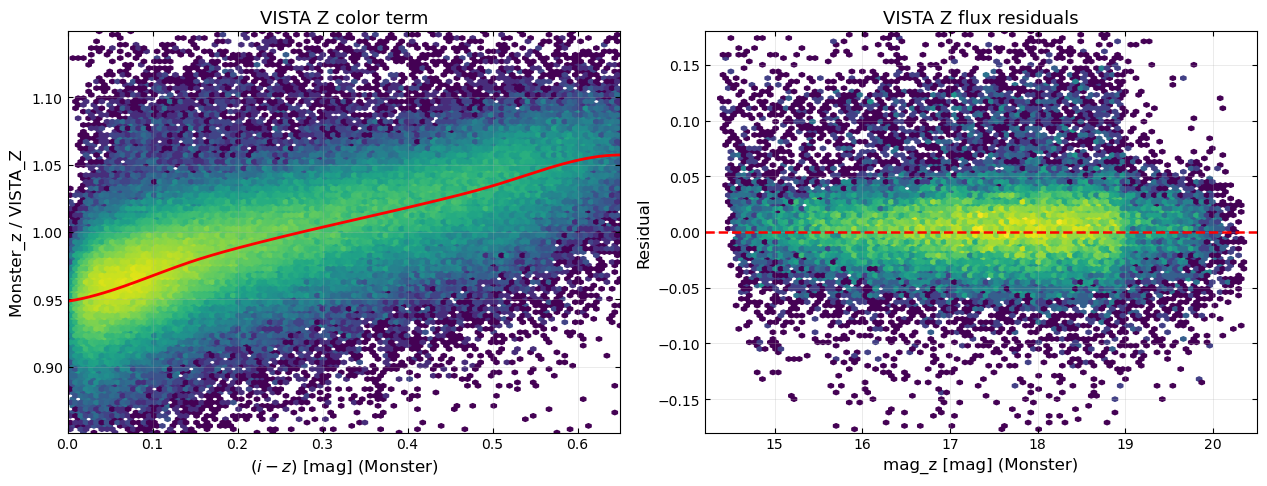

Saved publication figure:
  data/outputs/Monster_VIKING_Z/viking_z_calibration_publication.pdf
  data/outputs/Monster_VIKING_Z/viking_z_calibration_publication.png

Displayed samples:
  Colour-relation measurements : 183,183
  Validation residuals         : 34,252


In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from astropy.table import Table
from scipy.interpolate import make_interp_spline


# -------------------------------------------------------------------
# Input and output paths
# -------------------------------------------------------------------

OUTPUT_DIR = Path(
    "data/outputs/Monster_VIKING_Z"
)

OBSERVATION_PATH = (
    OUTPUT_DIR
    / "viking_z_calibration_observations_all_tiles.fits"
)

VALIDATION_PATH = (
    OUTPUT_DIR
    / "viking_z_validation_residuals.csv"
)

# Existing YAML produced earlier in the notebook.
INPUT_YAML_PATH = (
    OUTPUT_DIR
    / "Monster_to_VISTA_band_z.yaml"
)

# Copy saved beside the notebook for Git.
FINAL_YAML_PATH = Path(
    "Monster_to_VISTA_band_z.yaml"
)

PUBLICATION_PDF_PATH = (
    OUTPUT_DIR
    / "viking_z_calibration_publication.pdf"
)

PUBLICATION_PNG_PATH = (
    OUTPUT_DIR
    / "viking_z_calibration_publication.png"
)


# Check only files that already need to exist.
for required_path in [
    OBSERVATION_PATH,
    VALIDATION_PATH,
    INPUT_YAML_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required final product was not found:\n"
            f"{required_path}"
        )

# -------------------------------------------------------------------
# Read the final products
# -------------------------------------------------------------------

all_observations = Table.read(
    OBSERVATION_PATH
)

validation_table = pd.read_csv(
    VALIDATION_PATH
)

with open(
    INPUT_YAML_PATH,
    "r",
    encoding="utf-8",
) as yaml_file:
    final_yaml = yaml.safe_load(
        yaml_file
    )


final_nodes = np.asarray(
    final_yaml["nodes"],
    dtype=float,
)

final_node_values = np.asarray(
    final_yaml["spline_values"],
    dtype=float,
)


final_spline = make_interp_spline(
    final_nodes,
    final_node_values,
    k=3,
)

smooth_colour = np.linspace(
    final_nodes[0],
    final_nodes[-1],
    1000,
)

smooth_ratio = final_spline(
    smooth_colour
)


with open(
    FINAL_YAML_PATH,
    "w",
    encoding="utf-8",
) as yaml_file:
    yaml.safe_dump(
        final_yaml,
        yaml_file,
        sort_keys=False,
        default_flow_style=False,
    )

# -------------------------------------------------------------------
# Helper function
# -------------------------------------------------------------------

def table_column_as_float(table, column_name):
    """Convert an ordinary or masked Astropy column to float."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                table[column_name],
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


# -------------------------------------------------------------------
# Left panel: complete calibration sample
# -------------------------------------------------------------------

calibration_colour = table_column_as_float(
    all_observations,
    "monster_iz_colour",
)

calibration_ratio = table_column_as_float(
    all_observations,
    "monster_z_over_vista_z",
)


# Display limits chosen to show the main calibration relation clearly.
LEFT_X_MIN = 0.0
LEFT_X_MAX = 0.65

LEFT_Y_MIN = 0.851
LEFT_Y_MAX = 1.149


left_plot_mask = (
    np.isfinite(calibration_colour)
    & np.isfinite(calibration_ratio)
    & (calibration_colour >= LEFT_X_MIN)
    & (calibration_colour <= LEFT_X_MAX)
    & (calibration_ratio >= LEFT_Y_MIN)
    & (calibration_ratio <= LEFT_Y_MAX)
)


# -------------------------------------------------------------------
# Right panel: independent validation residuals
# -------------------------------------------------------------------

validation_native_z = validation_table[
    "viking_z_mag_vega"
].to_numpy(dtype=float)

validation_ratio = validation_table[
    "measured_ratio"
].to_numpy(dtype=float)

validation_residual = validation_table[
    "ratio_residual"
].to_numpy(dtype=float)

validation_colour = validation_table[
    "monster_iz_colour"
].to_numpy(dtype=float)


# Native VISTA Z -> AB conversion:
#
# Z_true_Vega = Z_native - 0.004
# Z_AB        = Z_true_Vega + 0.502
#
# Therefore:
# Z_AB = Z_native + 0.498
VISTA_Z_AB_MINUS_NATIVE = 0.498


# Since
#
# ratio = F_Monster,z / F_VISTA,Z,
#
# the corresponding Monster z magnitude is:
#
# m_Monster,z = m_VISTA,Z(AB) - 2.5 log10(ratio)
monster_z_magnitude = np.full(
    len(validation_table),
    np.nan,
    dtype=float,
)

valid_ratio = (
    np.isfinite(validation_native_z)
    & np.isfinite(validation_ratio)
    & (validation_ratio > 0.0)
)

monster_z_magnitude[
    valid_ratio
] = (
    validation_native_z[
        valid_ratio
    ]
    + VISTA_Z_AB_MINUS_NATIVE
    - 2.5
    * np.log10(
        validation_ratio[
            valid_ratio
        ]
    )
)


RIGHT_X_MIN = 14.2
RIGHT_X_MAX = 20.5

RIGHT_Y_MIN = -0.18
RIGHT_Y_MAX = 0.18


# Restrict the data before calling hexbin. This avoids the artificial
# vertical and triangular structures created when extreme outliers
# are binned first and clipped only by set_ylim afterwards.
right_plot_mask = (
    np.isfinite(monster_z_magnitude)
    & np.isfinite(validation_residual)
    & np.isfinite(validation_colour)
    & (validation_colour >= final_nodes[0])
    & (validation_colour <= final_nodes[-1])
    & (monster_z_magnitude >= RIGHT_X_MIN)
    & (monster_z_magnitude <= RIGHT_X_MAX)
    & (validation_residual >= RIGHT_Y_MIN)
    & (validation_residual <= RIGHT_Y_MAX)
)


# -------------------------------------------------------------------
# Construct a Monster-style two-panel figure
# -------------------------------------------------------------------

publication_settings = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}


with plt.rc_context(
    publication_settings
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(12.8, 5.0),
    )

    colour_axis = axes[0]
    residual_axis = axes[1]


    # ---------------------------------------------------------------
    # Left: colour term
    # ---------------------------------------------------------------

    colour_axis.hexbin(
        calibration_colour[
            left_plot_mask
        ],
        calibration_ratio[
            left_plot_mask
        ],
        gridsize=105,
        extent=(
            LEFT_X_MIN,
            LEFT_X_MAX,
            LEFT_Y_MIN,
            LEFT_Y_MAX,
        ),
        mincnt=1,
        bins="log",
        rasterized=True,
    )

    colour_axis.plot(
        smooth_colour,
        smooth_ratio,
        linewidth=2.0,
        color="red",
    )

    colour_axis.set_xlim(
        LEFT_X_MIN,
        LEFT_X_MAX,
    )

    colour_axis.set_ylim(
        LEFT_Y_MIN,
        LEFT_Y_MAX,
    )

    # Labels intentionally follow the Monster documentation.
    colour_axis.set_xlabel(
        r"$(i-z)$ [mag] (Monster)"
    )

    colour_axis.set_ylabel(
        "Monster_z / VISTA_Z"
    )

    colour_axis.set_title(
        "VISTA Z color term"
    )

    colour_axis.grid(
        alpha=0.25,
        linewidth=0.7,
    )

    colour_axis.tick_params(
        direction="in",
        top=True,
        right=True,
    )


    # ---------------------------------------------------------------
    # Right: independent validation residuals
    # ---------------------------------------------------------------

    residual_axis.hexbin(
        monster_z_magnitude[
            right_plot_mask
        ],
        validation_residual[
            right_plot_mask
        ],
        gridsize=105,
        extent=(
            RIGHT_X_MIN,
            RIGHT_X_MAX,
            RIGHT_Y_MIN,
            RIGHT_Y_MAX,
        ),
        mincnt=1,
        bins="log",
        rasterized=True,
    )

    residual_axis.axhline(
        0.0,
        linestyle="--",
        linewidth=1.8,
        color="red",
    )

    residual_axis.set_xlim(
        RIGHT_X_MIN,
        RIGHT_X_MAX,
    )

    residual_axis.set_ylim(
        RIGHT_Y_MIN,
        RIGHT_Y_MAX,
    )

    # Labels intentionally follow the Monster documentation.
    residual_axis.set_xlabel(
        "mag_z [mag] (Monster)"
    )

    residual_axis.set_ylabel(
        "Residual"
    )

    residual_axis.set_title(
        "VISTA Z flux residuals"
    )

    residual_axis.grid(
        alpha=0.25,
        linewidth=0.7,
    )

    residual_axis.tick_params(
        direction="in",
        top=True,
        right=True,
    )


    figure.tight_layout()


    # ---------------------------------------------------------------
    # Save vector and raster versions
    # ---------------------------------------------------------------

    figure.savefig(
        PUBLICATION_PDF_PATH,
        bbox_inches="tight",
    )

    figure.savefig(
        PUBLICATION_PNG_PATH,
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()


print("Saved publication figure:")
print(f"  {PUBLICATION_PDF_PATH}")
print(f"  {PUBLICATION_PNG_PATH}")

print("\nDisplayed samples:")
print(
    f"  Colour-relation measurements : "
    f"{np.count_nonzero(left_plot_mask):,}"
)

print(
    f"  Validation residuals         : "
    f"{np.count_nonzero(right_plot_mask):,}"
)

### Final decision

The adopted VIRCAM Z-band transformation is defined over

0.0 ≤ (i-z)_{Monster} ≤ 0.65.

An extension to (i-z)=0.70 was tested, but the final node was supported
by only 29 of the 88 VIKING tiles, compared with more than 80 tiles near the
adopted red boundary. I therefore retain 0.65 as the conservative
survey-wide limit.

The final transformation is smooth and monotonic, passes the independent-tile
validation tests, and has been written to the Monster colour-term YAML file.
The VIRCAM Z-band calibration is considered complete.